# Estadística descriptica de las variables

En este apartado se analizan individualmente las variables, su distribución, su comportamiento con respecto al tiempo y si son aptas para continuar en el proceso predictivo o si visualmente deben descartarse. Para efectos del análisis descriptivo, vamos a utilizar el set de datos sin huecos usados en el preprocesamiento.

In [1]:
# Leemos los datos
import pandas as pd

datos = pd.read_excel('00.Generación sin nulos.xlsx')
datos.head()

,dtHora,fltValGeneracion,iNumDia,iNumAnio,iNumSemana,iNumDiaSemana,iNumMes,iCodDia,iCodHora,iNumHora,...,fltProbabilidadLluvia,fltHumedadRelativa,fltVelocidadViento,fltCoberturaNubes,fltIndiceUV,iCodCondCielo,iCodDirViento,fltVelocidadRafaga,fltPrecipitacion,fltDPT
0,2022-09-01 00:00:00,0.0,1,2022,36,5,9,6452,154847,24,...,7,77,15,98,0.0,4,4,32,0.0,15
1,2022-09-01 01:00:00,0.0,1,2022,36,5,9,6453,154848,1,...,7,82,13,82,0.0,4,4,32,0.0,16
2,2022-09-01 02:00:00,0.0,1,2022,36,5,9,6453,154849,2,...,9,85,11,73,0.0,3,4,28,0.0,16
3,2022-09-01 03:00:00,0.0,1,2022,36,5,9,6453,154850,3,...,11,87,11,63,0.0,3,4,26,0.0,16
4,2022-09-01 04:00:00,0.0,1,2022,36,5,9,6453,154851,4,...,11,88,11,70,0.0,3,4,24,0.0,16


## Análisis general

In [2]:
from ydata_profiling import ProfileReport

In [3]:
profile = ProfileReport(datos, tsmode=True, sortby="dtHora")
profile.to_file('profile_report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\ydata_profiling\model\correlations.py:66: UserWarning: There was an attempt to calculate the auto correlation, but this failed.
To hide this warning, disable the calculation
(using `df.profile_report(correlations={"auto": {"calculate": False}})`
If this is problematic for your use case, please report this as an issue:
https://github.com/ydataai/ydata-profiling/issues
(include the error message: 'cannot reindex on an axis with duplicate labels')
  warnings.warn(


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Preparamos las funciones para el análisis de cada variable

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [5]:
def EDA(inicio, fin, variable, descripcion, bCeros, largo = 20, ancho = 5):
    inicio = 13246
    fin = inicio + 700

    plt.figure(figsize=(largo, ancho))

    # Graficar la serie temporal
    plt.plot(
        datos["dtHora"],  # Eje X: Hora o Fecha
        datos[variable],  # Eje Y: Generación de energía
        label=descripcion, linewidth=2
    )

    # Agregar etiquetas y título
    plt.xlabel('Fecha', fontsize=12)
    plt.ylabel(descripcion, fontsize=12)
    plt.grid()

    # Mostrar el gráfico
    plt.show()

    # Configurar el gráfico
    plt.figure(figsize=(largo, ancho))

    # Graficar la serie temporal
    plt.plot(
        datos.loc[inicio:fin, "dtHora"],  # Eje X: Hora o Fecha
        datos.loc[inicio:fin, variable],  # Eje Y: Generación de energía
        label=descripcion, linewidth=2
    )

    # Agregar etiquetas y título
    plt.xlabel('Fecha', fontsize=12)
    plt.ylabel(descripcion, fontsize=12)
    plt.grid()

    # Mostrar el gráfico
    plt.show()

    
# Asegúrate de que tu DataFrame tenga estas columnas:
# 'iNumHora' (Hora del día), 'fltValGeneracion' (Valores de generación), 'iNumMes' (Mes del año)

# Crear un diccionario para convertir números de mes a nombres
    meses = {
        1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril",
        5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto",
        9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"
    }

    # Agrupar y preparar los datos
    df_grouped = datos.groupby(['iNumHora', 'iNumMes'])[variable].mean().reset_index()
    df_grouped['Mes'] = df_grouped['iNumMes'].map(meses)  # Añadir nombres de los meses

    # Configurar el gráfico
    plt.figure(figsize=(largo, ancho))

    # Usar la paleta de colores accesible para daltonismo
    palette = sns.color_palette("colorblind", 12)

    # Lista de marcadores
    markers = ['o', 's', 'D', '*', 'X', 'P', 'v', '^', '<', '>', 'h', 'p']

    # Dibujar cada línea con un marcador único
    for i, mes in enumerate(meses.values()):
        # Filtrar datos por mes
        datos_mes = df_grouped[df_grouped['Mes'] == mes]
        plt.plot(
            datos_mes['iNumHora'], 
            datos_mes[variable], 
            label=mes, 
            color=palette[i], 
            marker=markers[i],  # Usar un marcador diferente para cada mes
            linewidth=1.5, 
            markersize=6  # Tamaño del marcador
        )

    # Agregar etiquetas y leyenda
    plt.xlabel('Hora del Día', fontsize=12)
    plt.ylabel(descripcion, fontsize=12)
    plt.legend(title='Meses', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.grid()
    plt.xticks(np.arange(0, 26, 1))
    plt.tight_layout()

    # Mostrar el gráfico
    plt.show()

    if(not(bCeros)):
        df_filtered = datos[datos[variable] > 0]
    else:
        df_filtered = datos.copy()

# Crear una nueva columna que combine año y mes para el eje X
    df_filtered['Year_Month'] = df_filtered['iNumAnio'].astype(str) + "_" + df_filtered['iNumMes'].astype(str)

    # Ordenar los datos por año y mes
    df_filtered = df_filtered.sort_values(by=['iNumAnio', 'iNumMes'])

    # Configurar estilo de la gráfica
    sns.set(style="whitegrid")

    # Crear el boxplot
    plt.figure(figsize=(largo, ancho))
    sns.boxplot(data=df_filtered, x='Year_Month', y=variable, palette="Set2")

    # Personalizar etiquetas y título
    plt.xlabel("Año Mes", fontsize=12)
    plt.ylabel(descripcion, fontsize=12)
    plt.xticks(rotation=45, ha='right')

    # Mostrar la gráfica
    plt.tight_layout()
    plt.show()

    df_filtered = datos.copy()

    # Ordenar los datos por hora del día
    df_filtered = df_filtered.sort_values(by=['iNumHora'])

    # Configurar estilo de la gráfica
    sns.set(style="whitegrid")

    # Crear el boxplot por hora del día
    plt.figure(figsize=(largo, ancho))
    sns.boxplot(data=df_filtered, x='iNumHora', y=variable, palette="Set2")

    # Personalizar etiquetas y título
    plt.xlabel("Hora", fontsize=12)
    plt.ylabel(descripcion, fontsize=12)
    plt.xticks(rotation=0)

    # Mostrar la gráfica
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(largo, ancho))
    

    if(not(bCeros)):
        df_filtered = datos[datos[variable] > 0]
    else:
        df_filtered = datos.copy()
    sns.histplot(data=df_filtered, x=variable, bins=30, kde=True)

    # Personalizar
    plt.xlabel(descripcion, fontsize=12)
    plt.ylabel("Frecuencia", fontsize=12)
    plt.show()


## Generación de energía

In [6]:
EDA(13246, 13946, 'fltValGeneracion', 'Generación [kWh]', False)

NameError: name 'np' is not defined

In [ ]:
datos.dtypes

dtHora                   datetime64[ns]
fltValGeneracion                float64
iNumDia                           int64
iNumAnio                          int64
iNumSemana                        int64
iNumDiaSemana                     int64
iNumMes                           int64
iCodDia                           int64
iCodHora                          int64
iNumHora                          int64
fltTemp                           int64
fltProbabilidadLluvia             int64
fltHumedadRelativa                int64
fltVelocidadViento                int64
fltCoberturaNubes                 int64
fltIndiceUV                     float64
iCodCondCielo                     int64
iCodDirViento                     int64
fltVelocidadRafaga                int64
fltPrecipitacion                float64
fltDPT                            int64
dtype: object

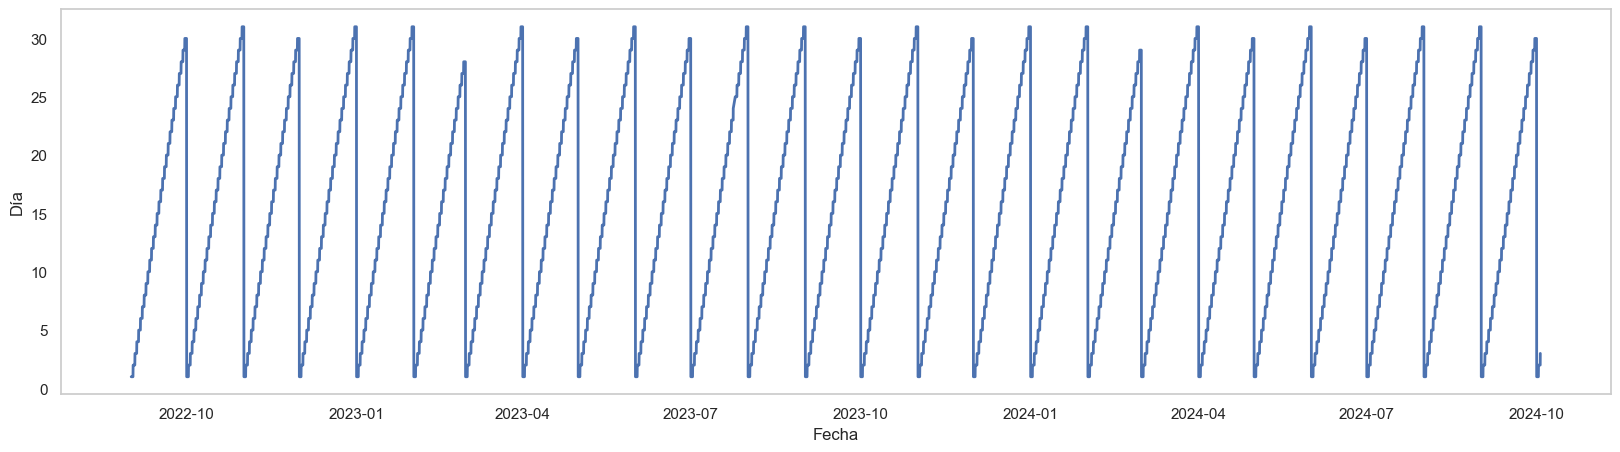

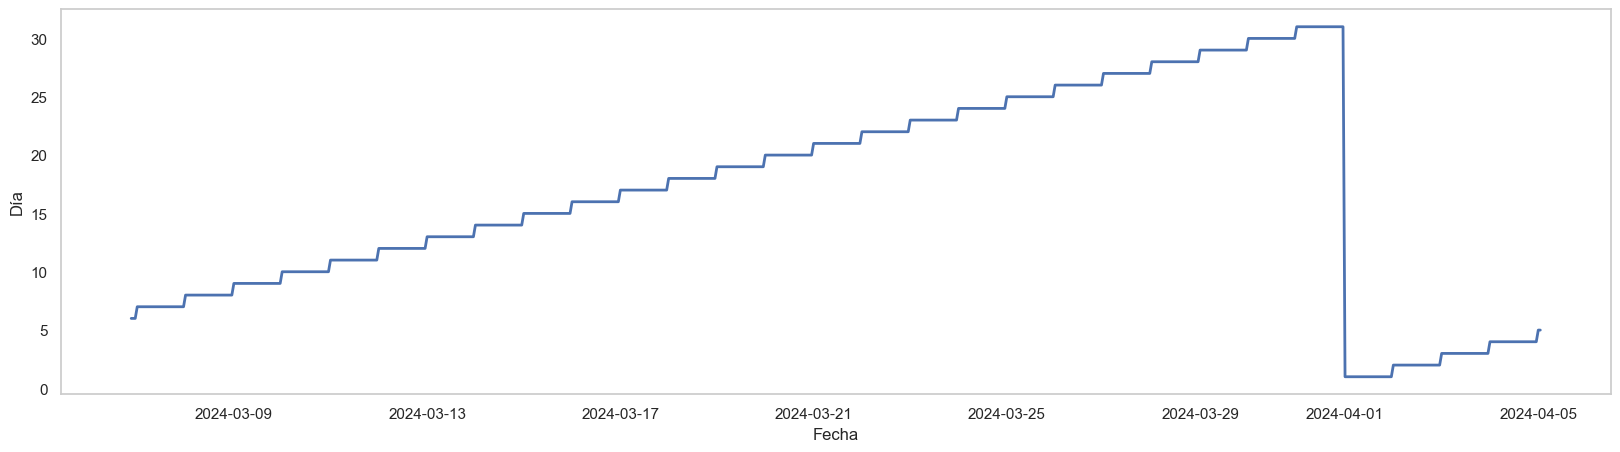

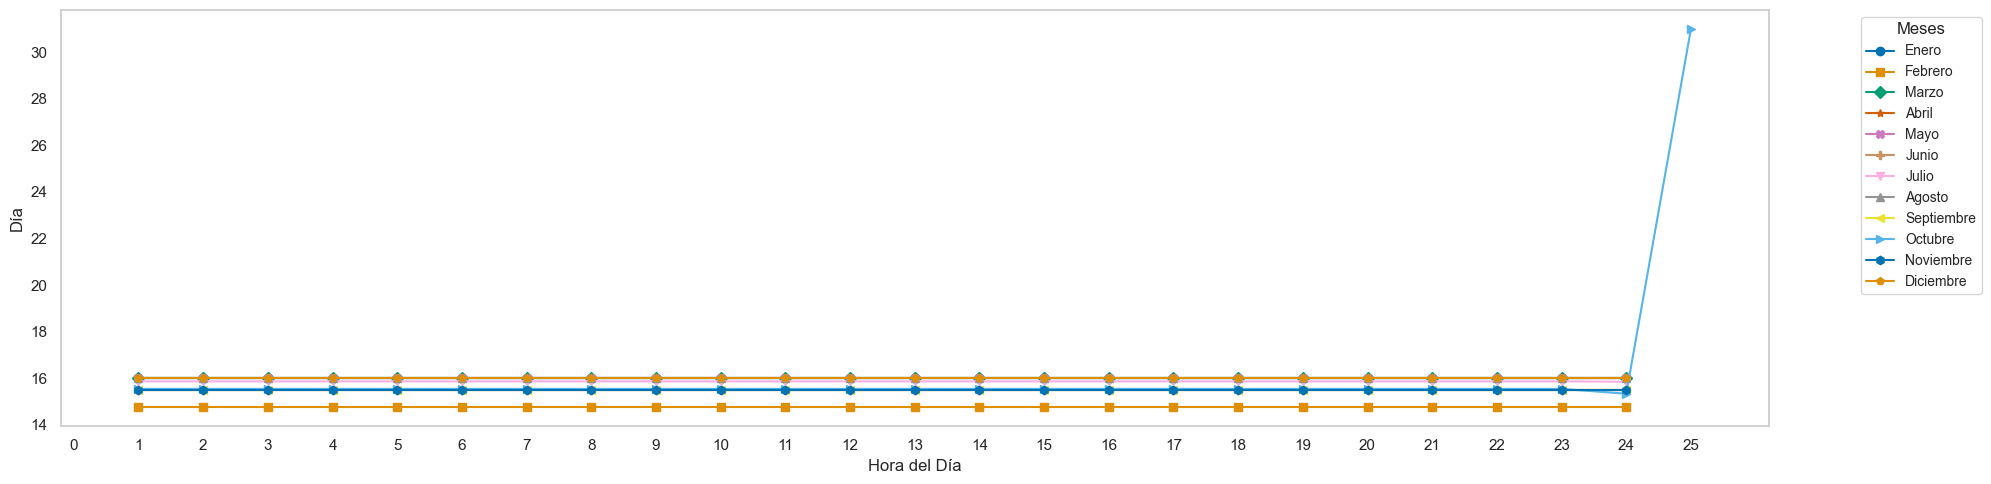

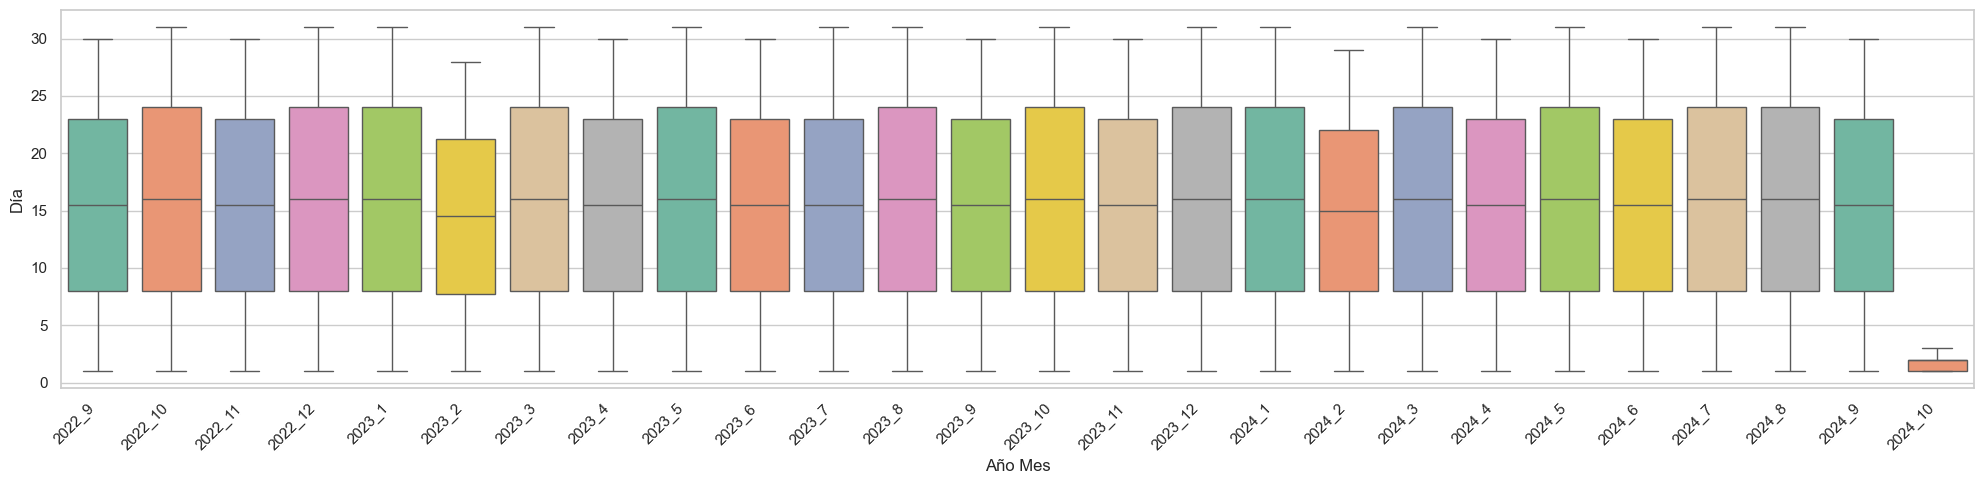

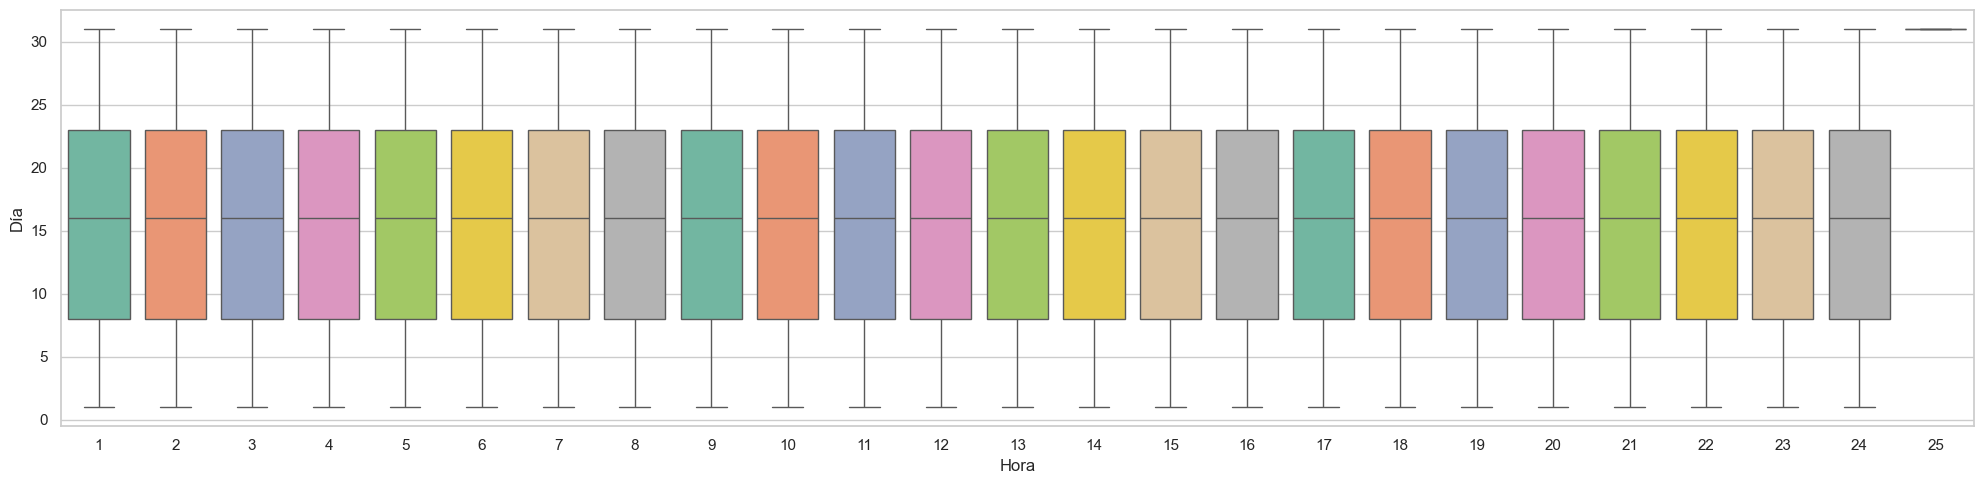

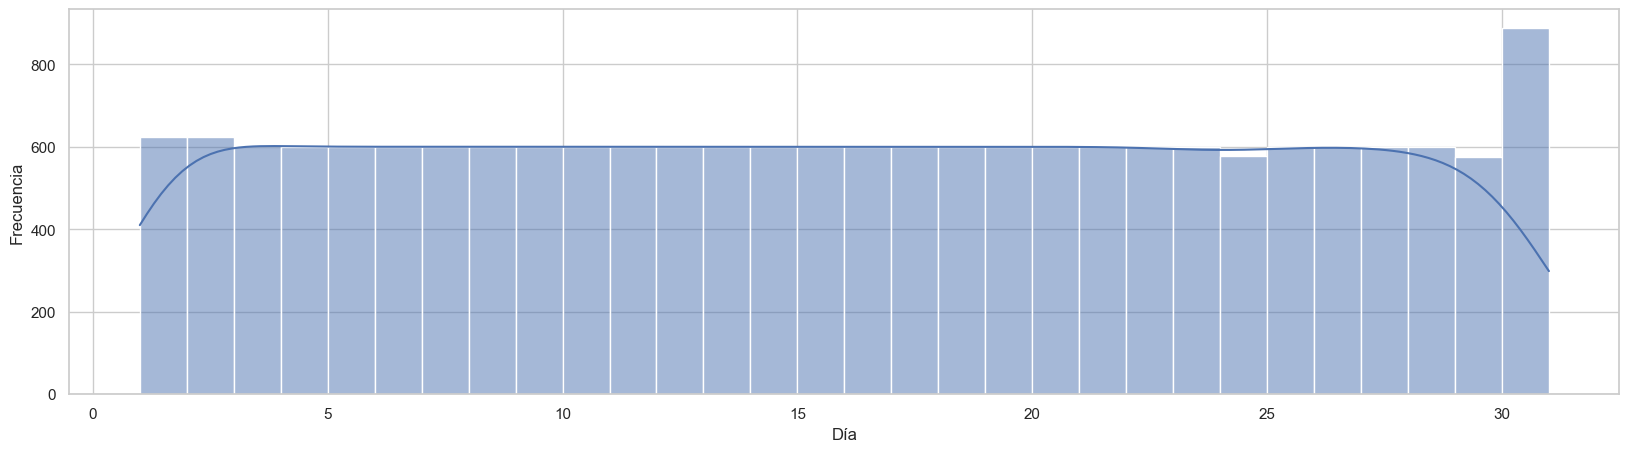

In [ ]:
EDA(13246, 13946, 'iNumDia', 'Día', False)

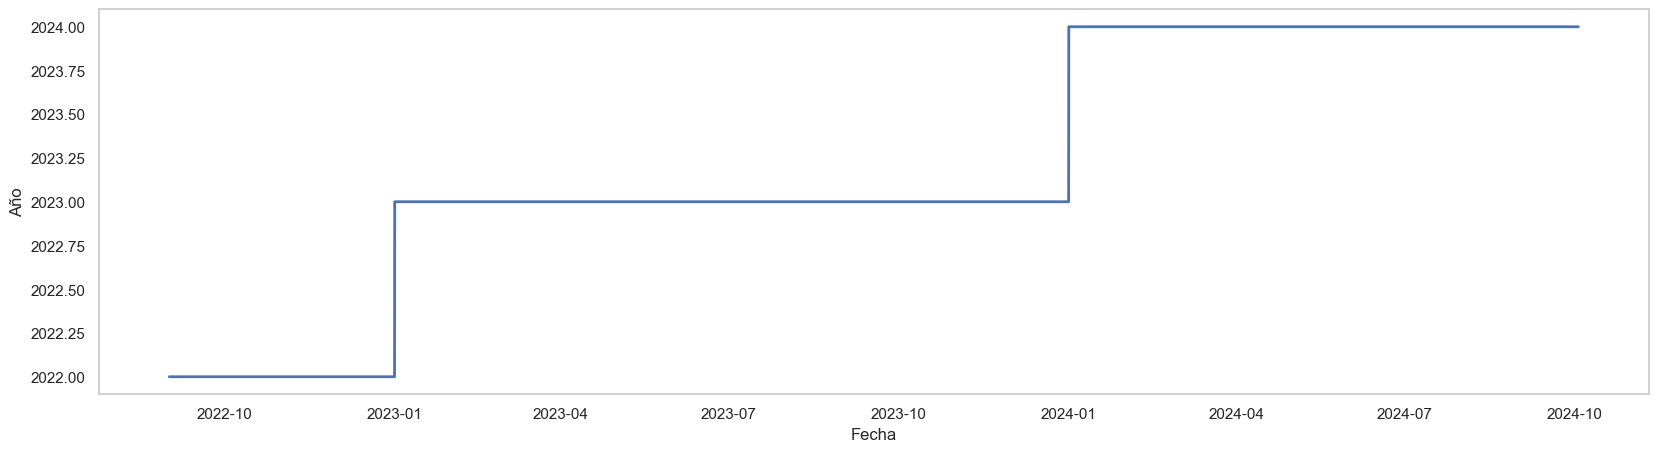

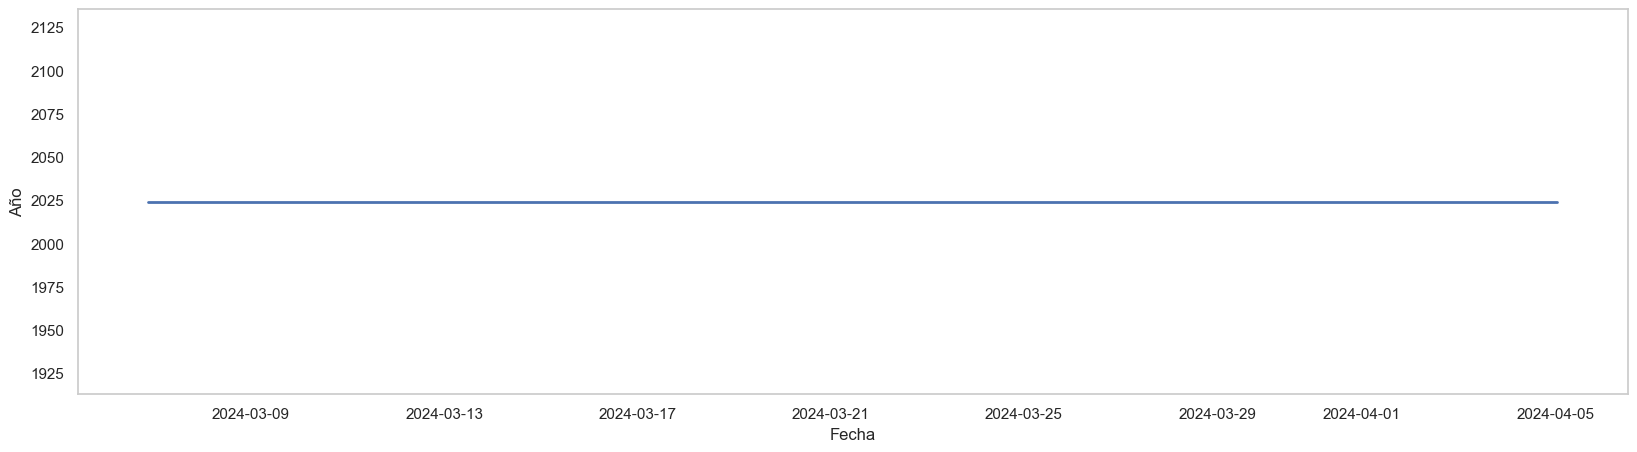

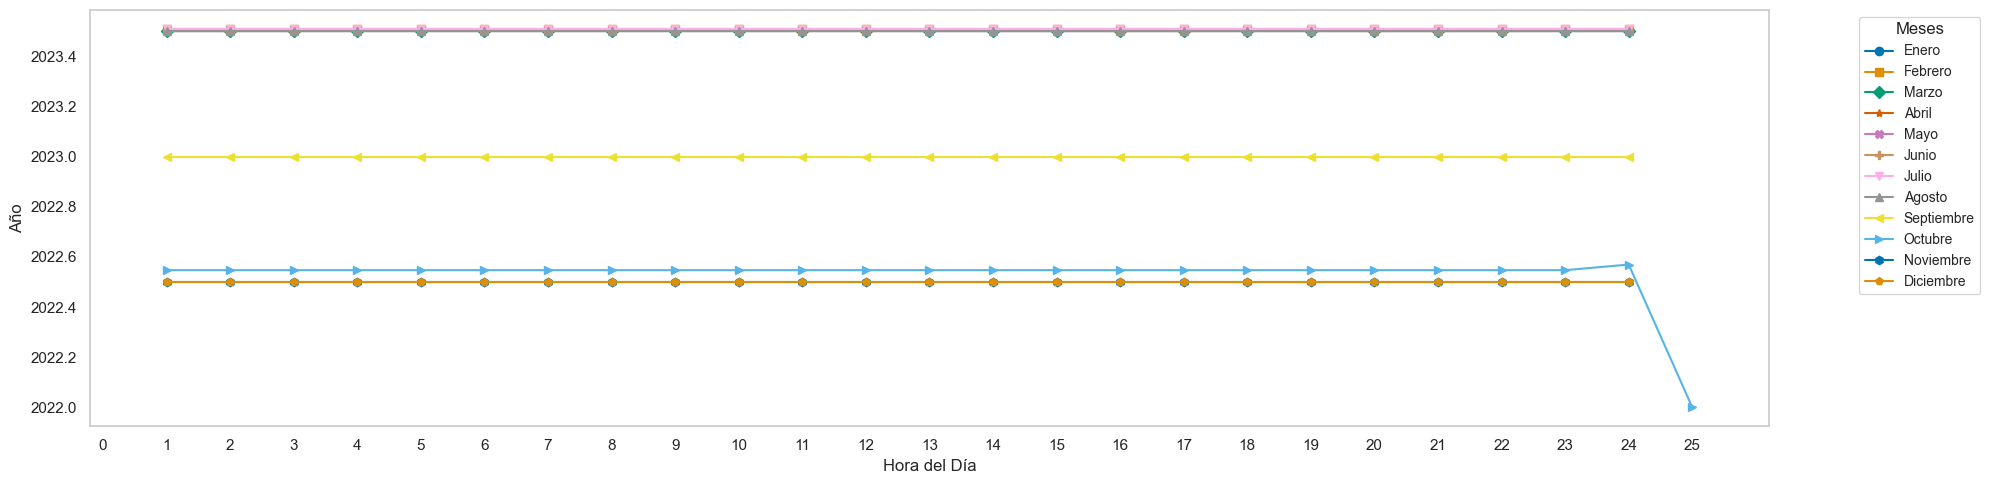

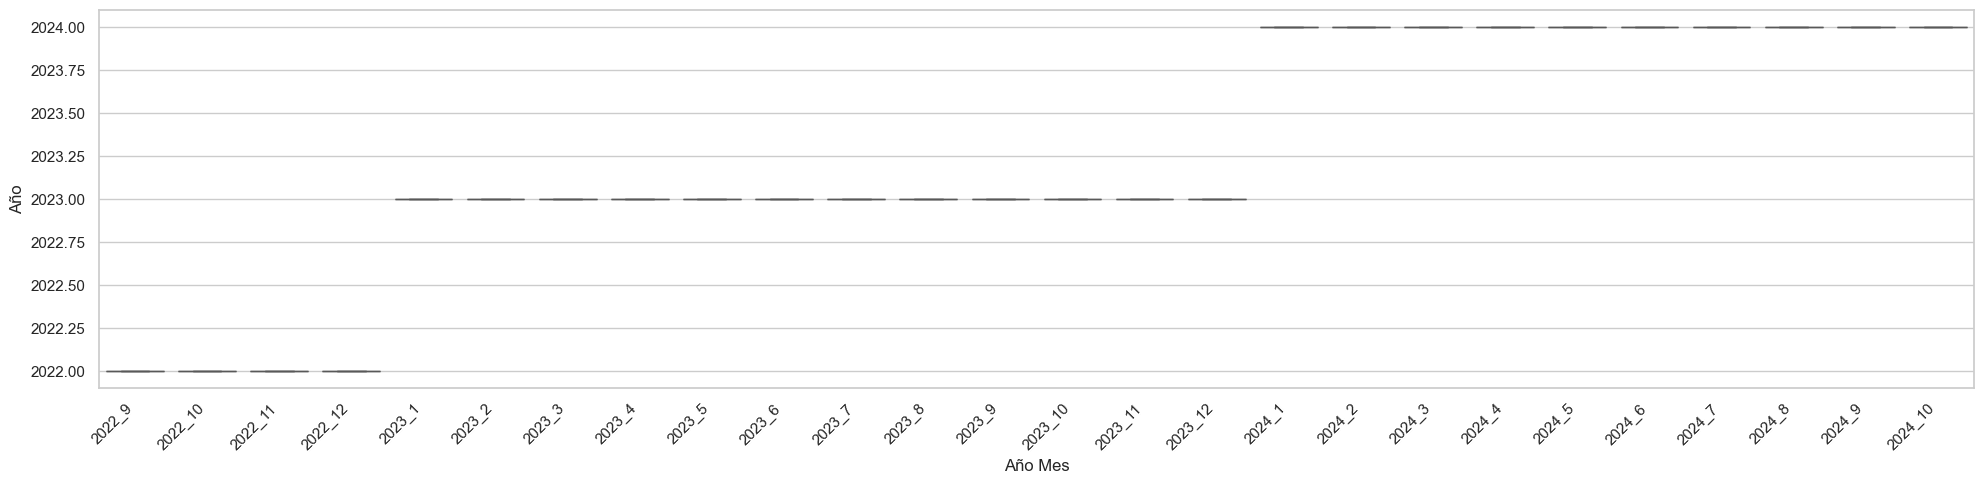

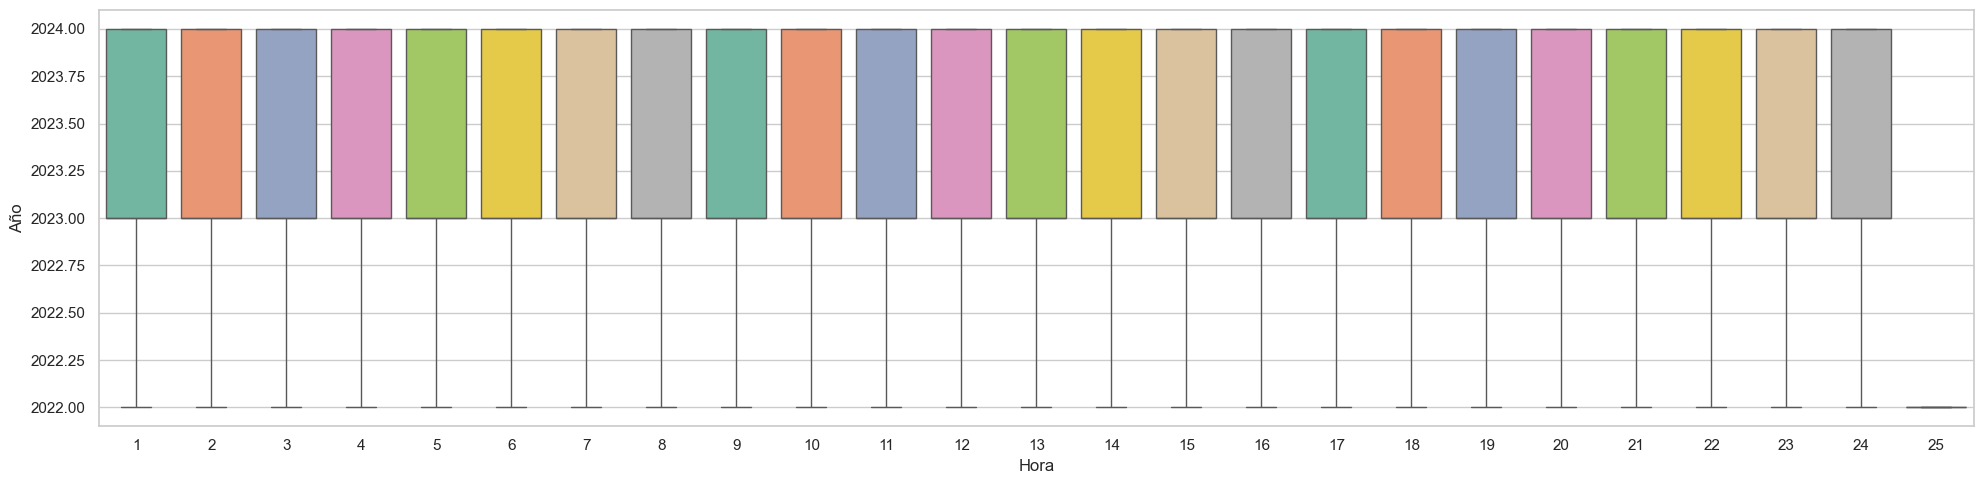

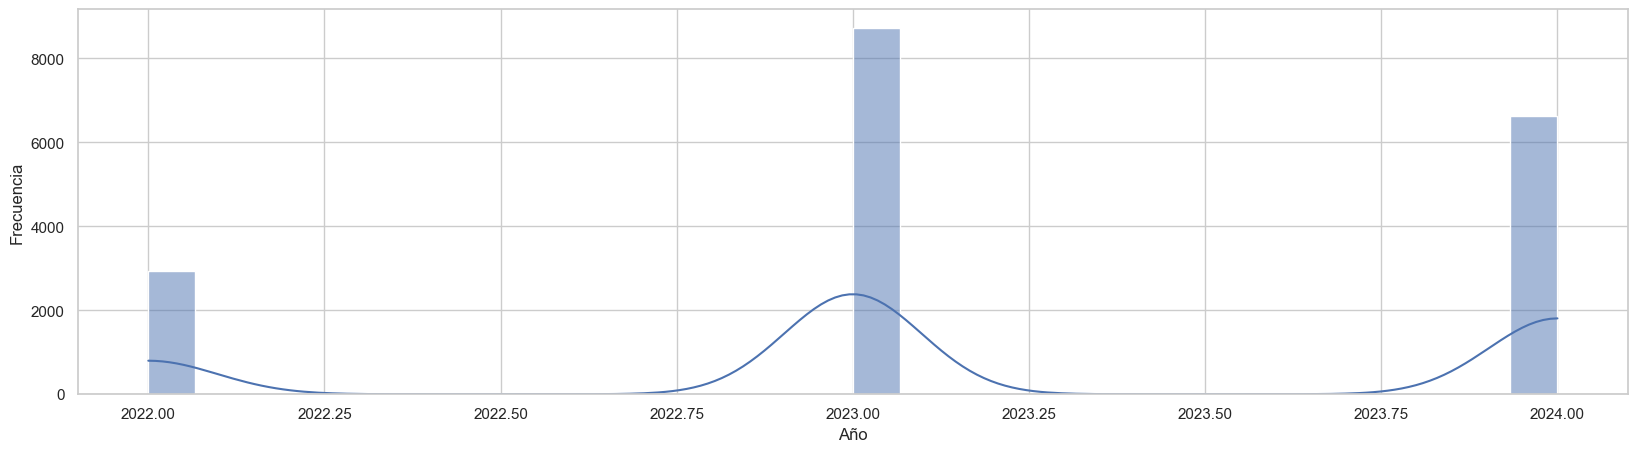

In [ ]:
EDA(13246, 13946, 'iNumAnio', 'Año', False)

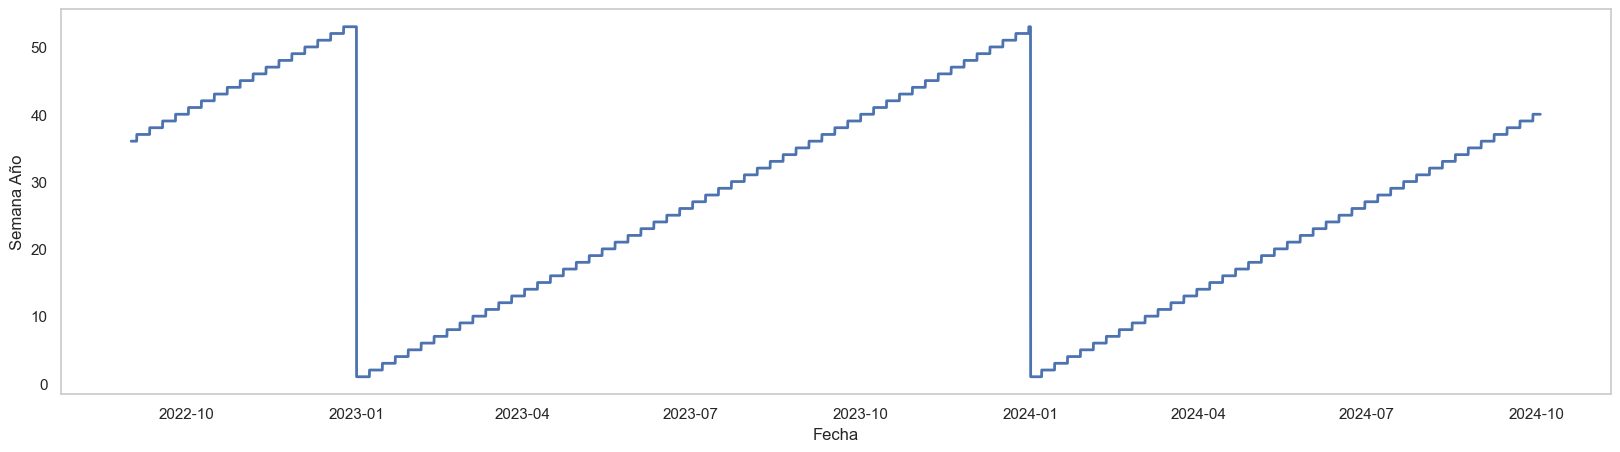

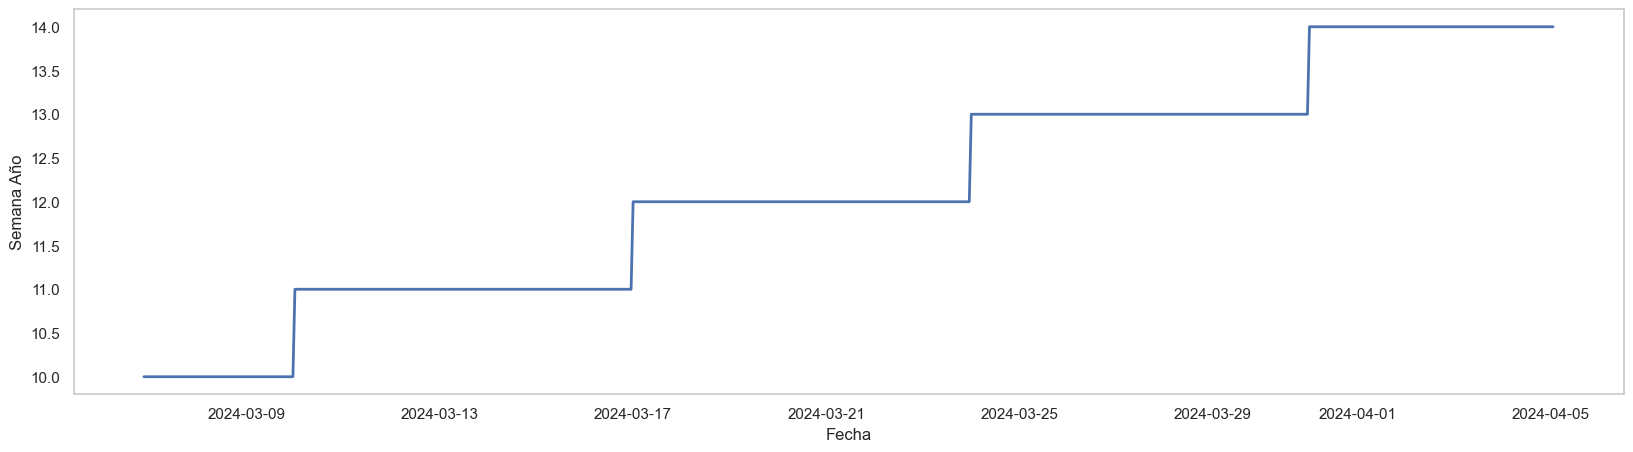

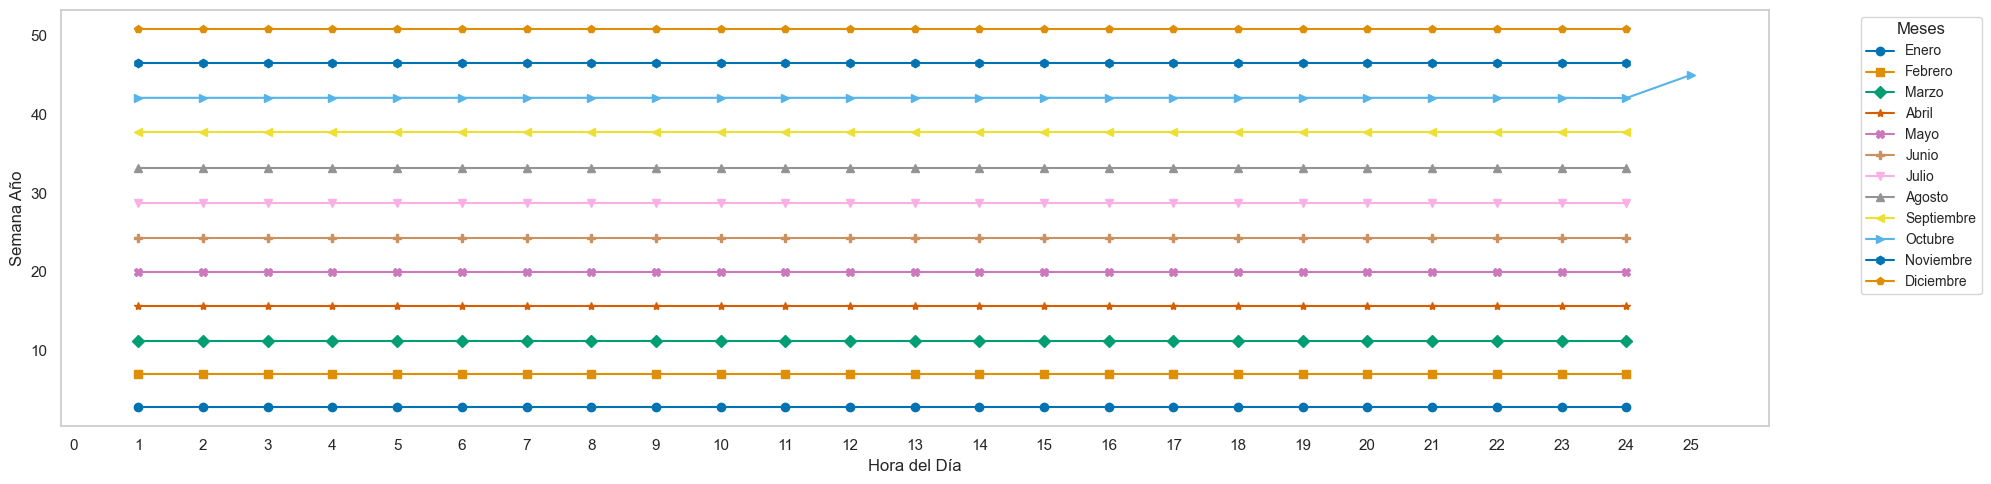

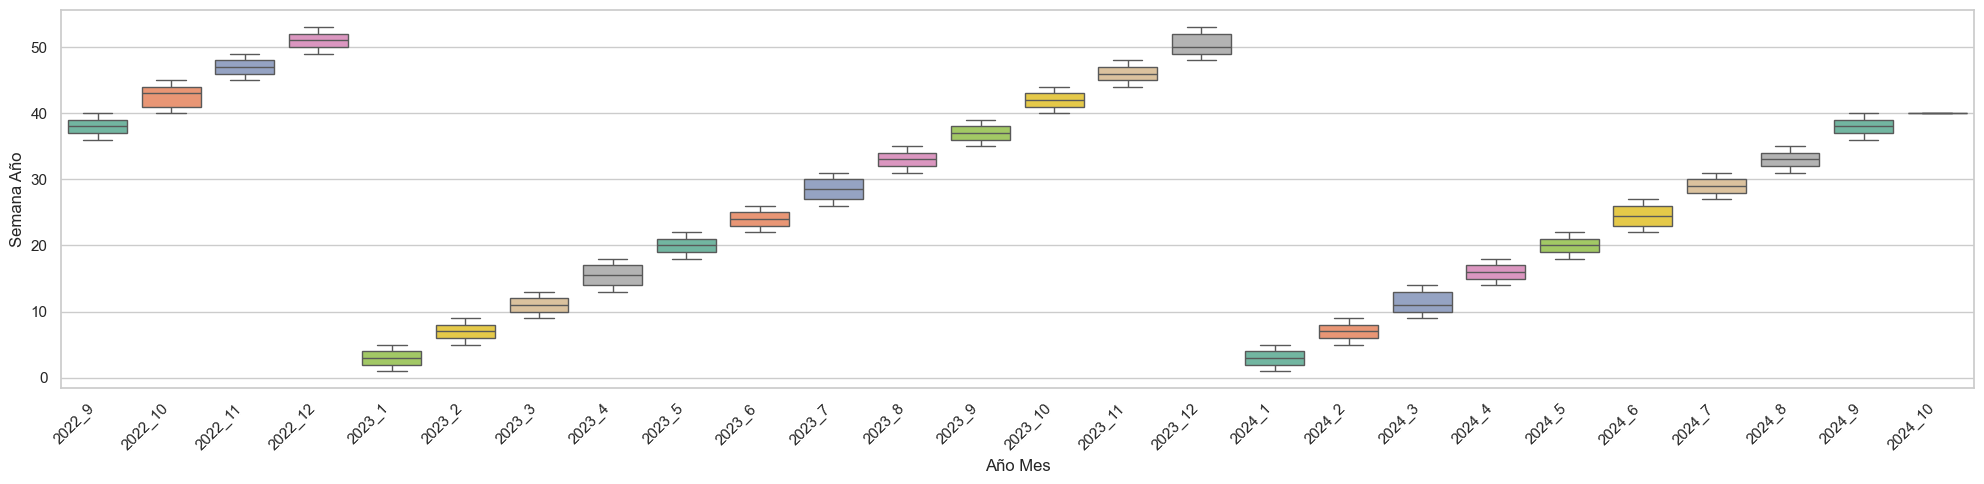

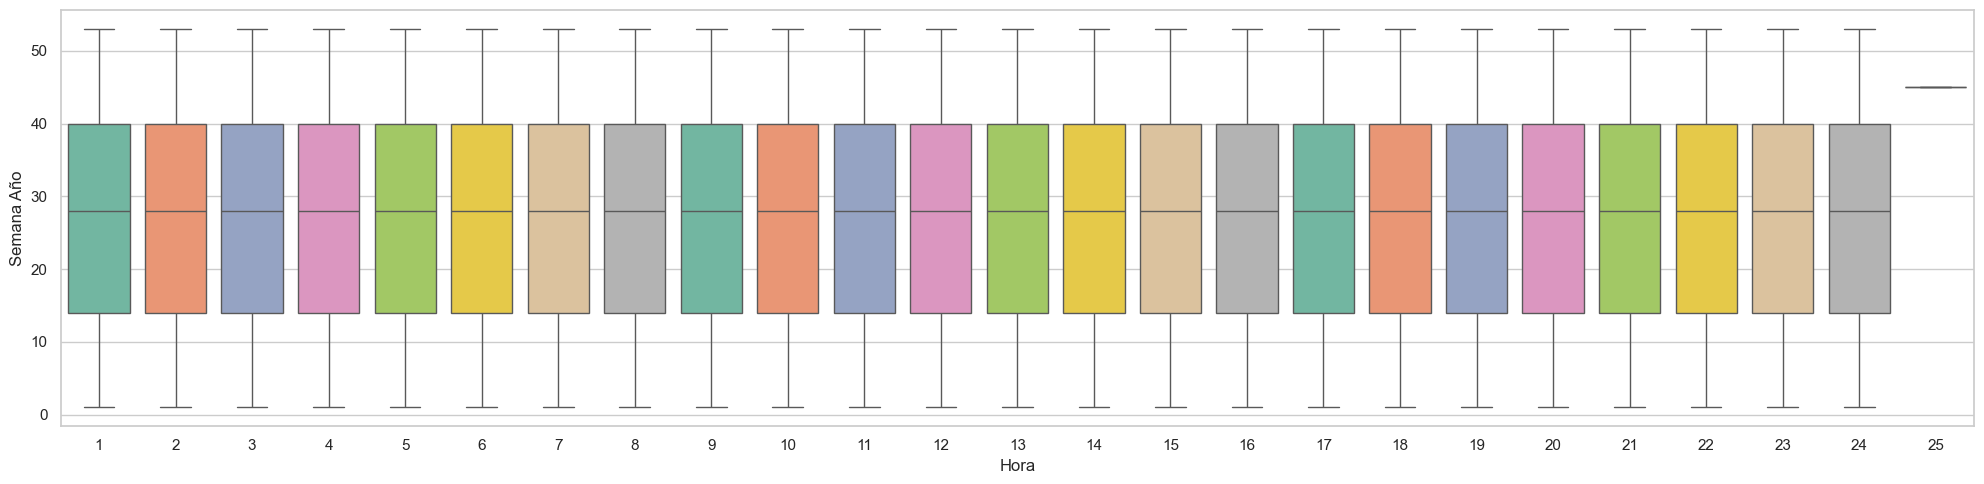

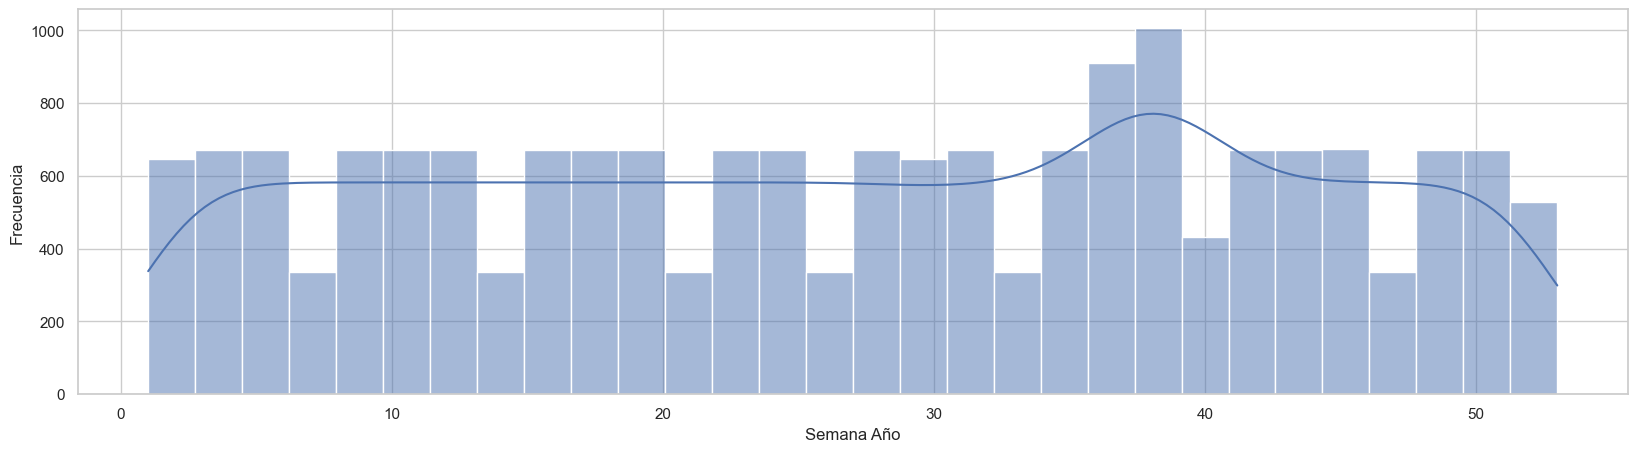

In [ ]:
EDA(13246, 13946, 'iNumSemana', 'Semana Año', False)

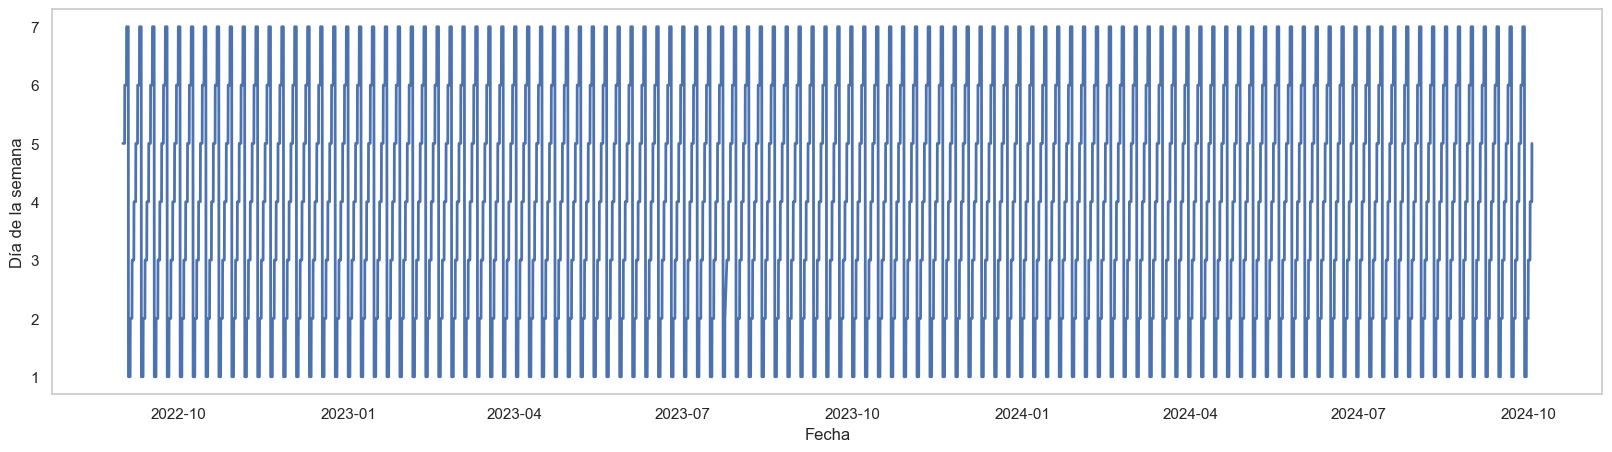

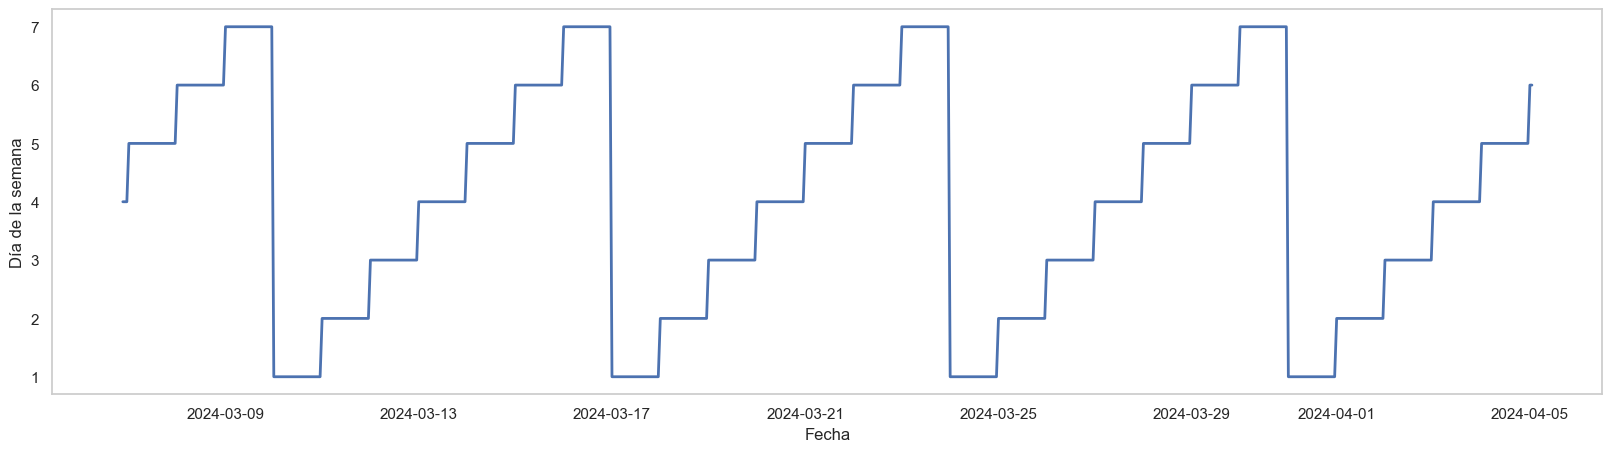

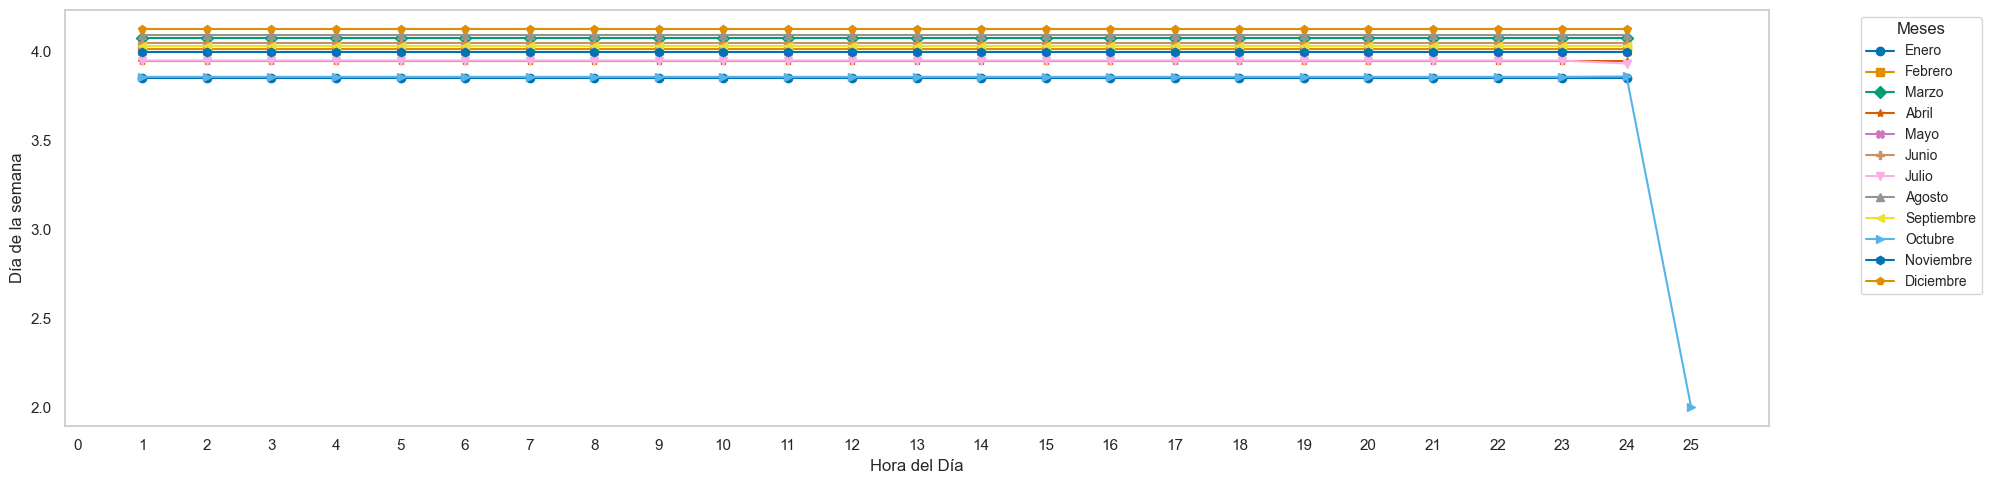

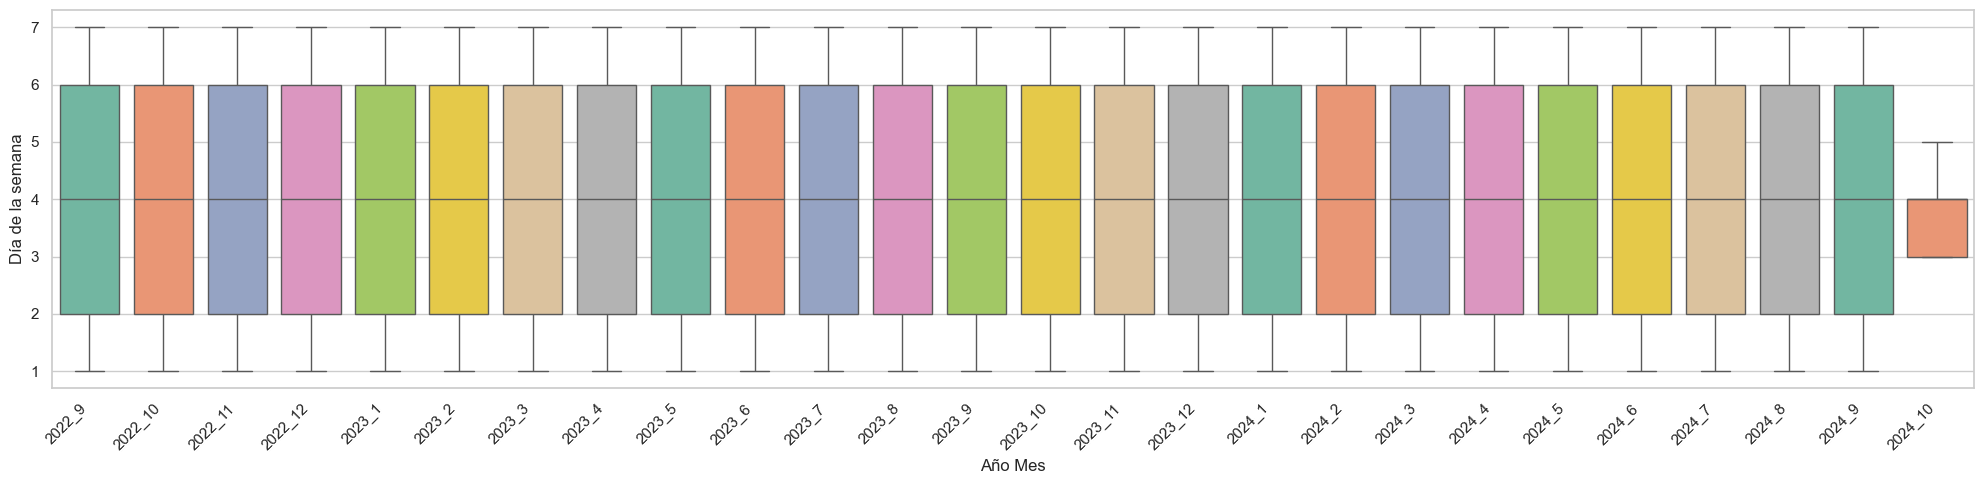

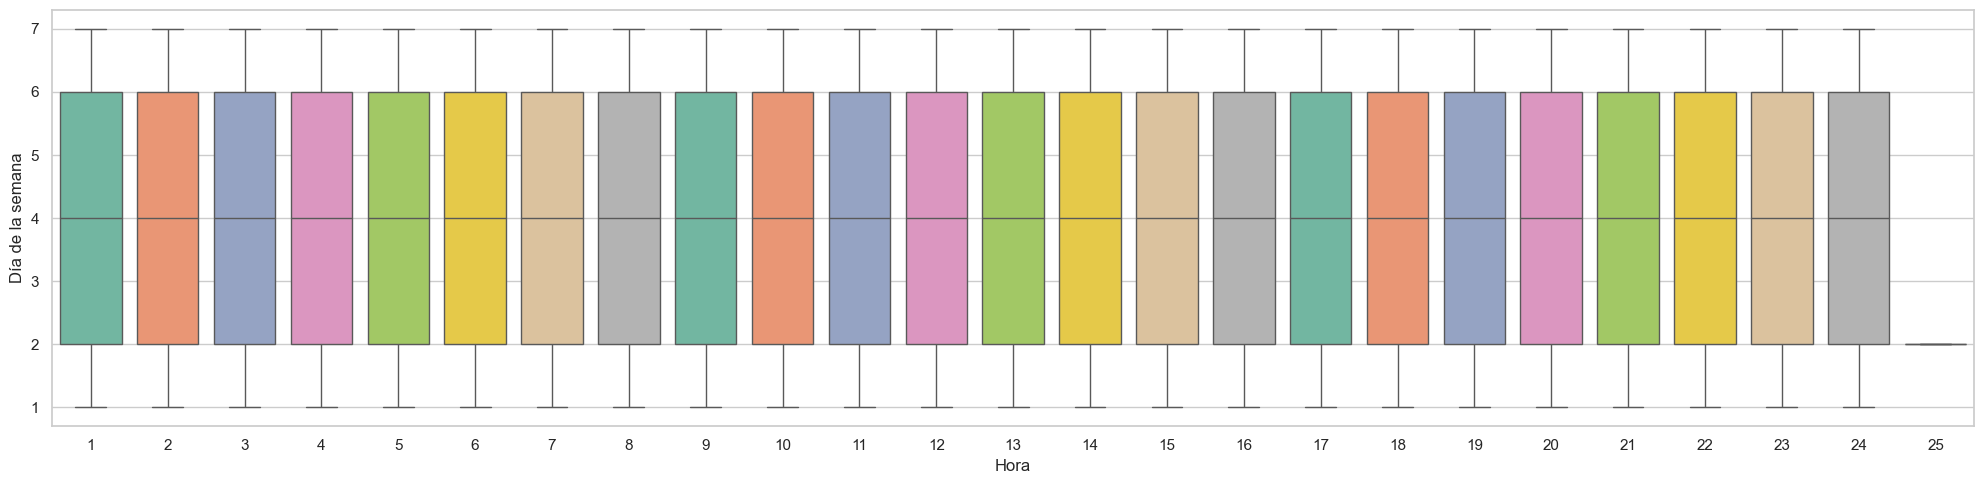

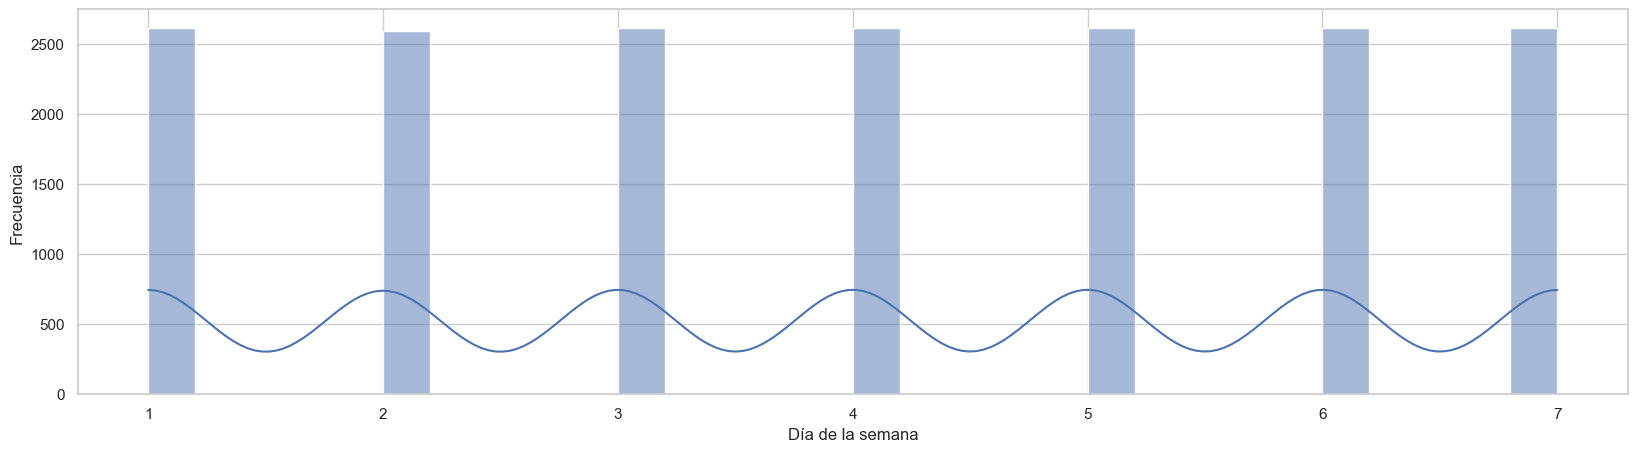

In [ ]:
EDA(13246, 13946, 'iNumDiaSemana', 'Día de la semana', False)

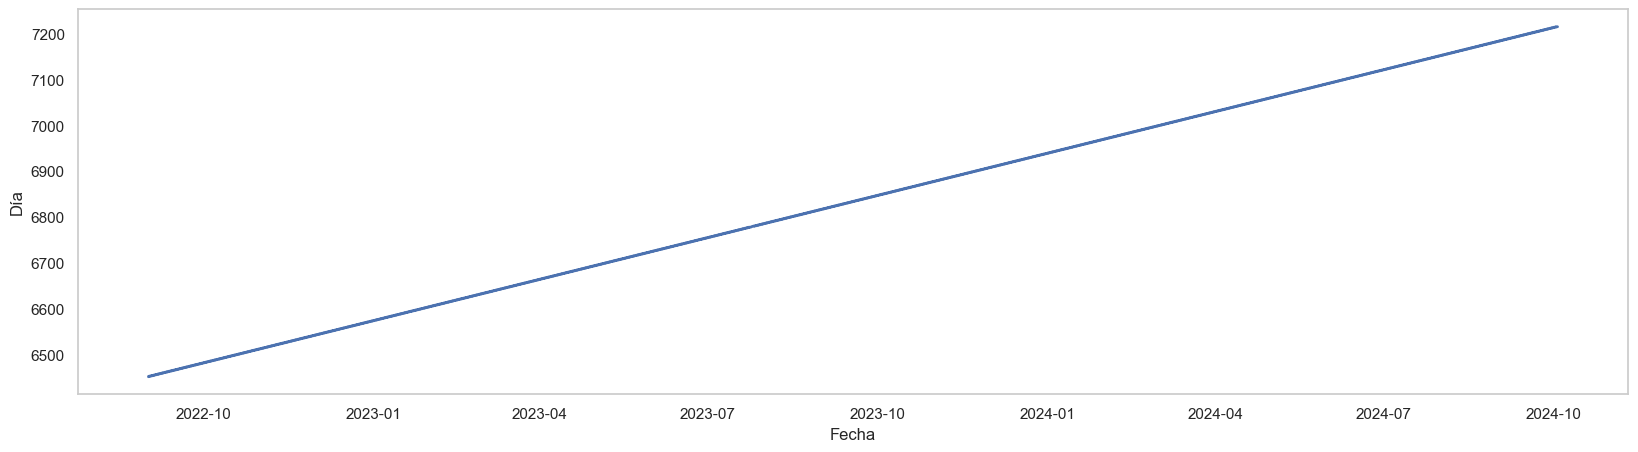

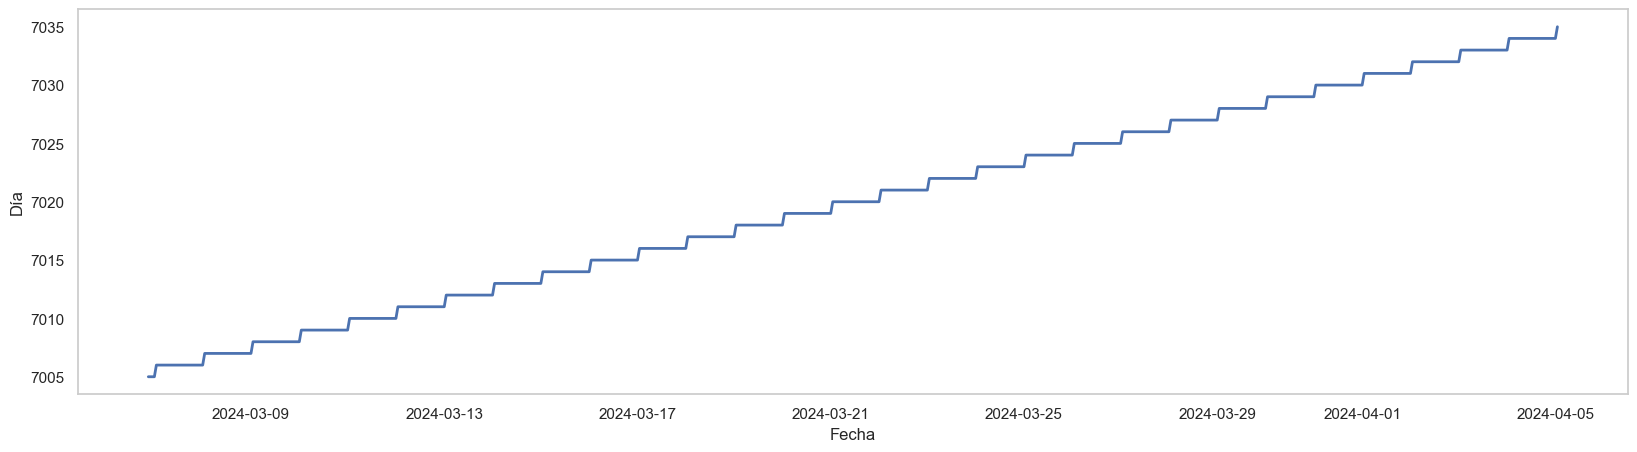

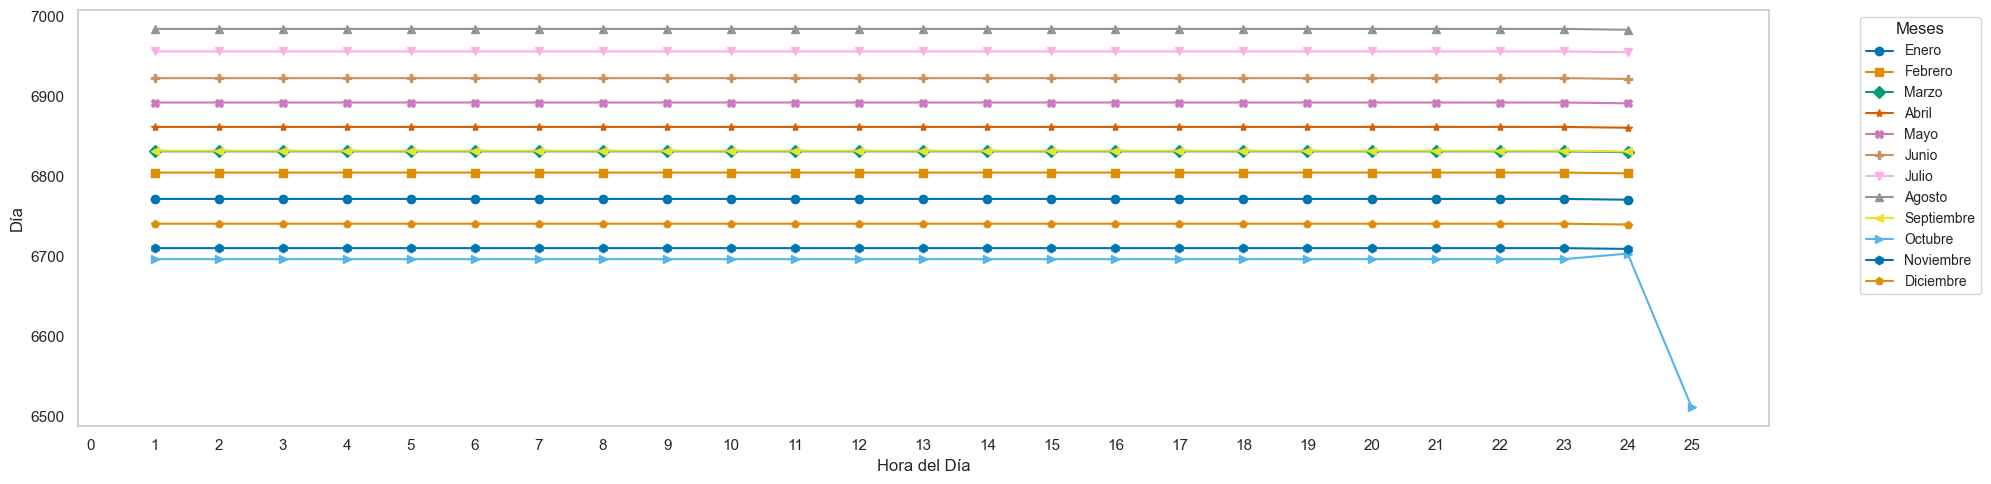

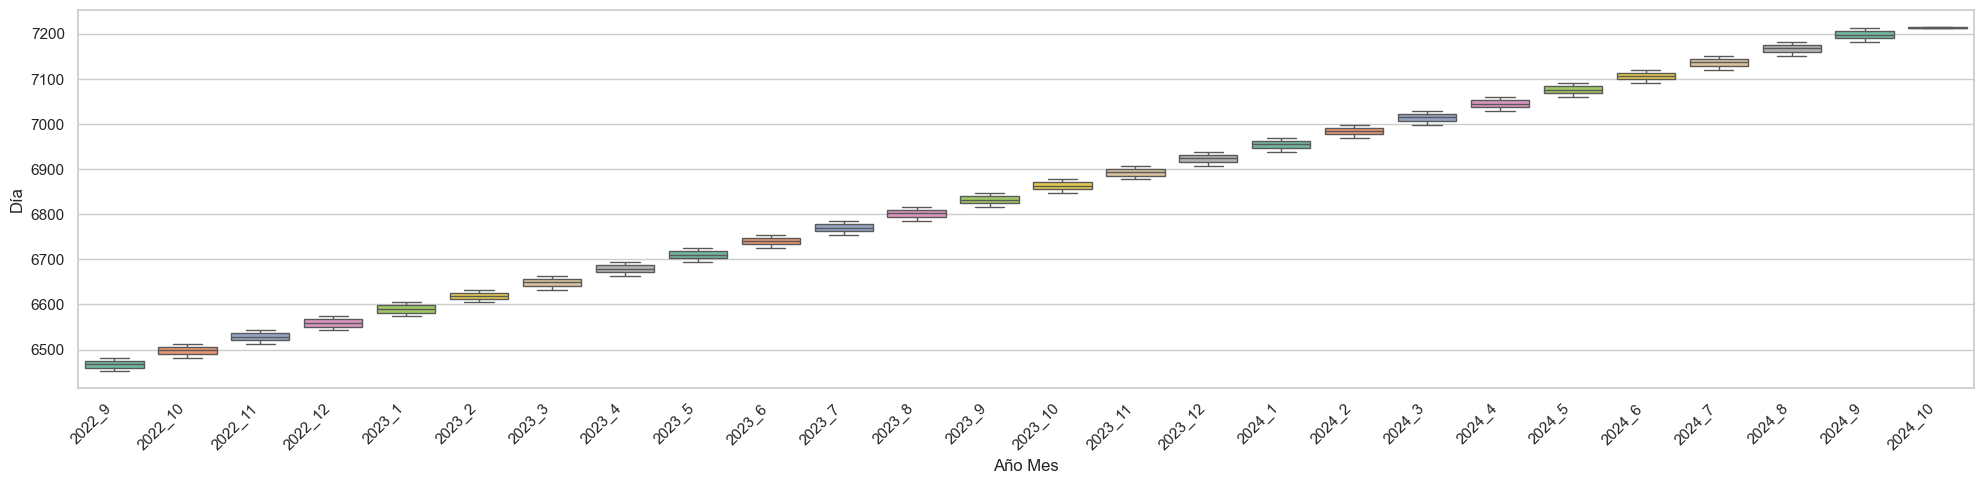

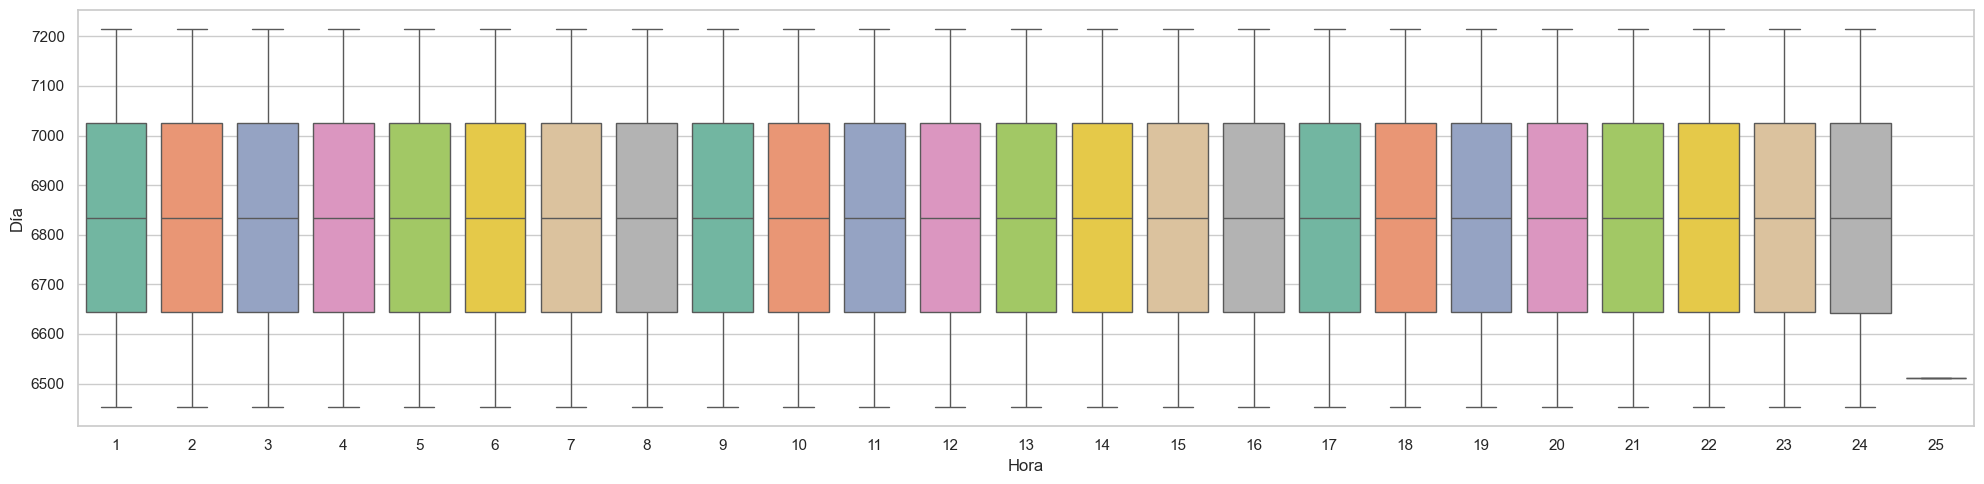

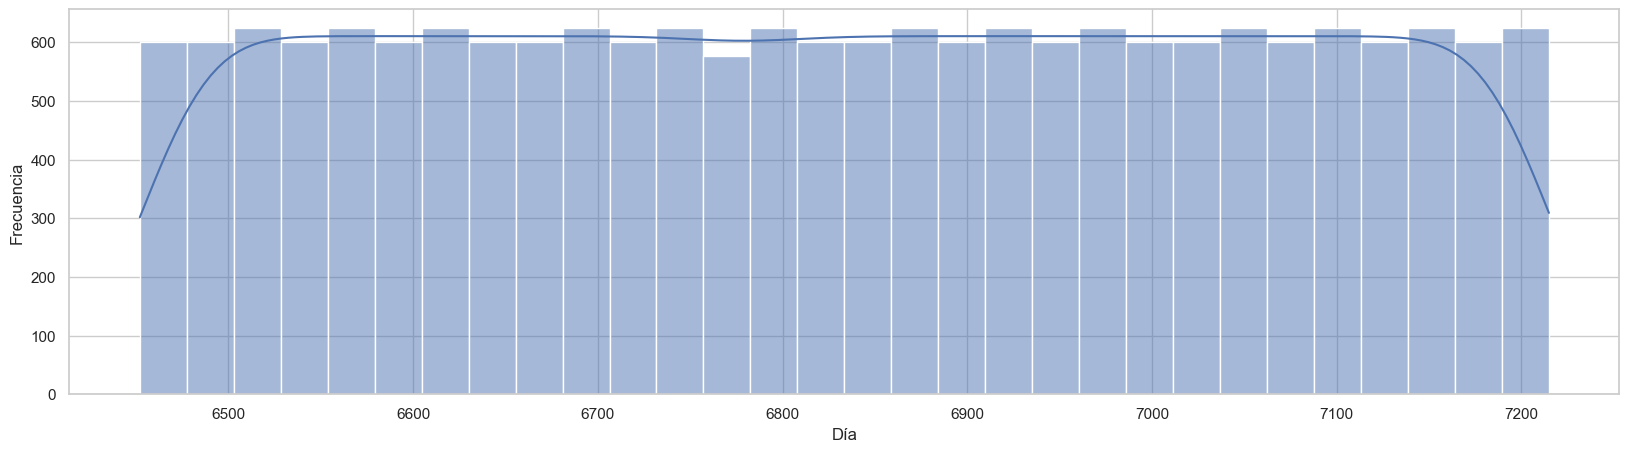

In [ ]:
EDA(13246, 13946, 'iCodDia', 'Día', False)

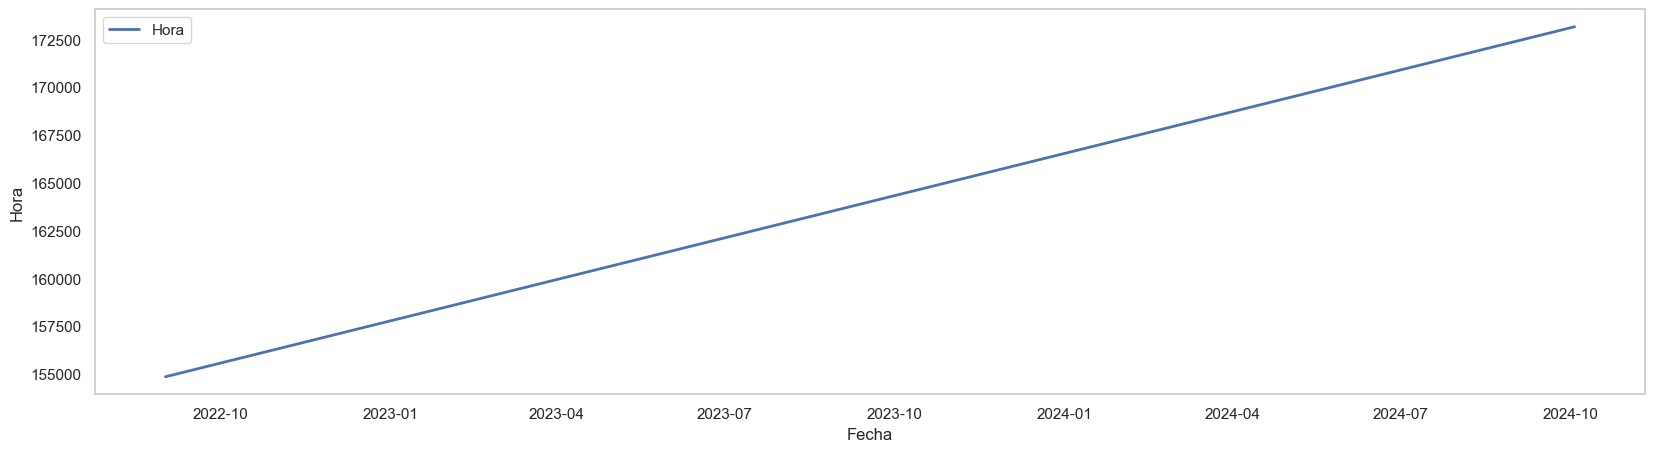

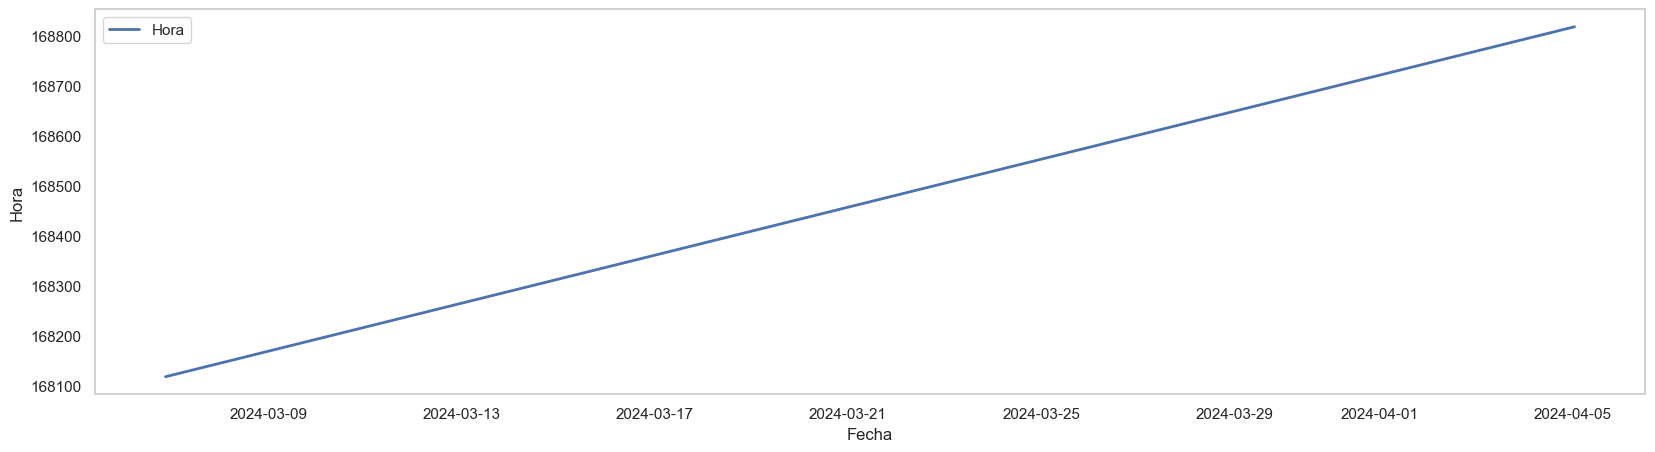

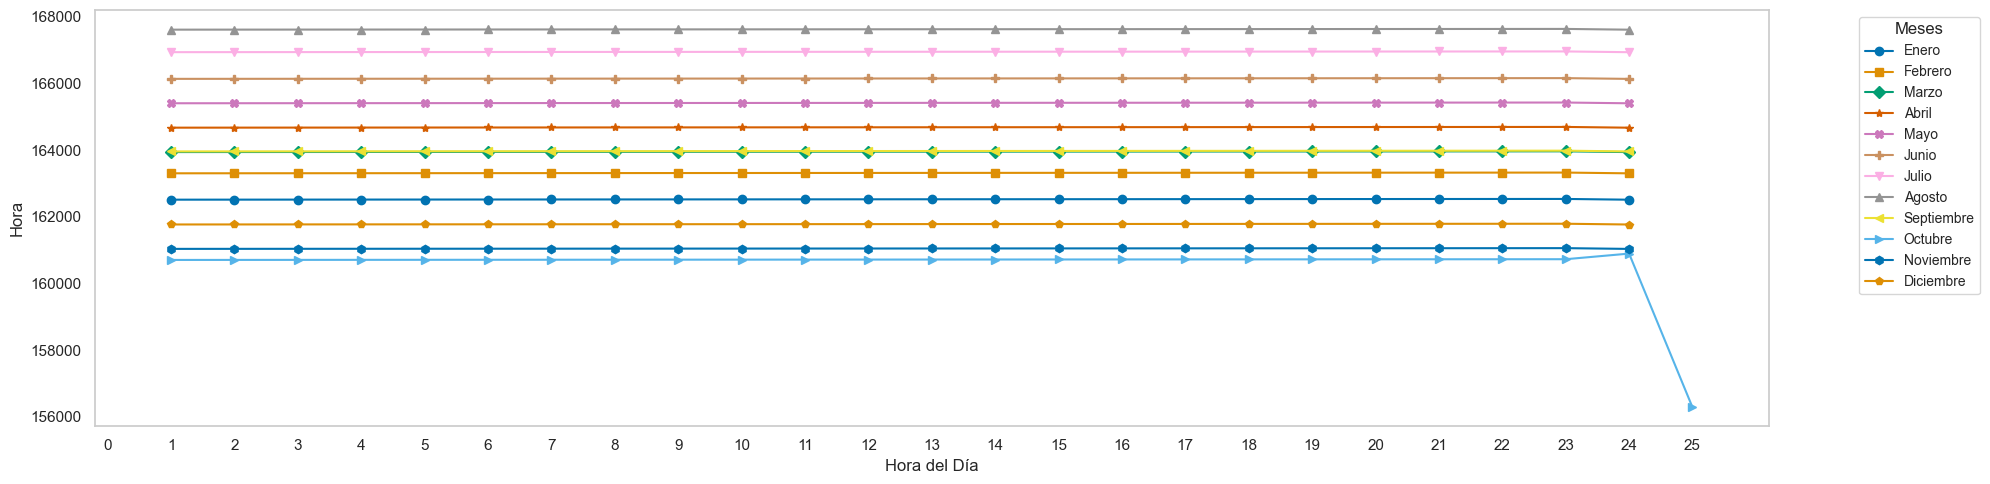

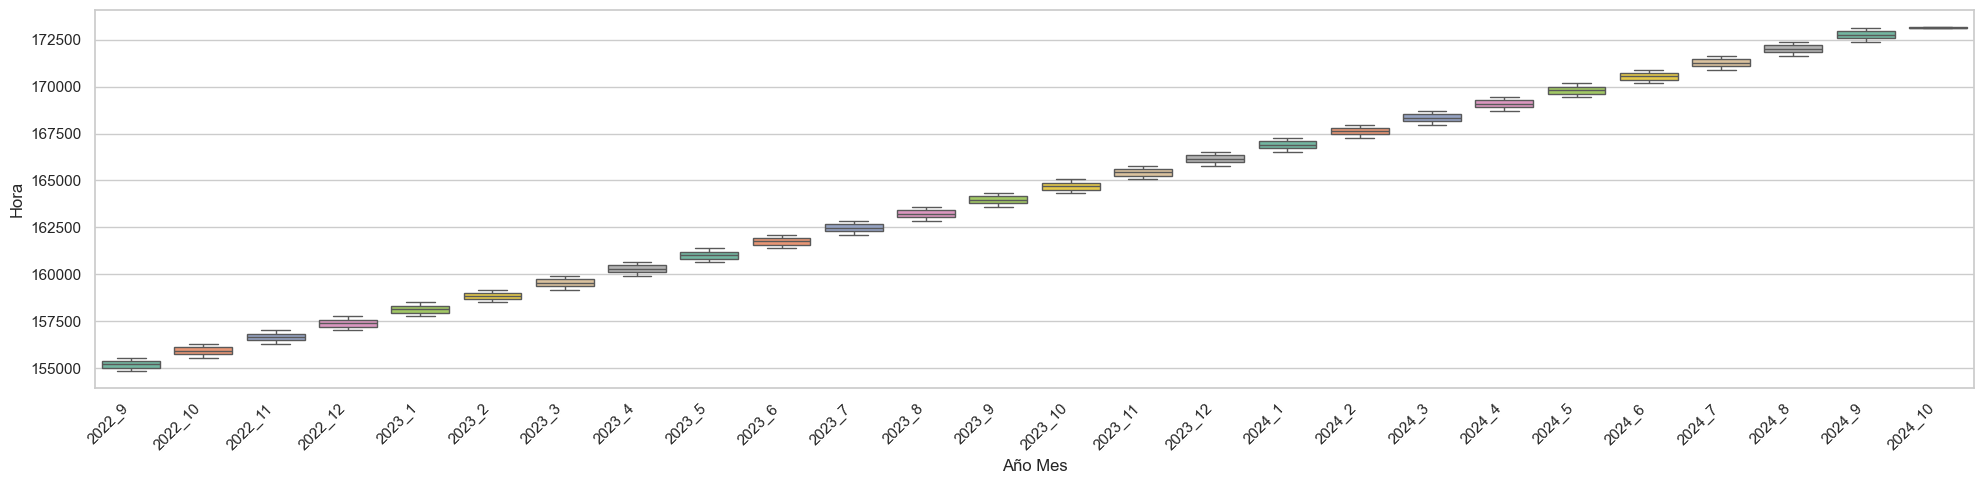

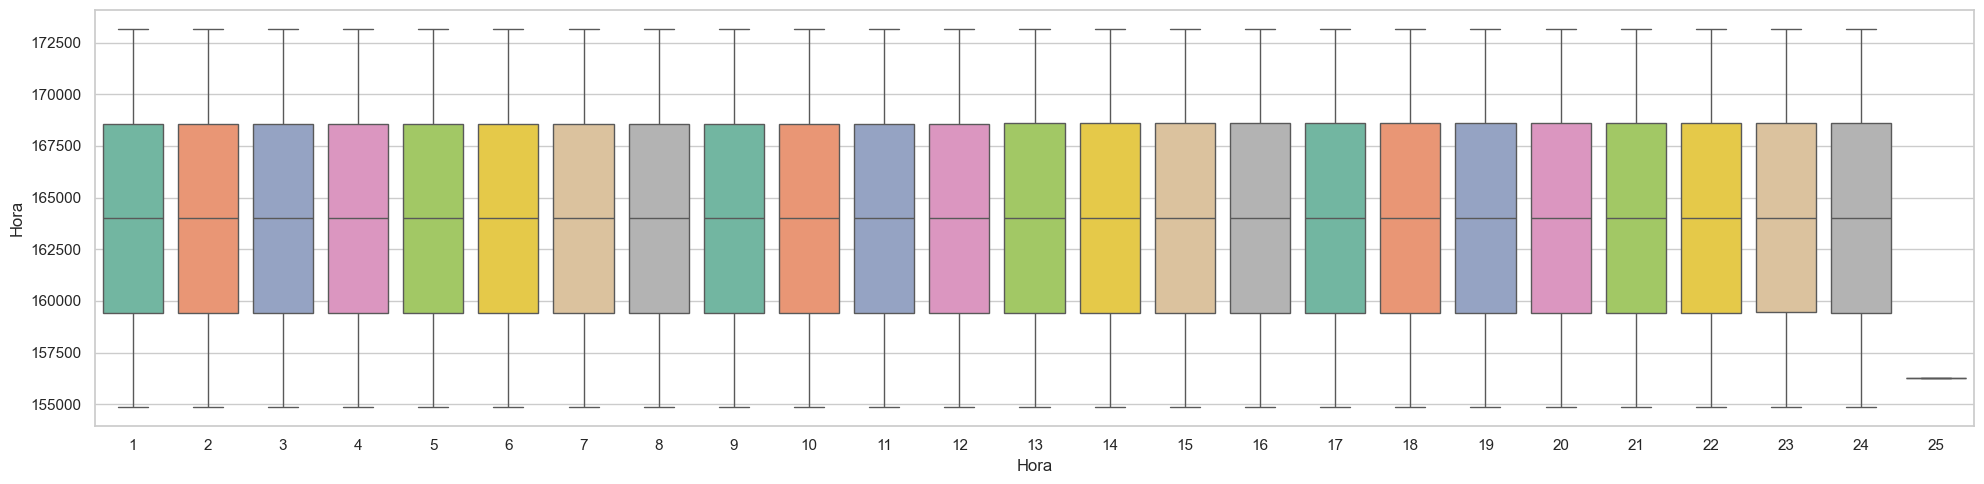

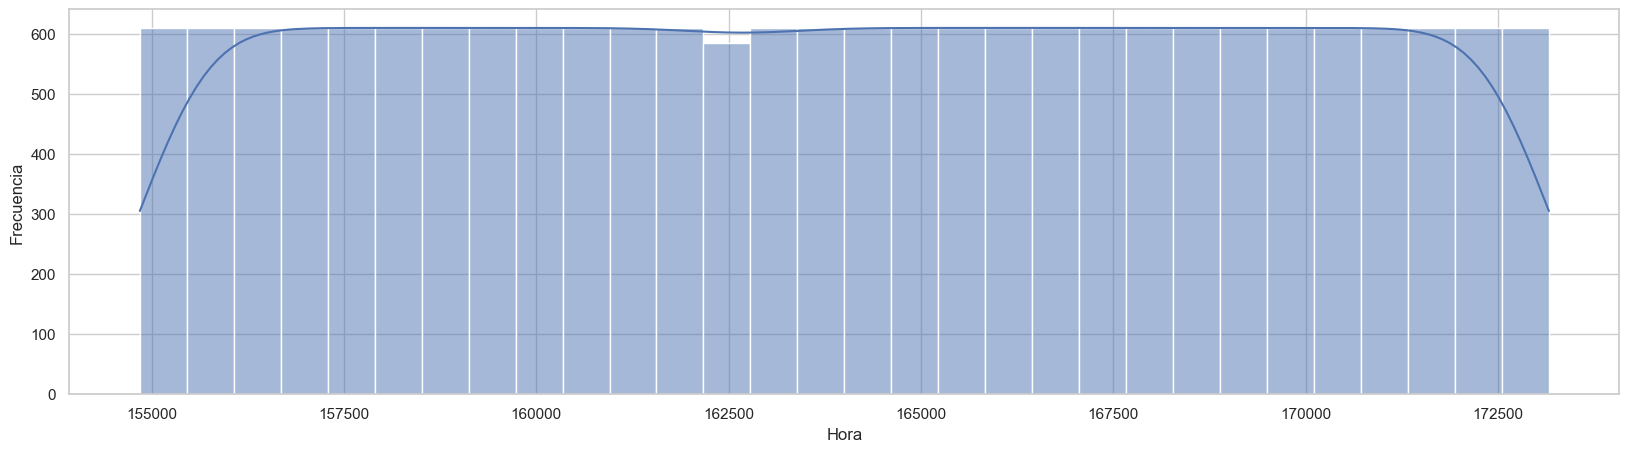

In [ ]:
EDA(13246, 13946, 'iCodHora', 'Hora', False)

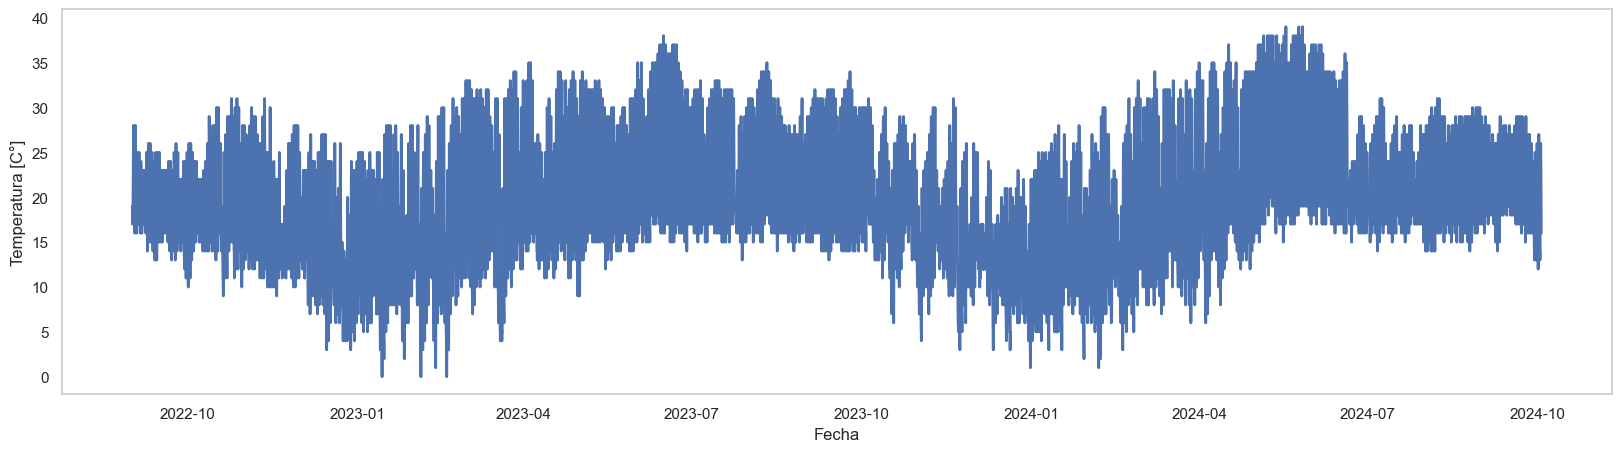

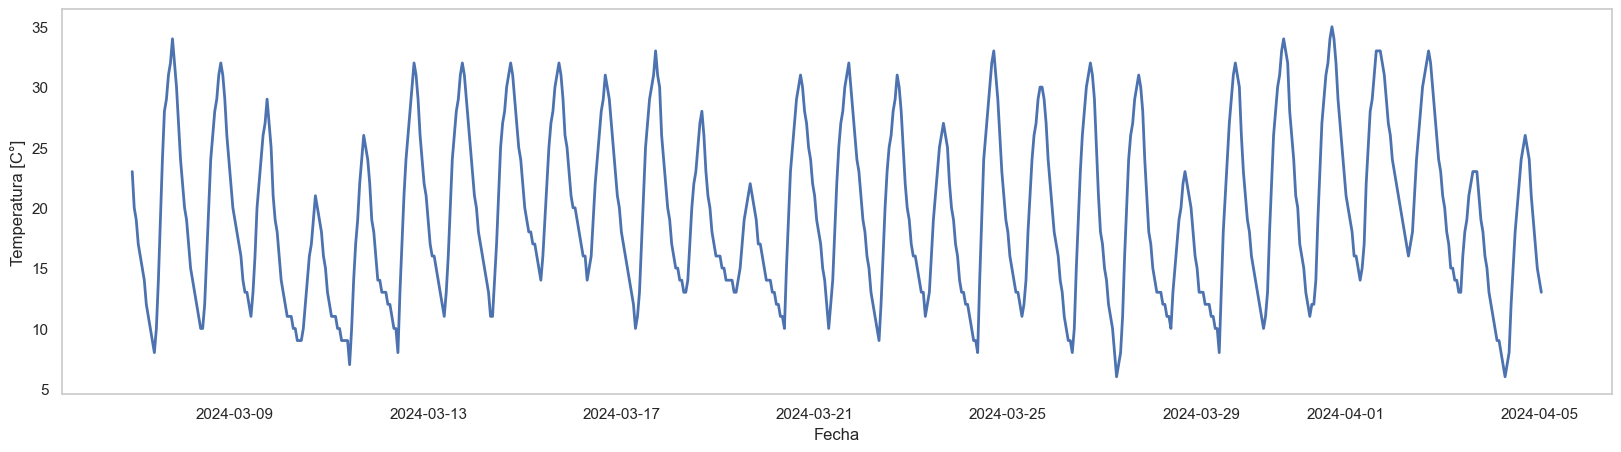

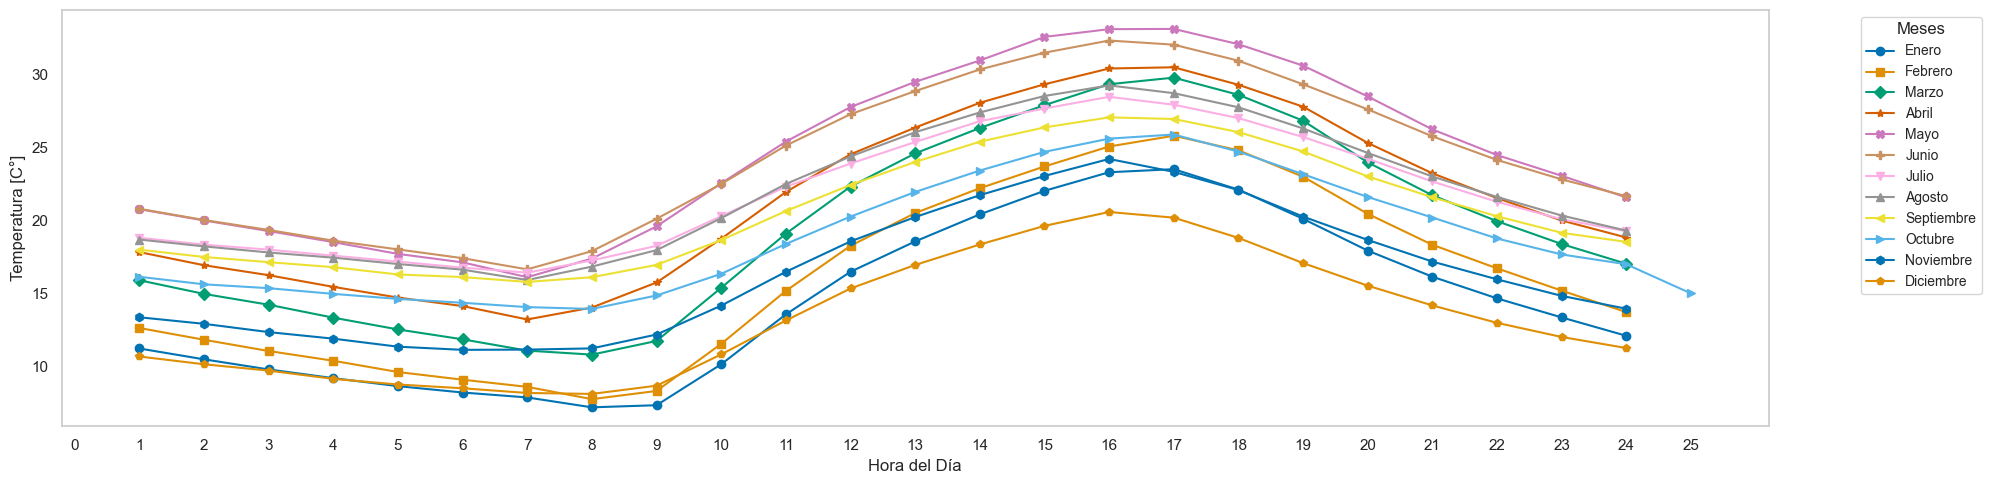

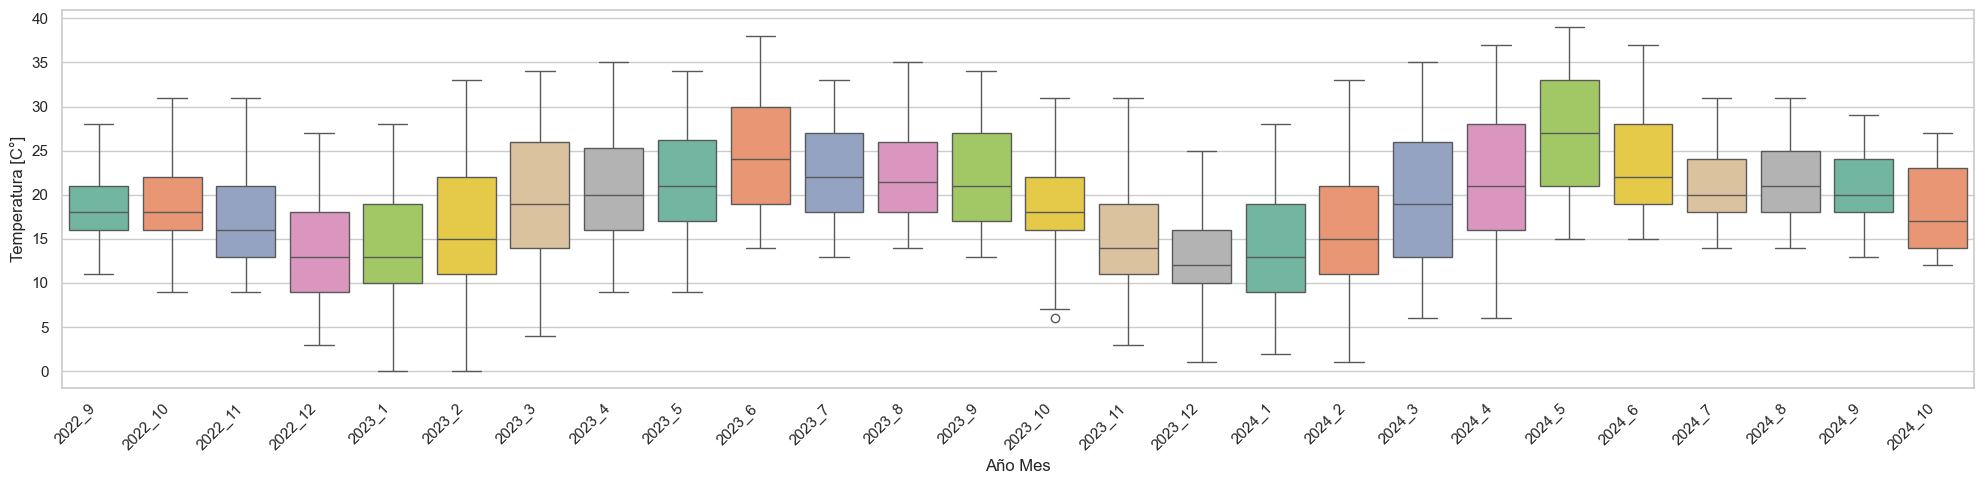

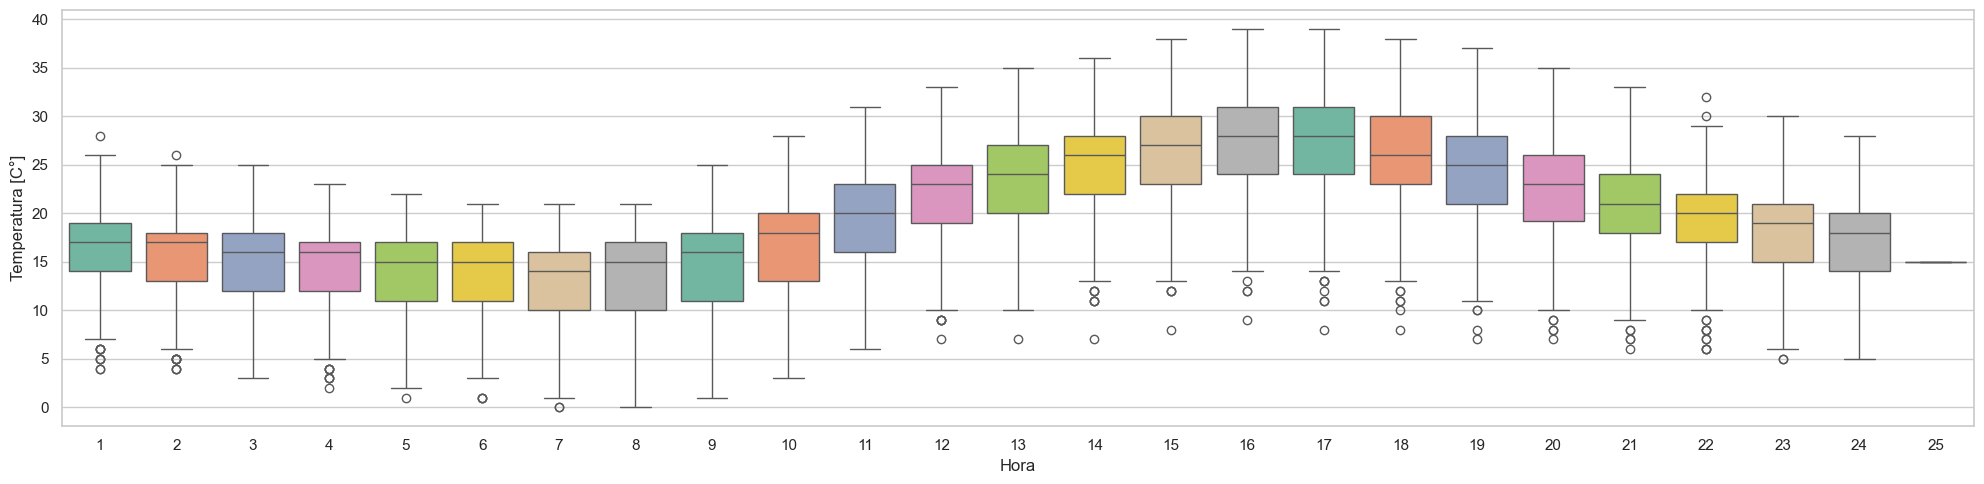

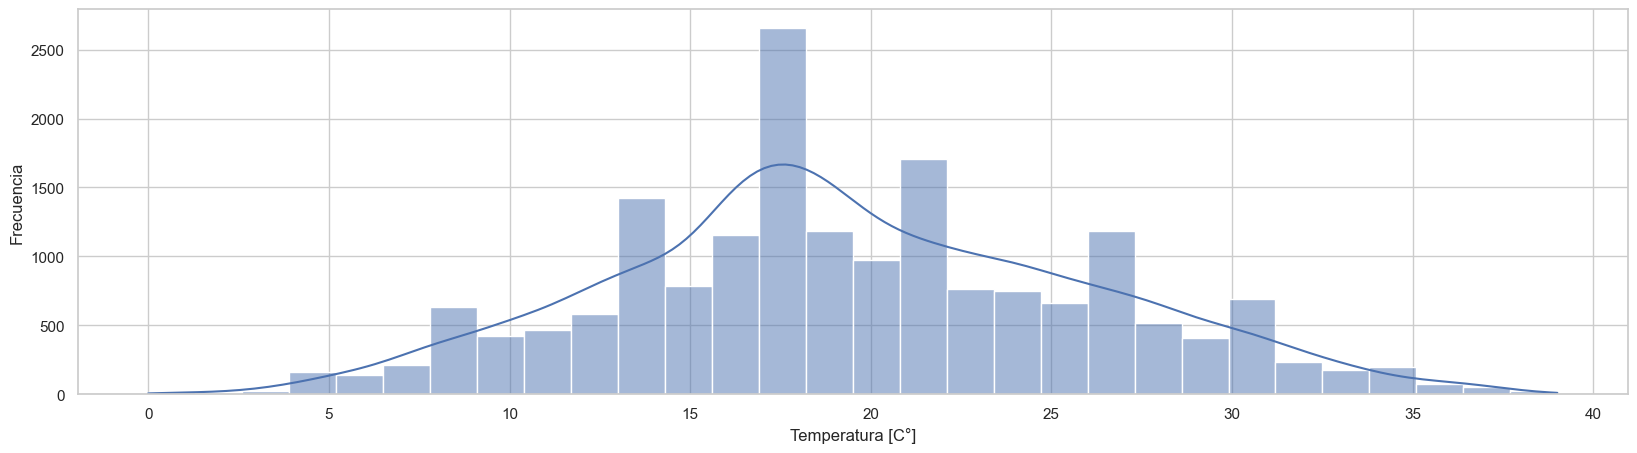

In [ ]:
EDA(13246, 13946, 'fltTemp', 'Temperatura [C°]', True)

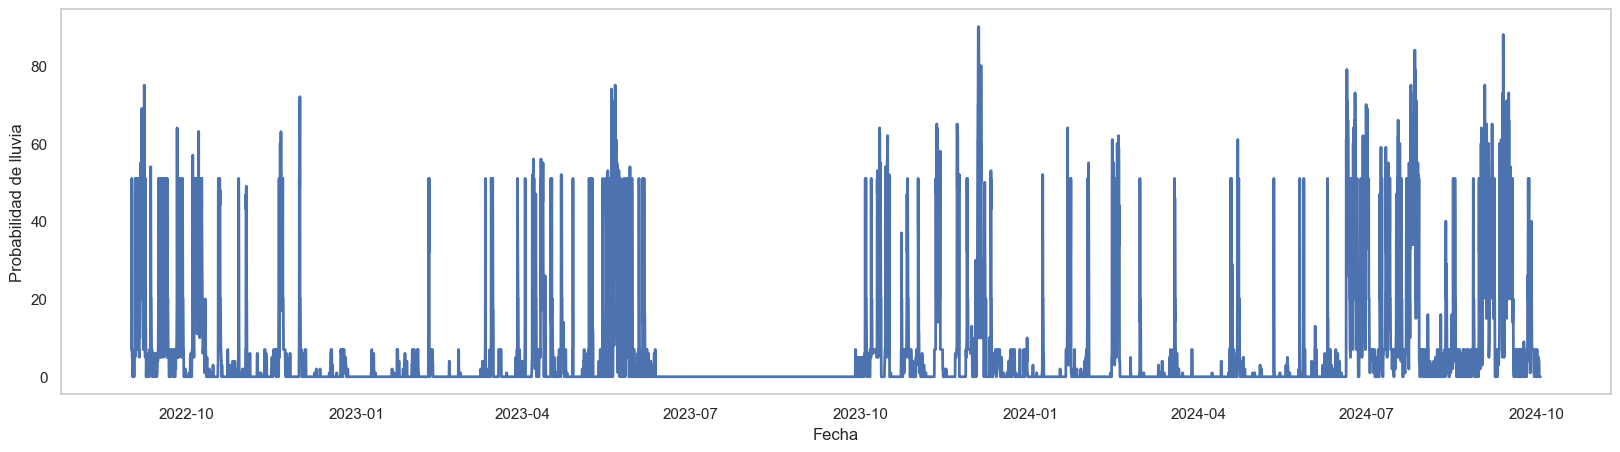

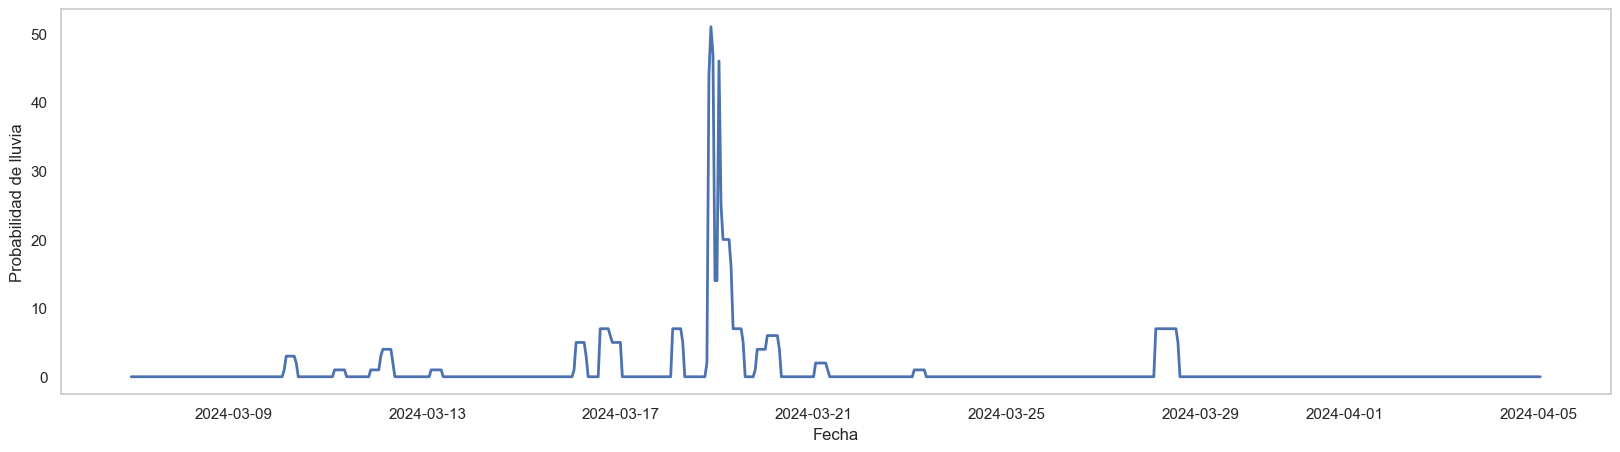

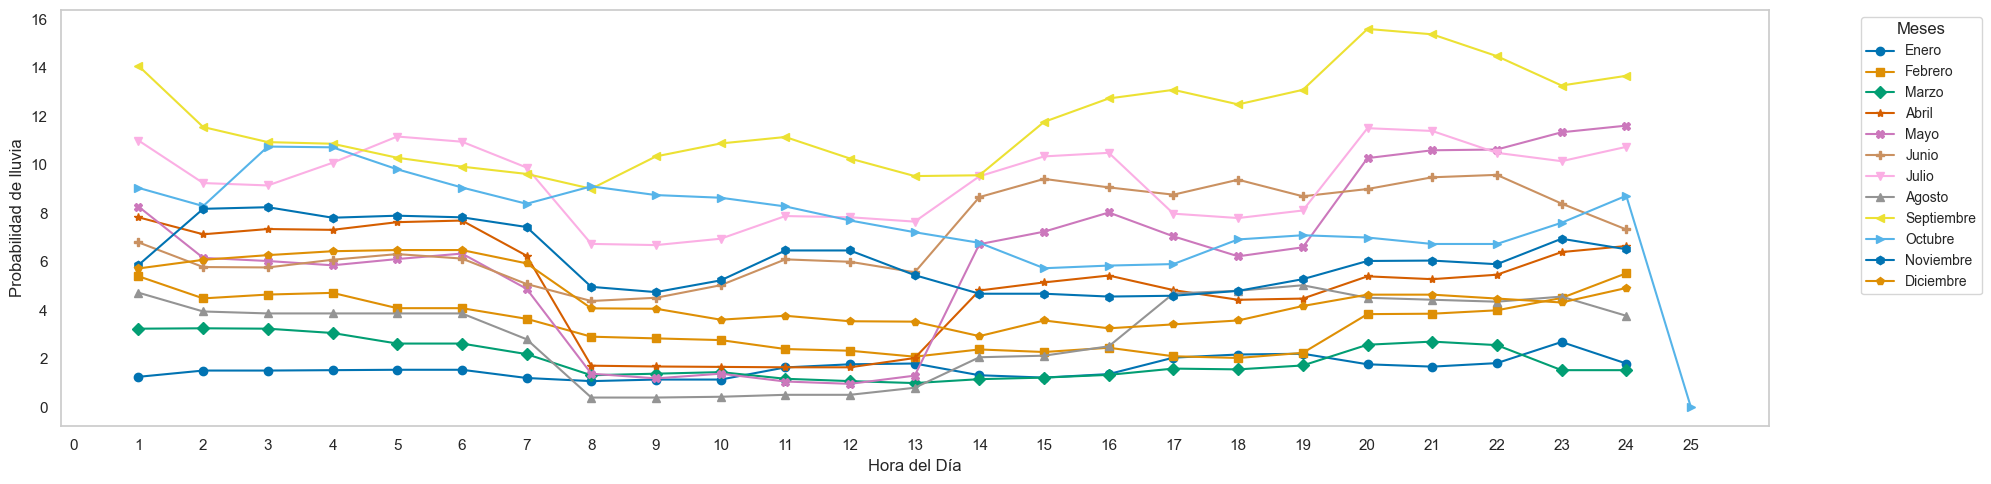

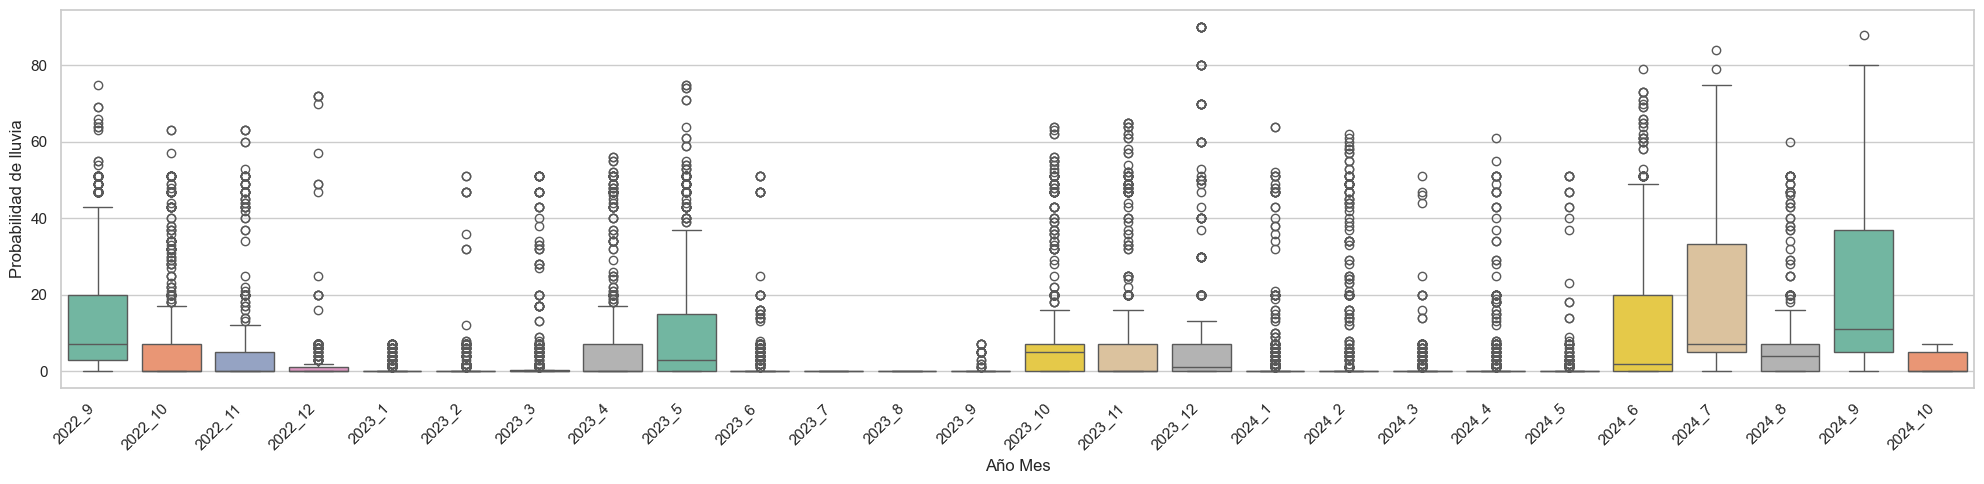

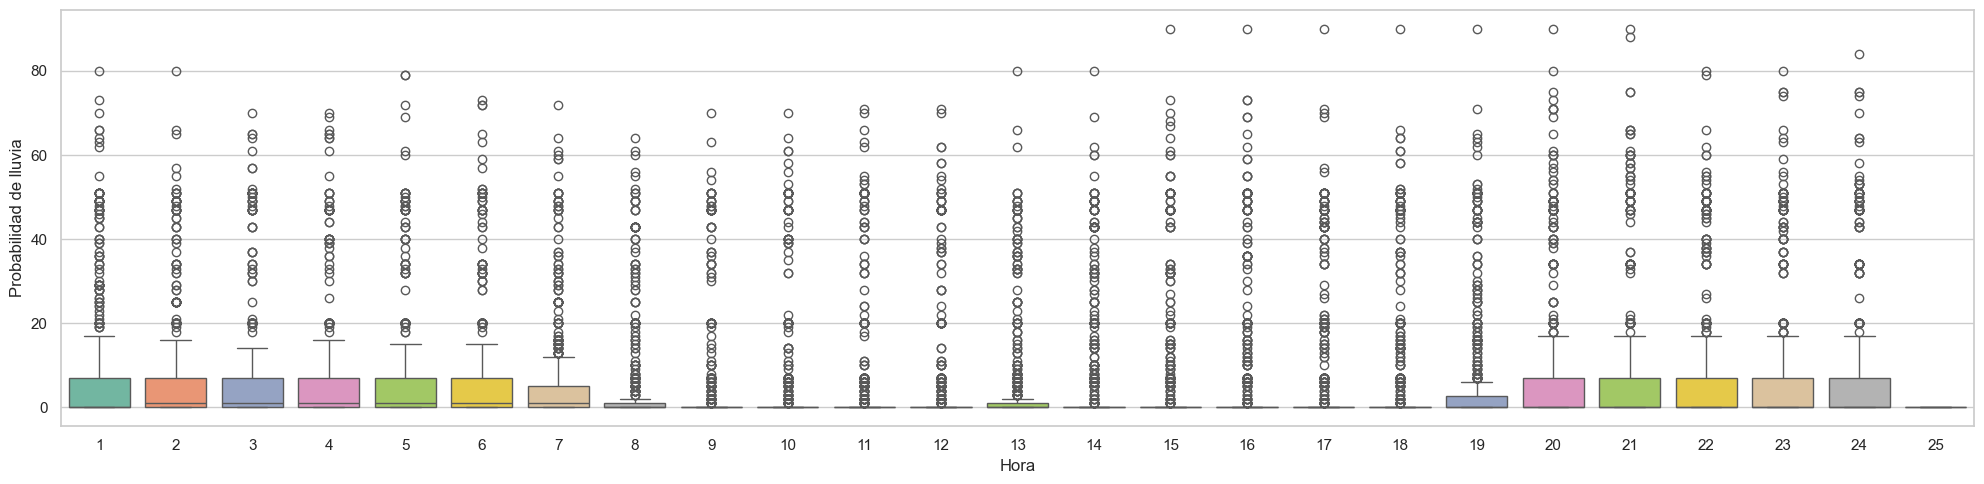

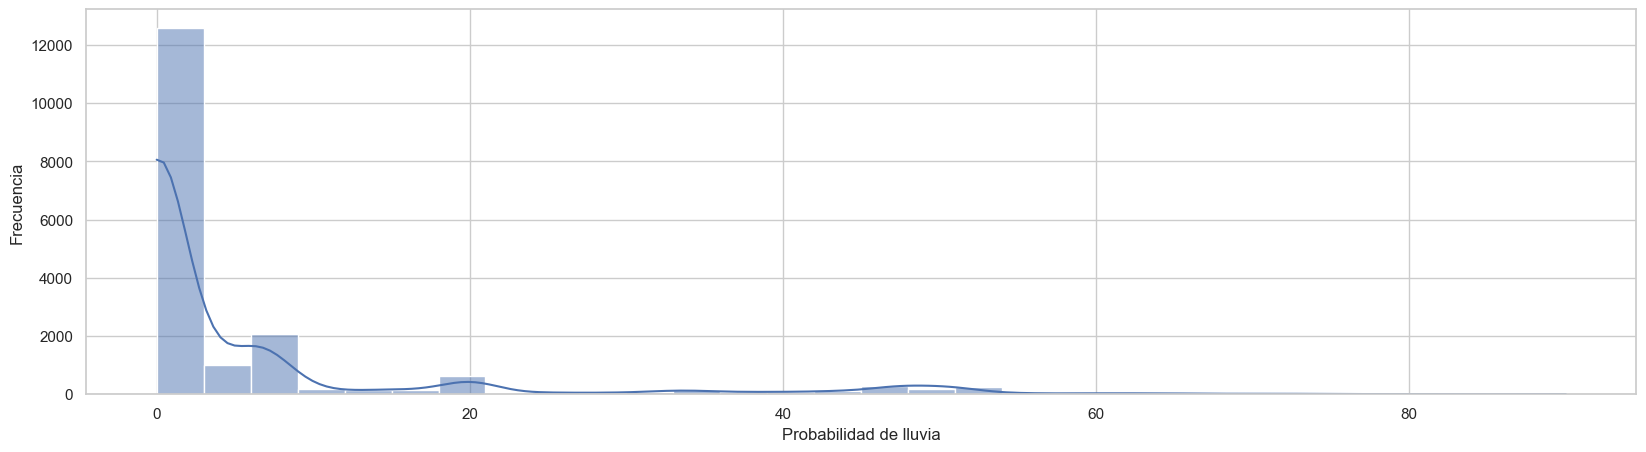

In [ ]:
EDA(13246, 13946, 'fltProbabilidadLluvia', 'Probabilidad de lluvia', True)

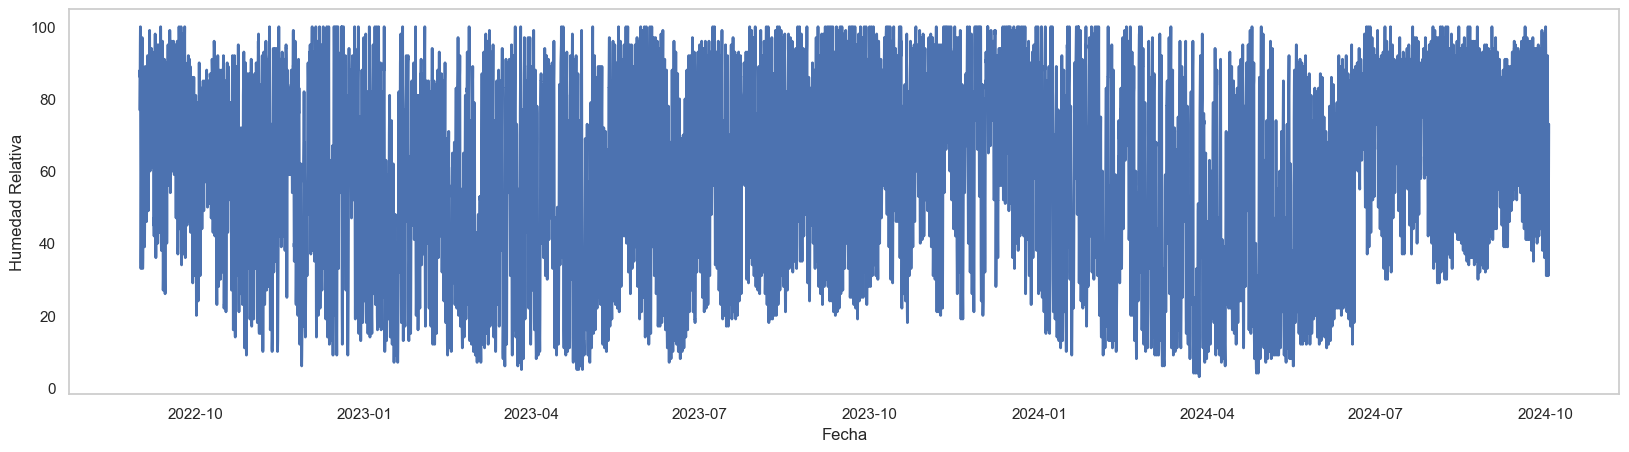

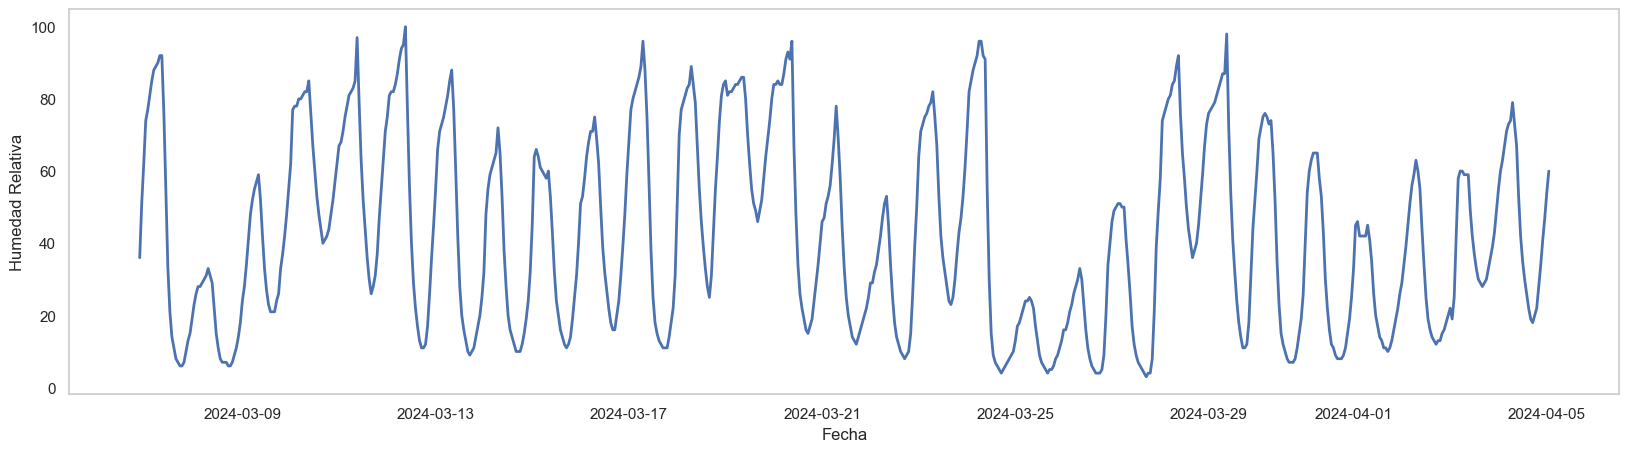

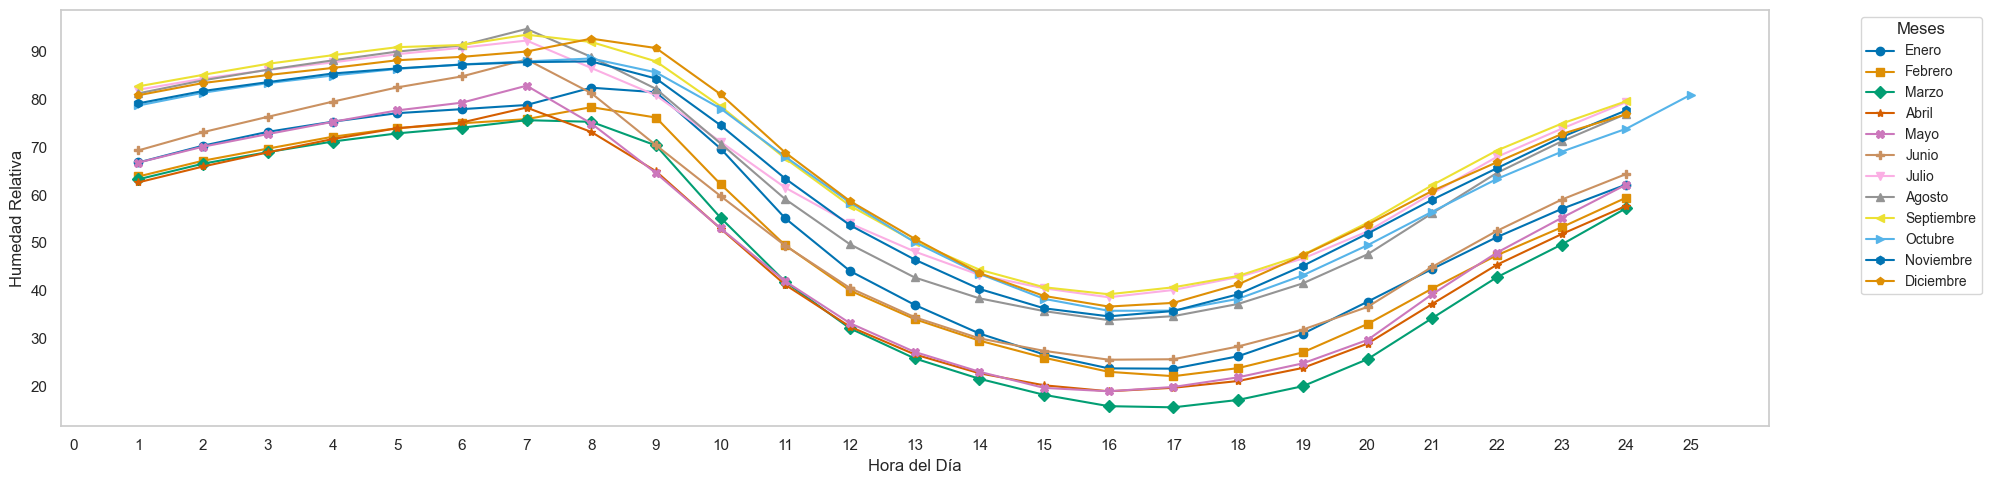

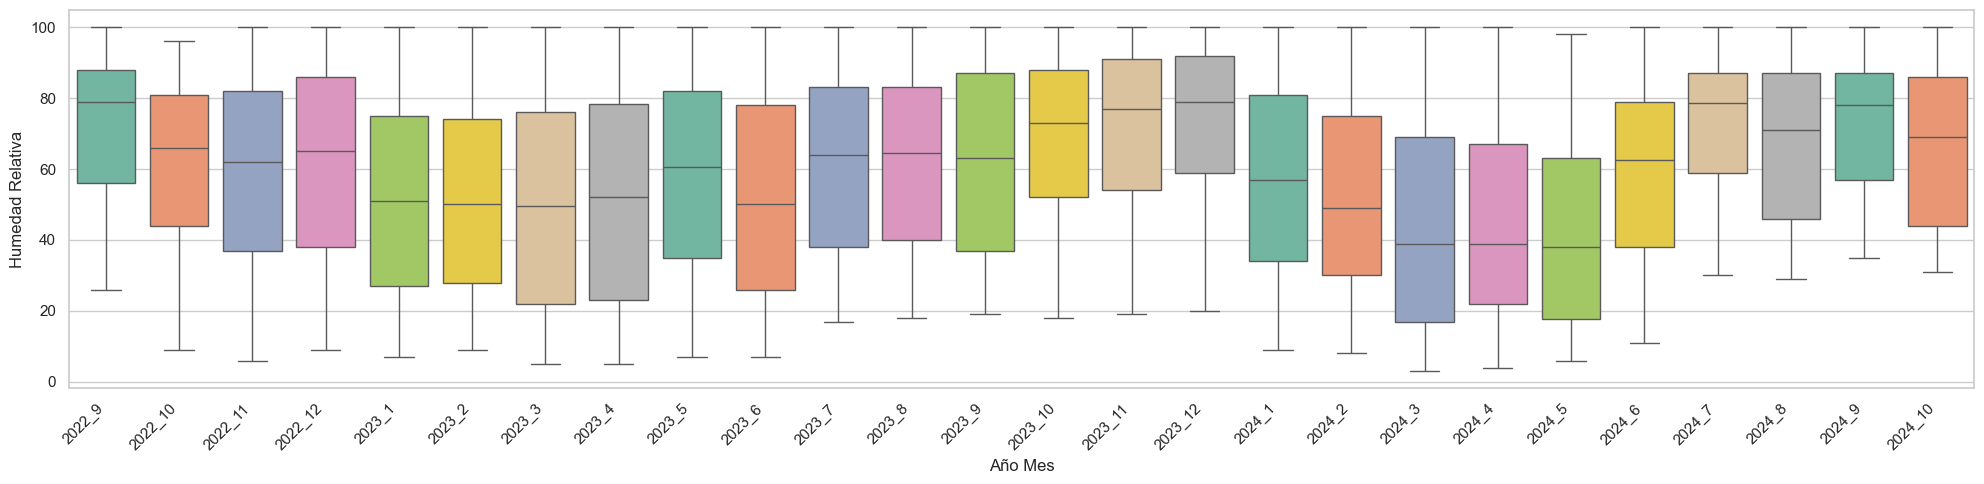

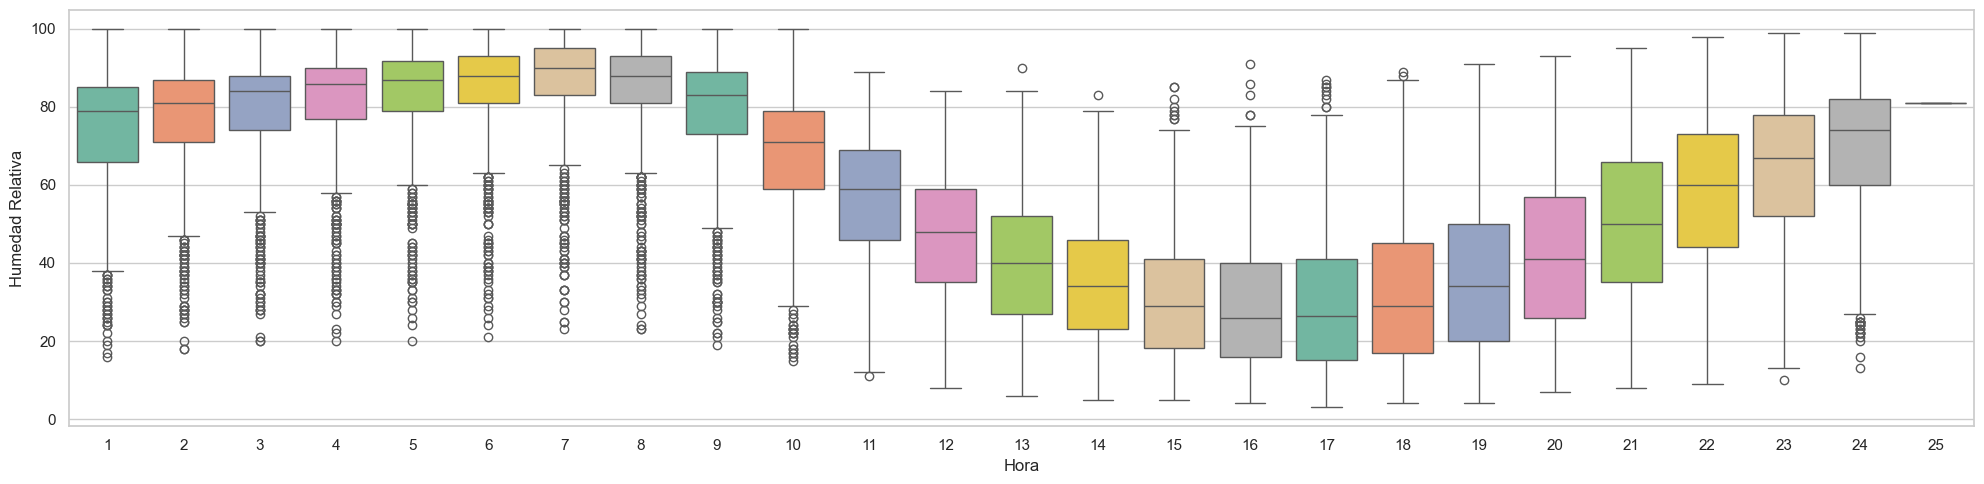

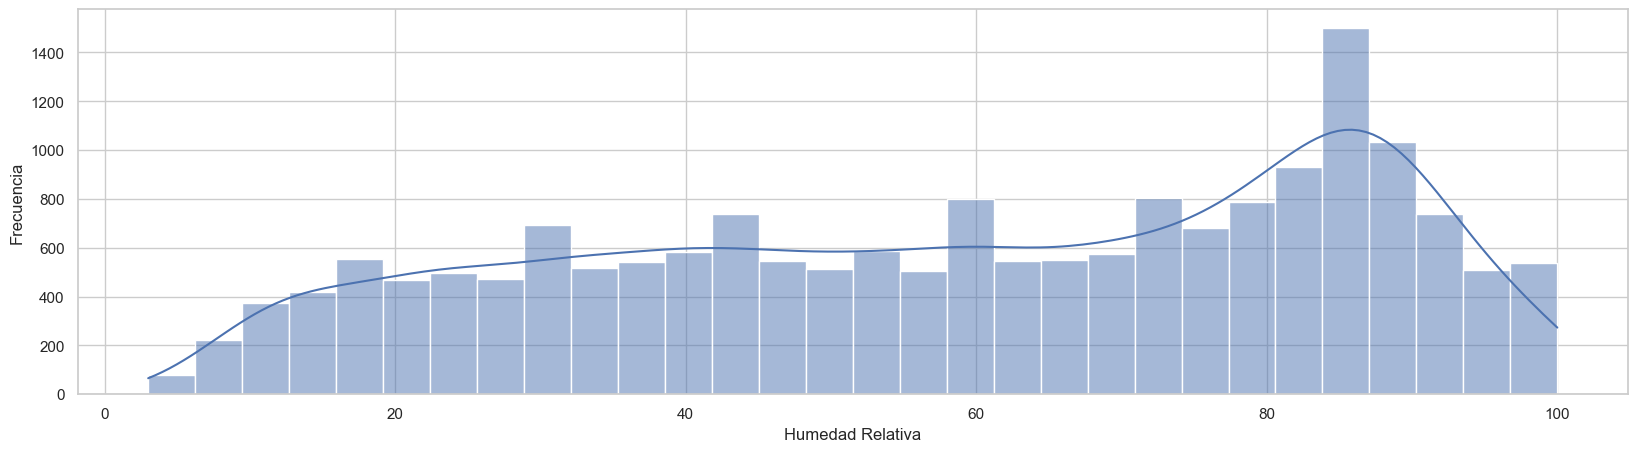

In [ ]:
EDA(13246, 13946, 'fltHumedadRelativa', 'Humedad Relativa', True)

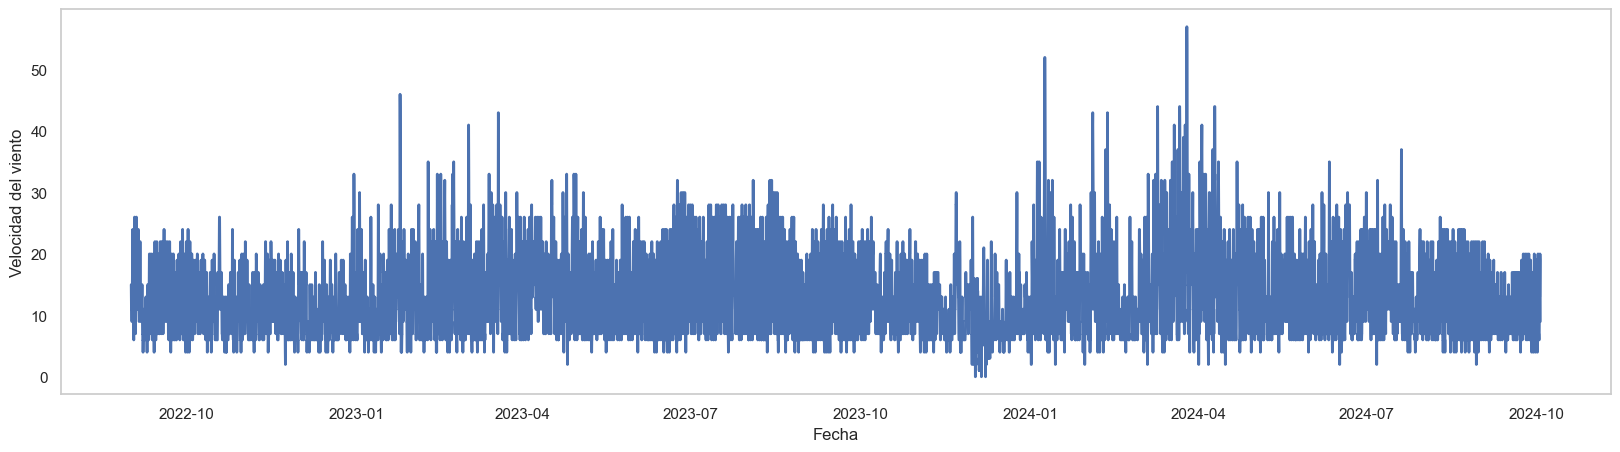

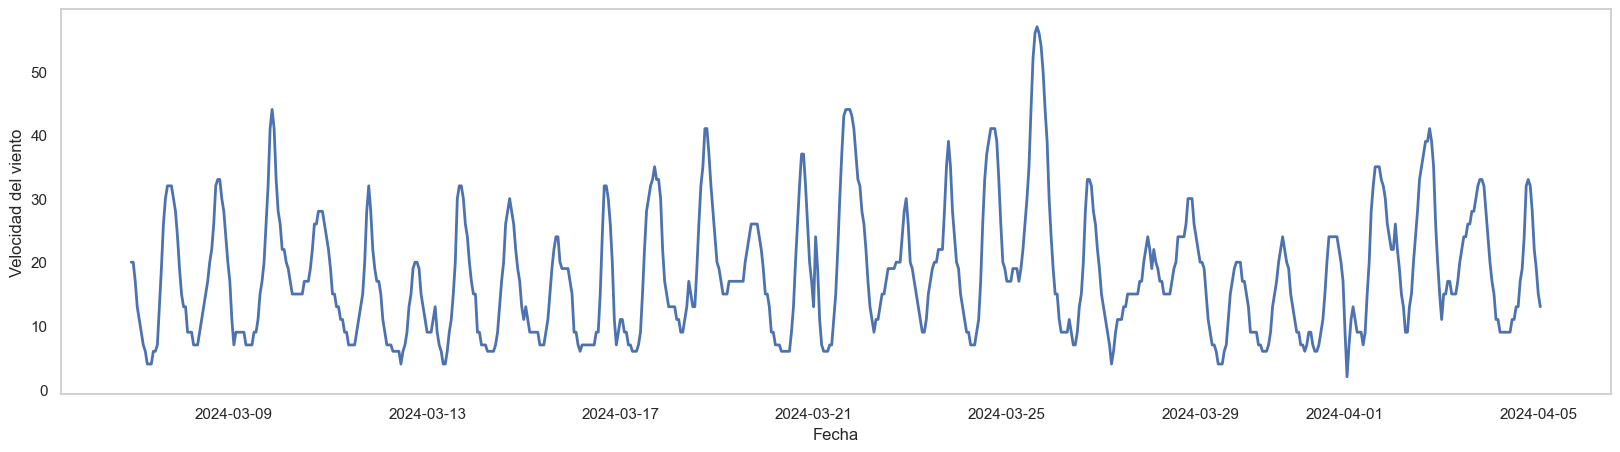

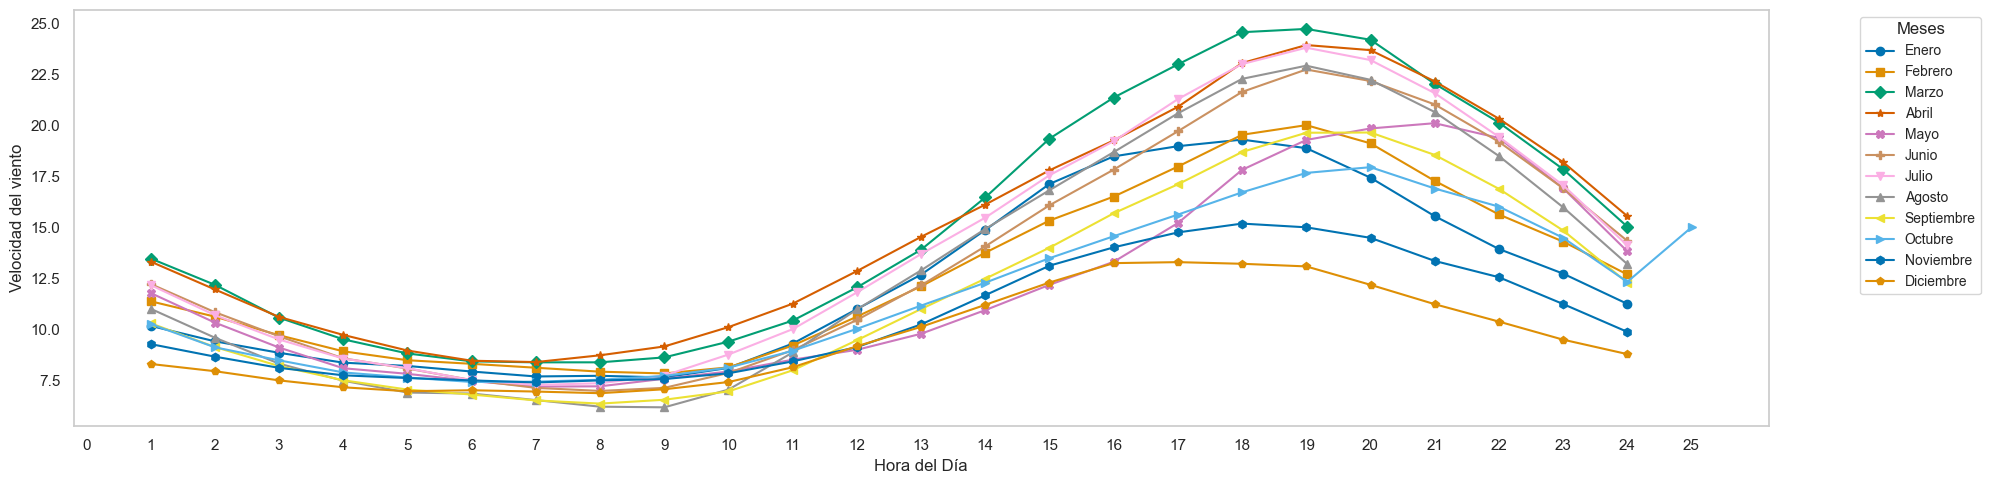

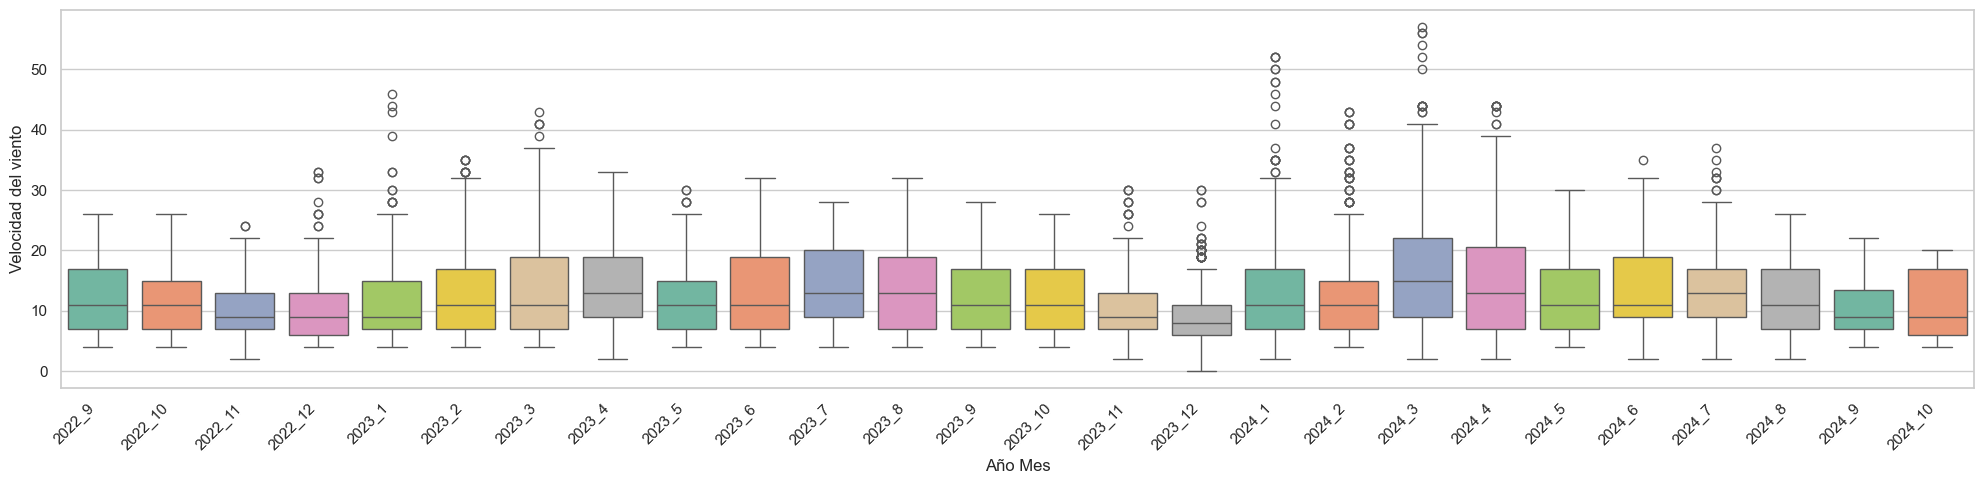

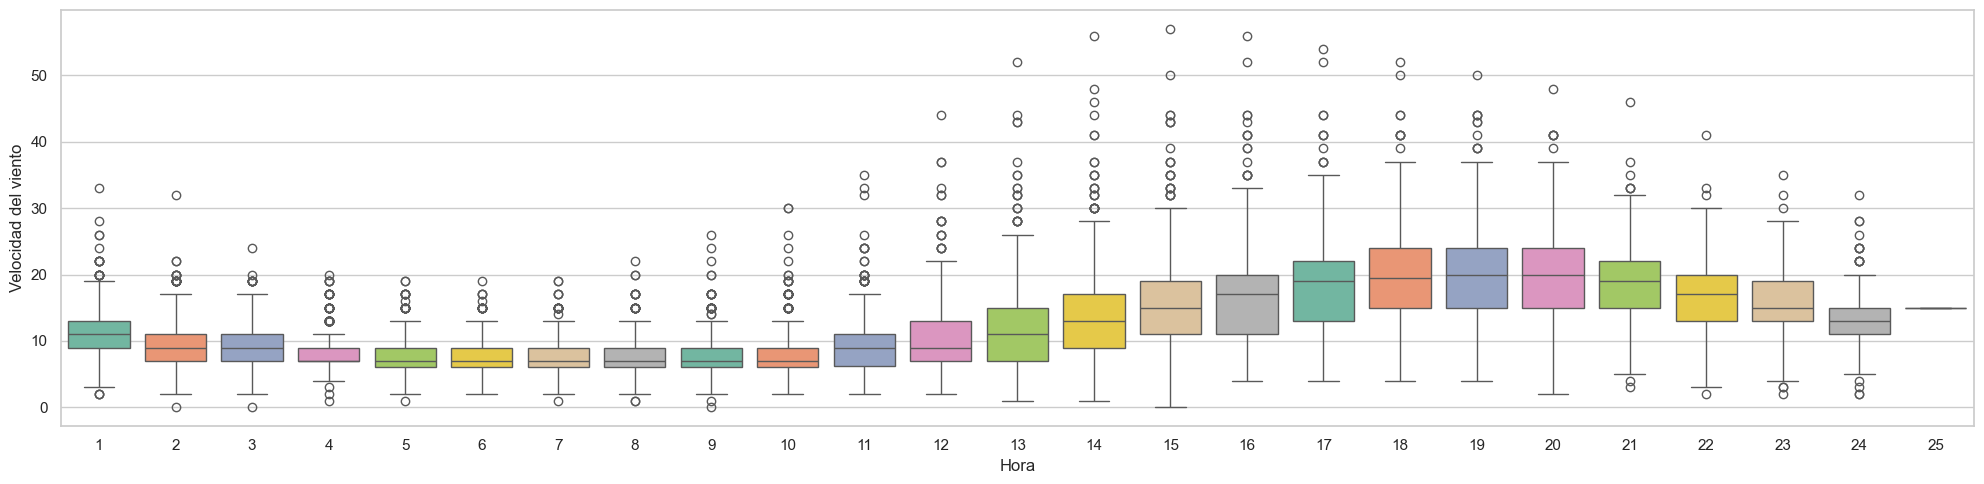

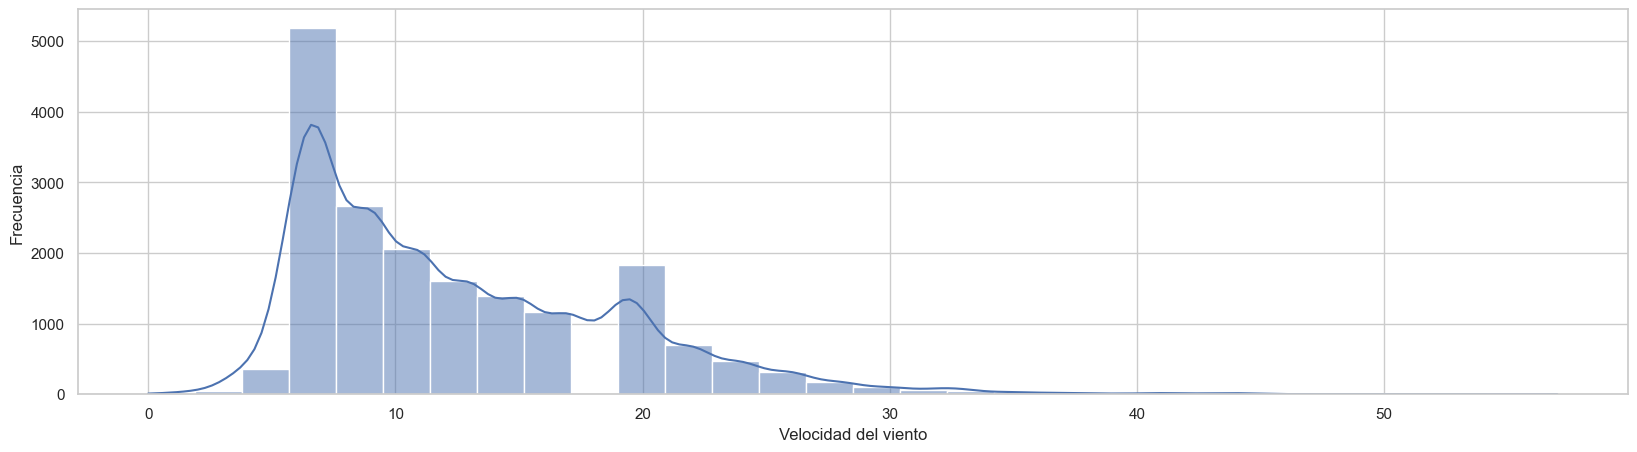

In [ ]:
EDA(13246, 13946, 'fltVelocidadViento', 'Velocidad del viento', True)

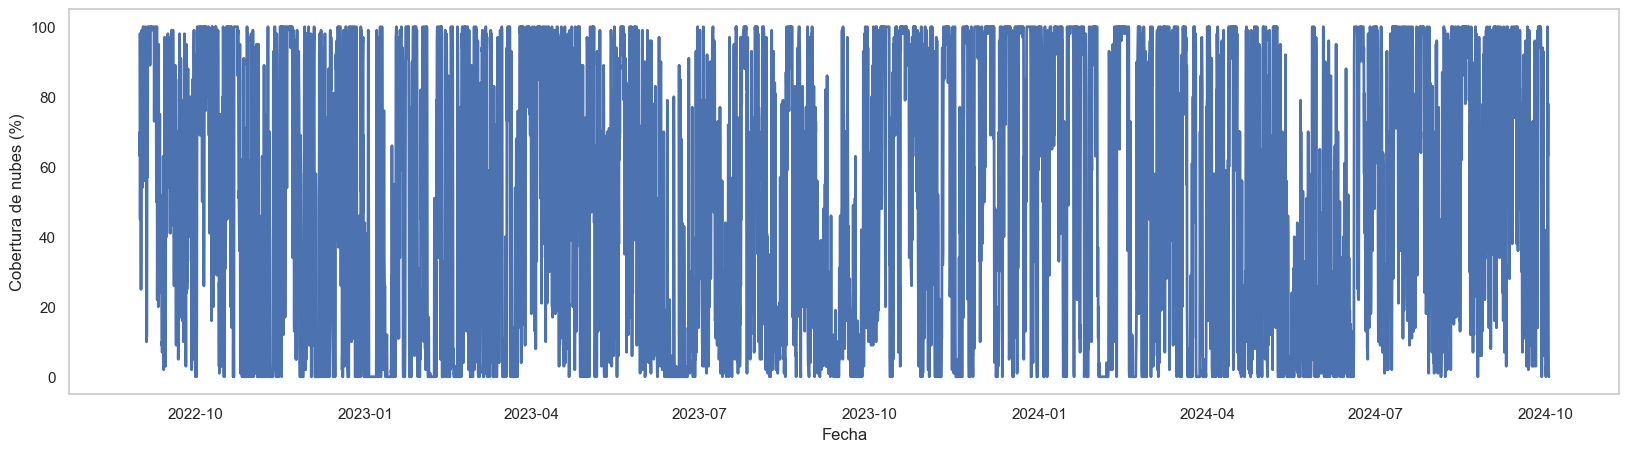

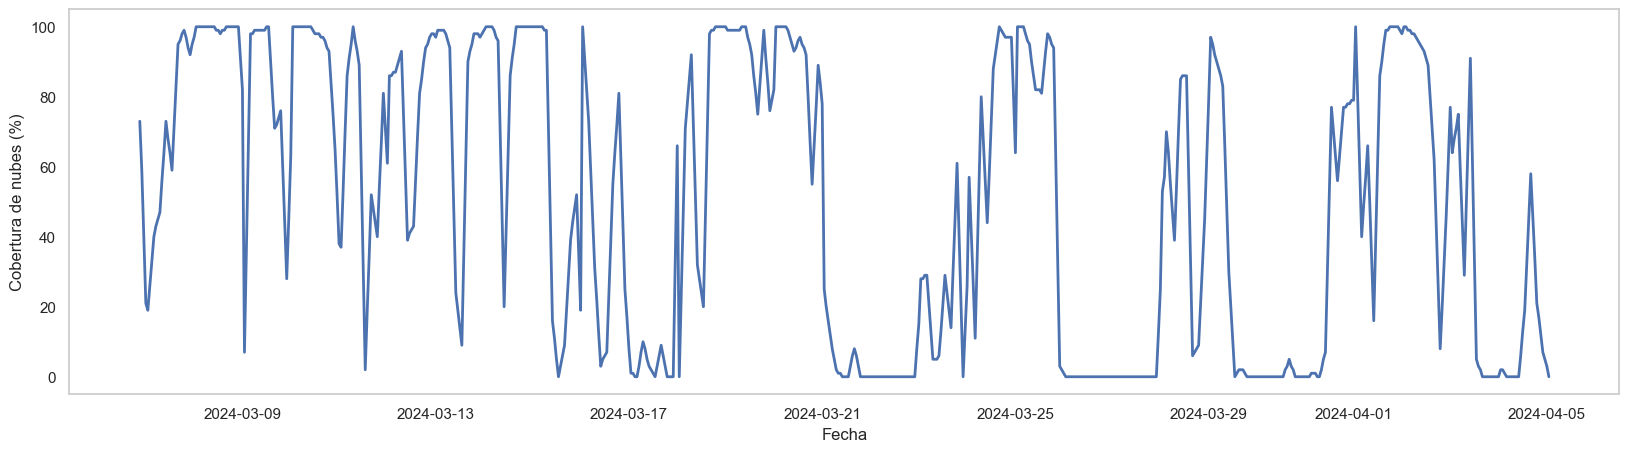

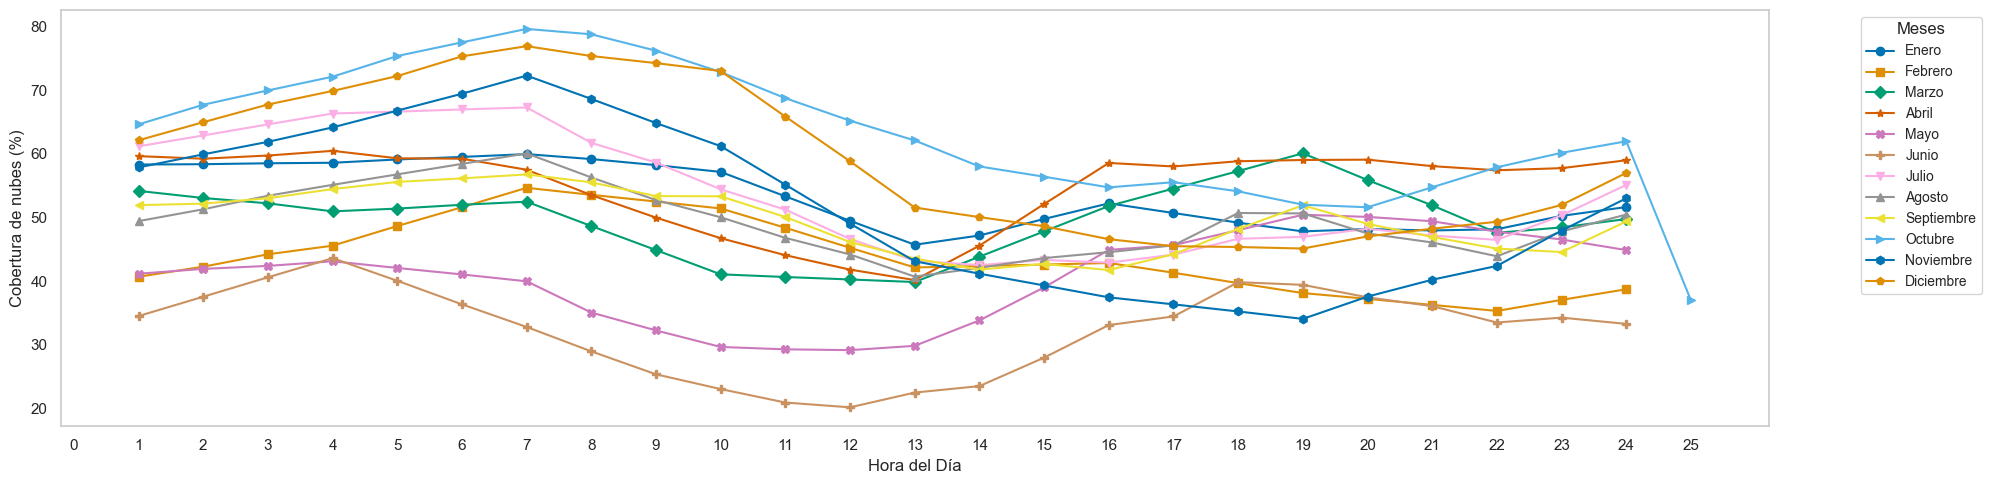

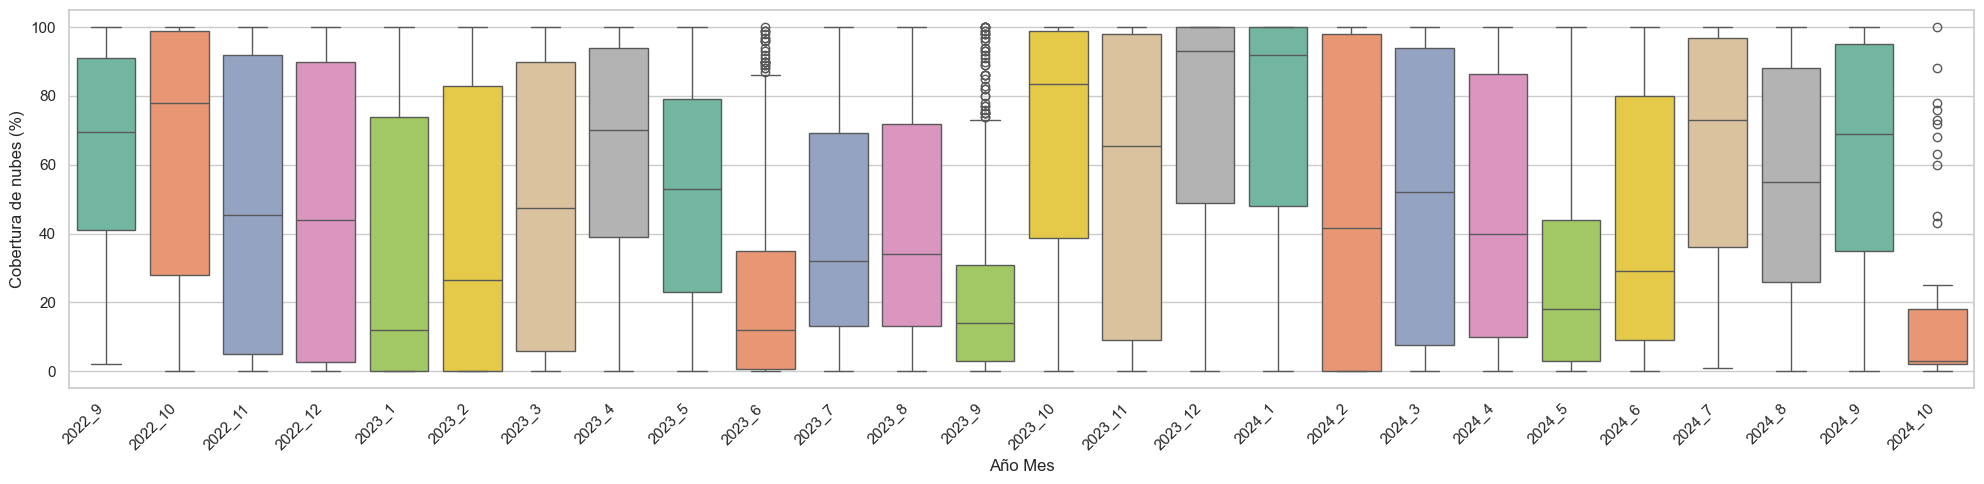

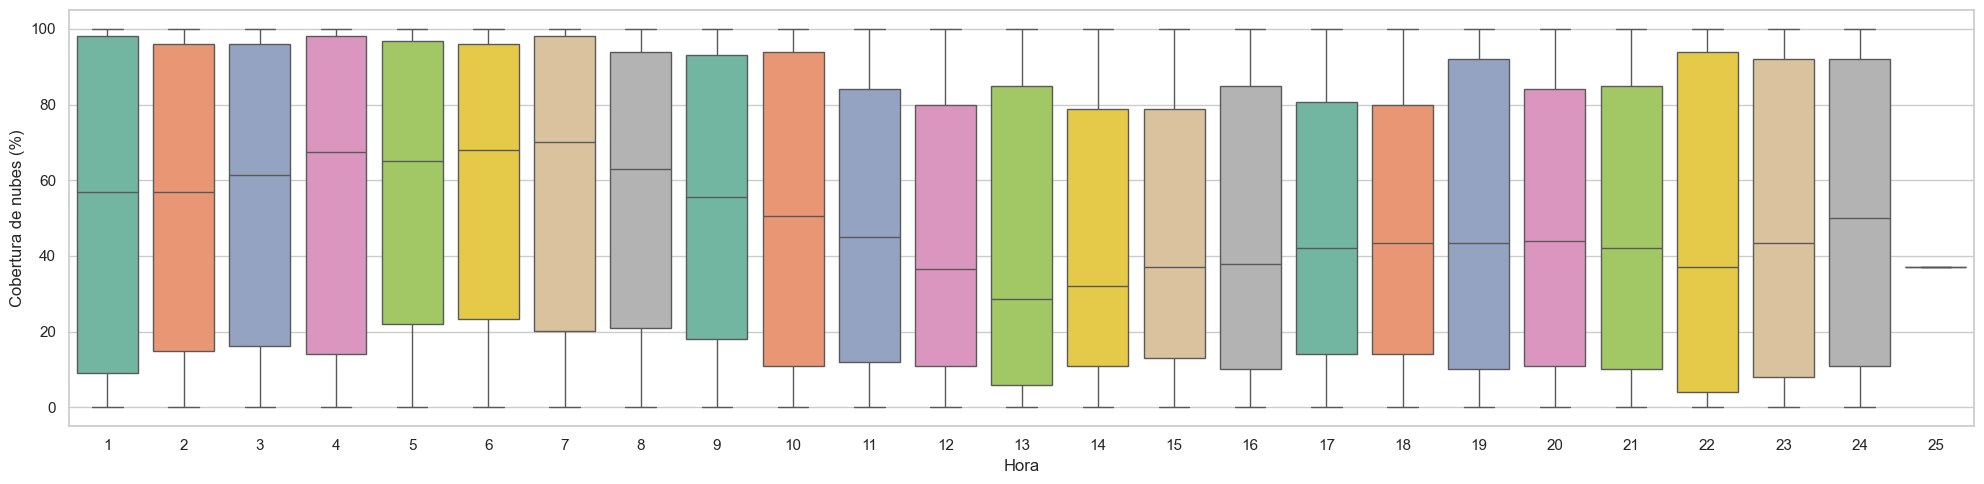

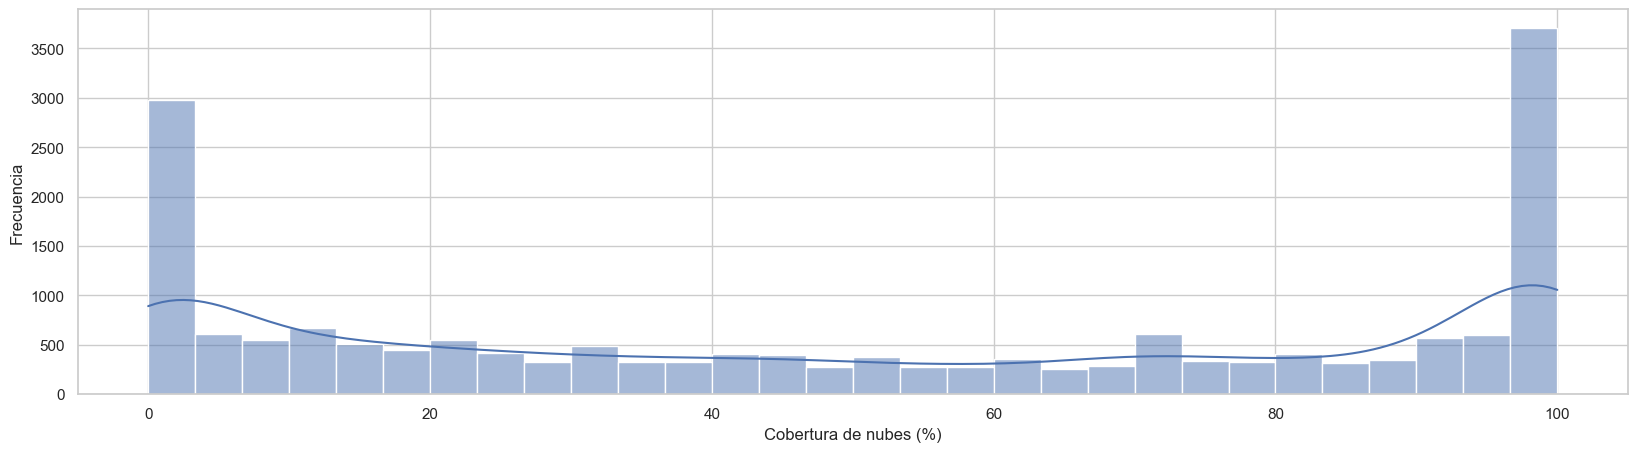

In [ ]:
EDA(13246, 13946, 'fltCoberturaNubes', 'Cobertura de nubes (%)', True)

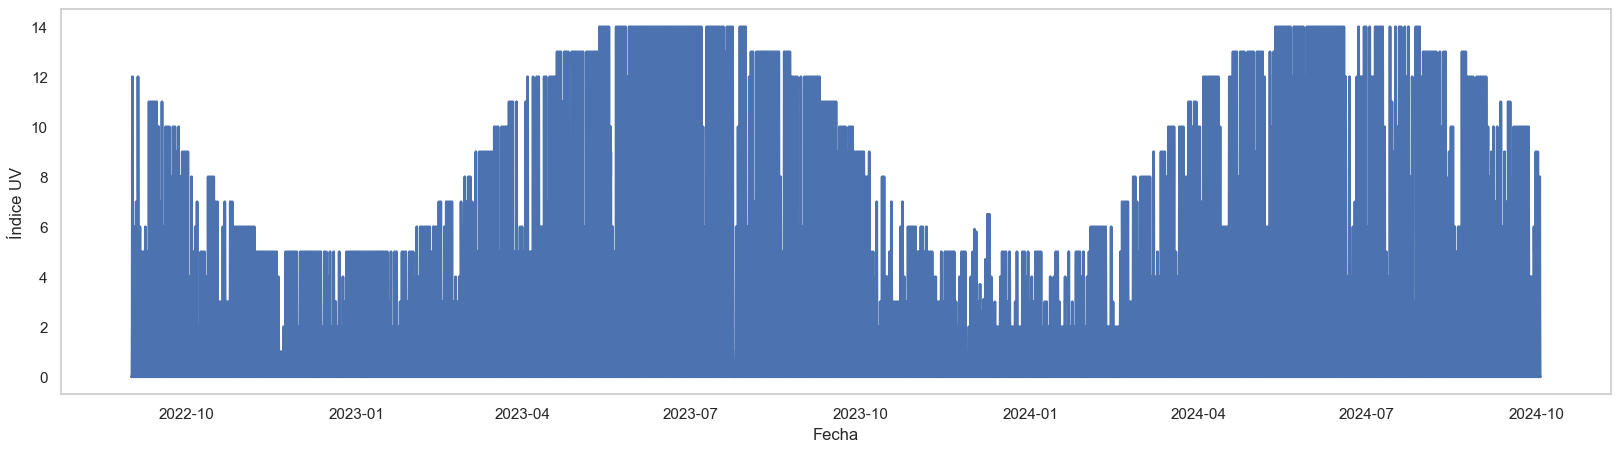

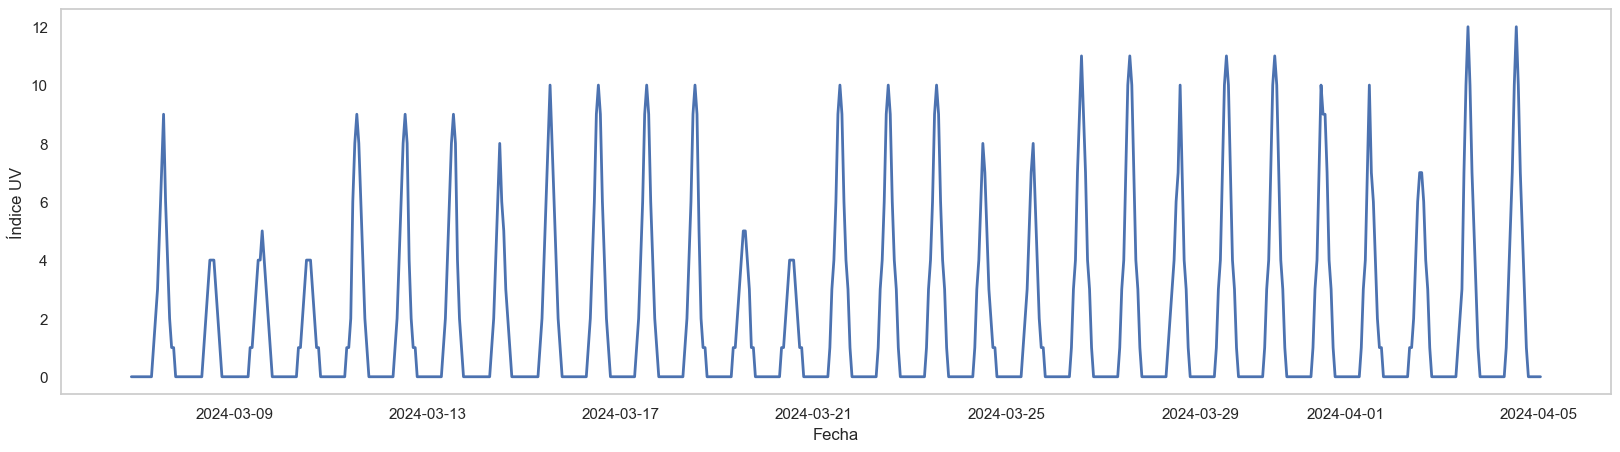

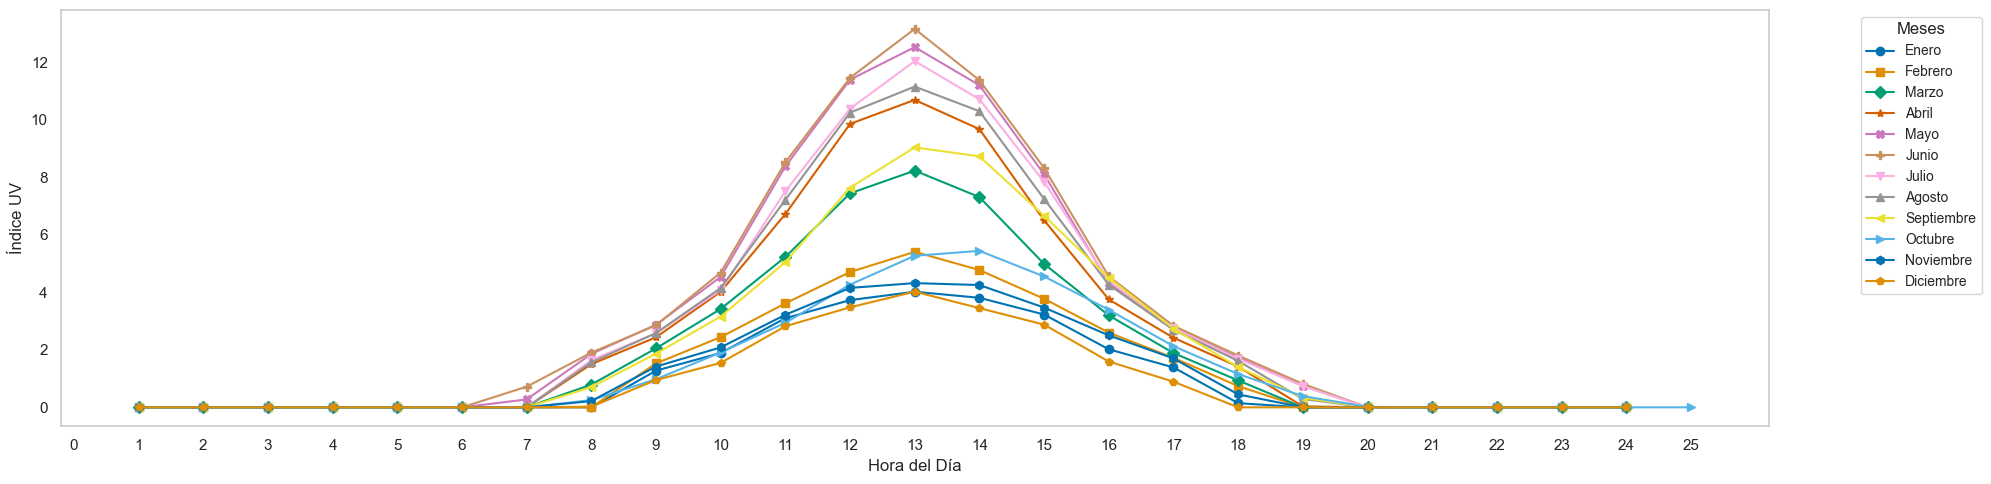

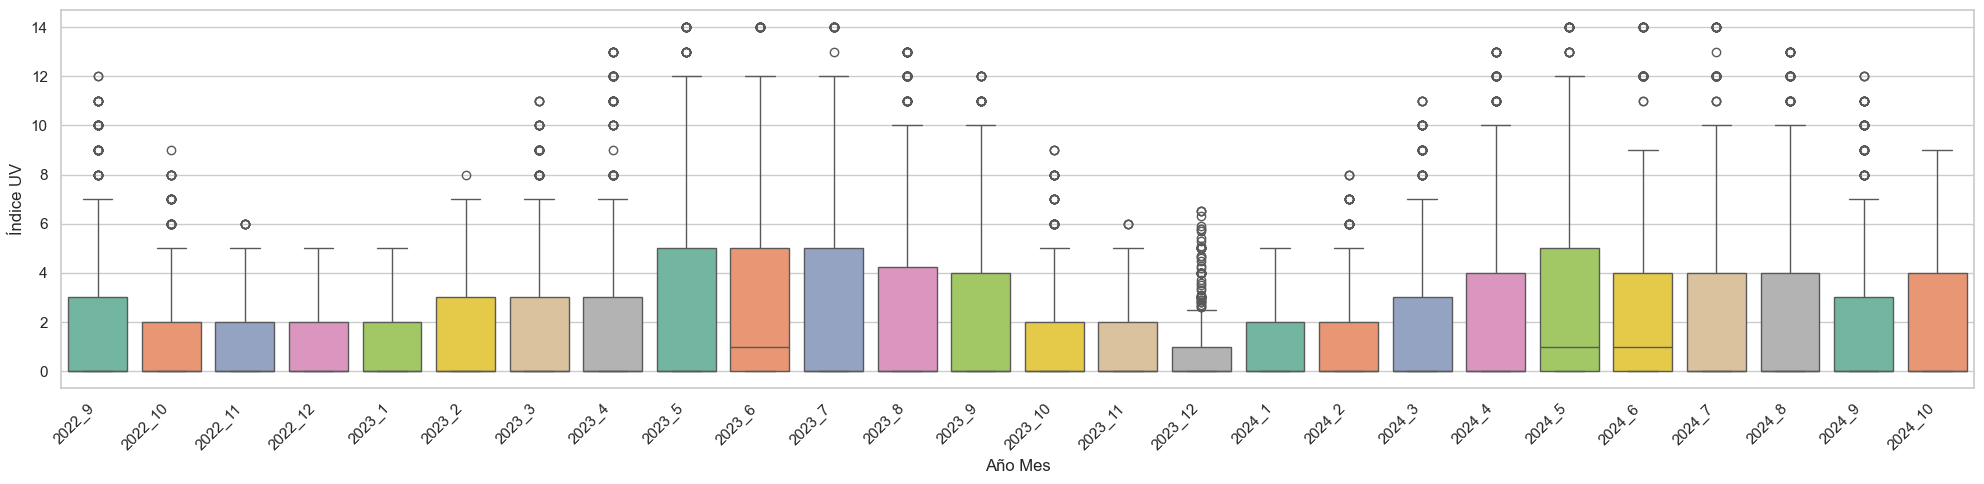

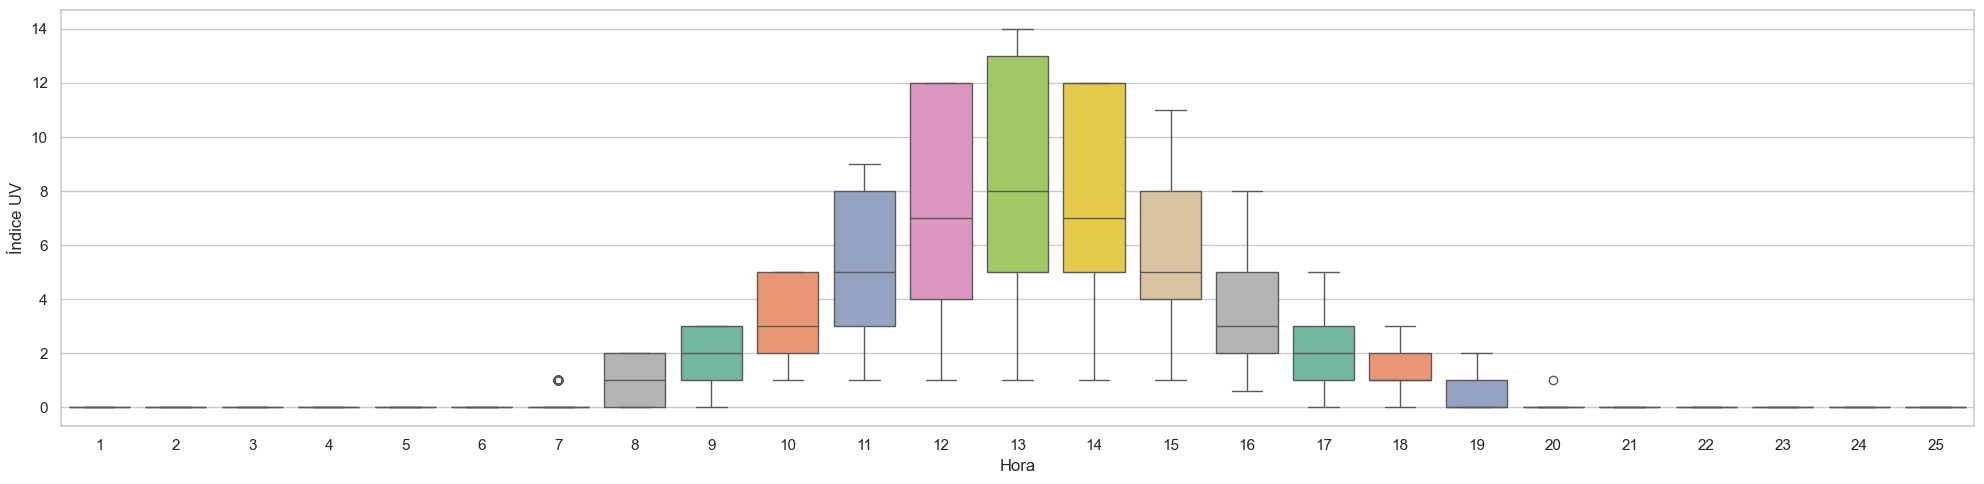

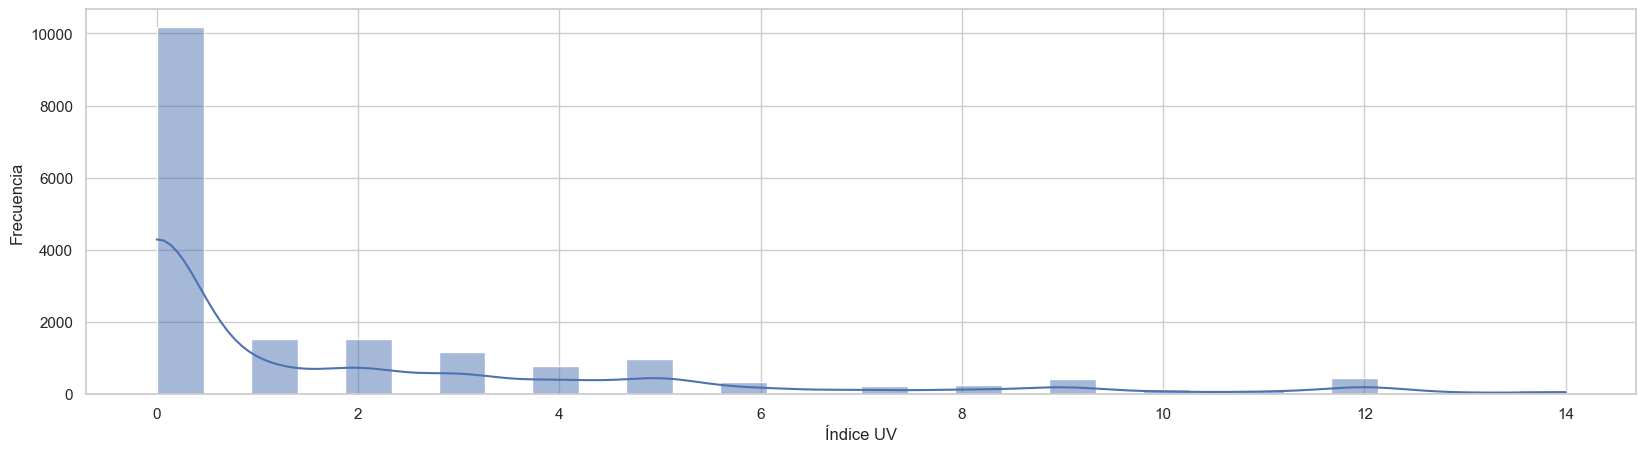

In [ ]:
EDA(13246, 13946, 'fltIndiceUV', 'Índice UV', True)

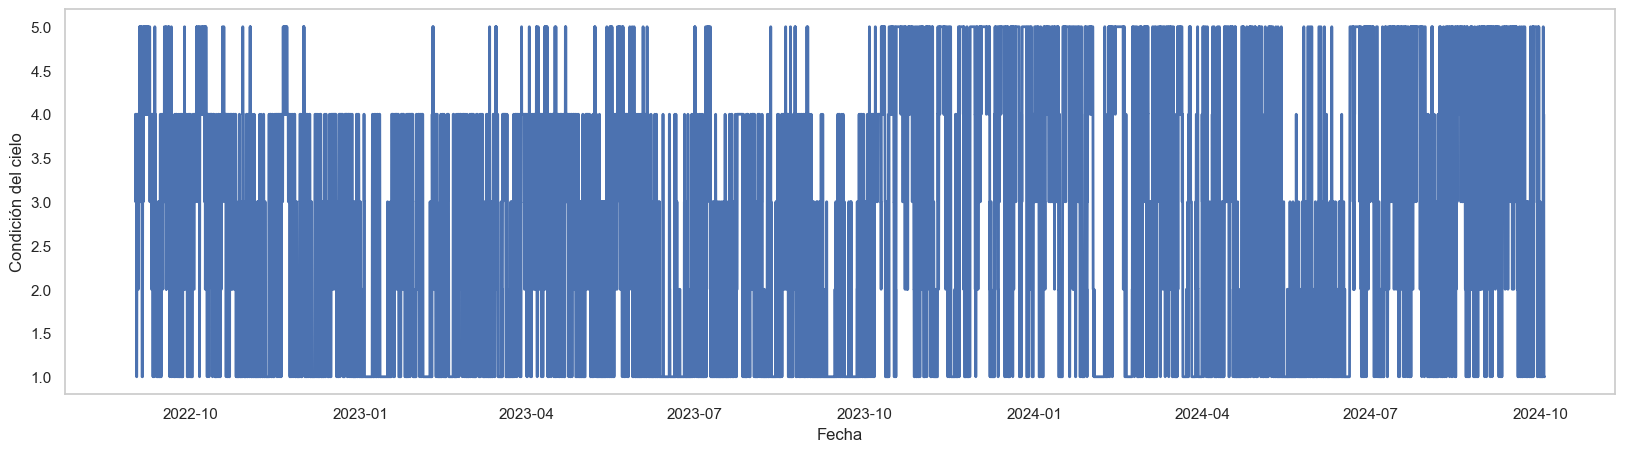

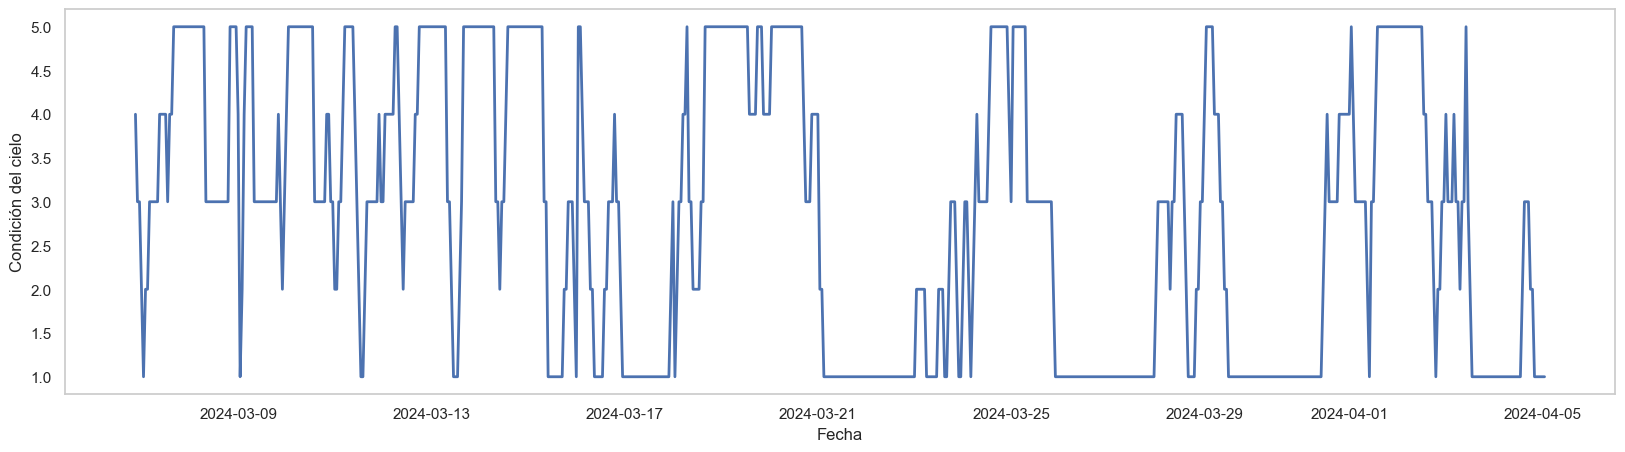

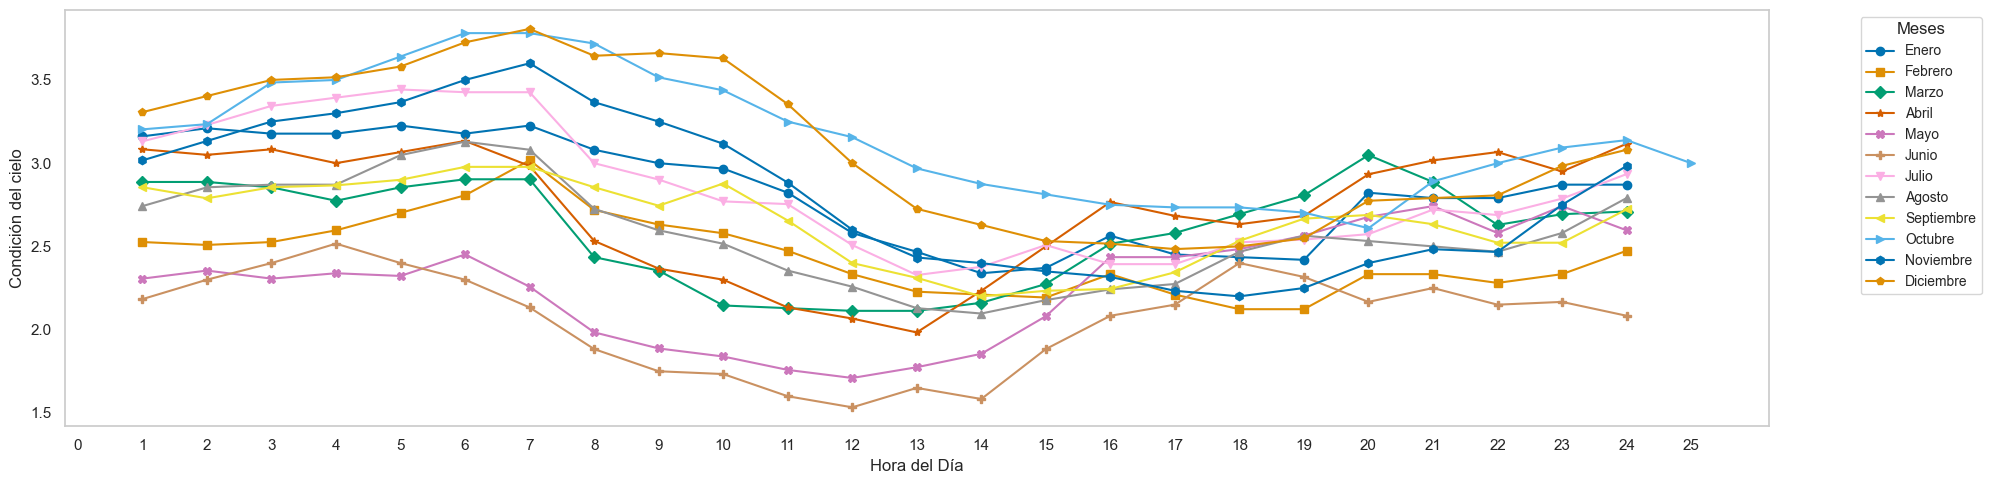

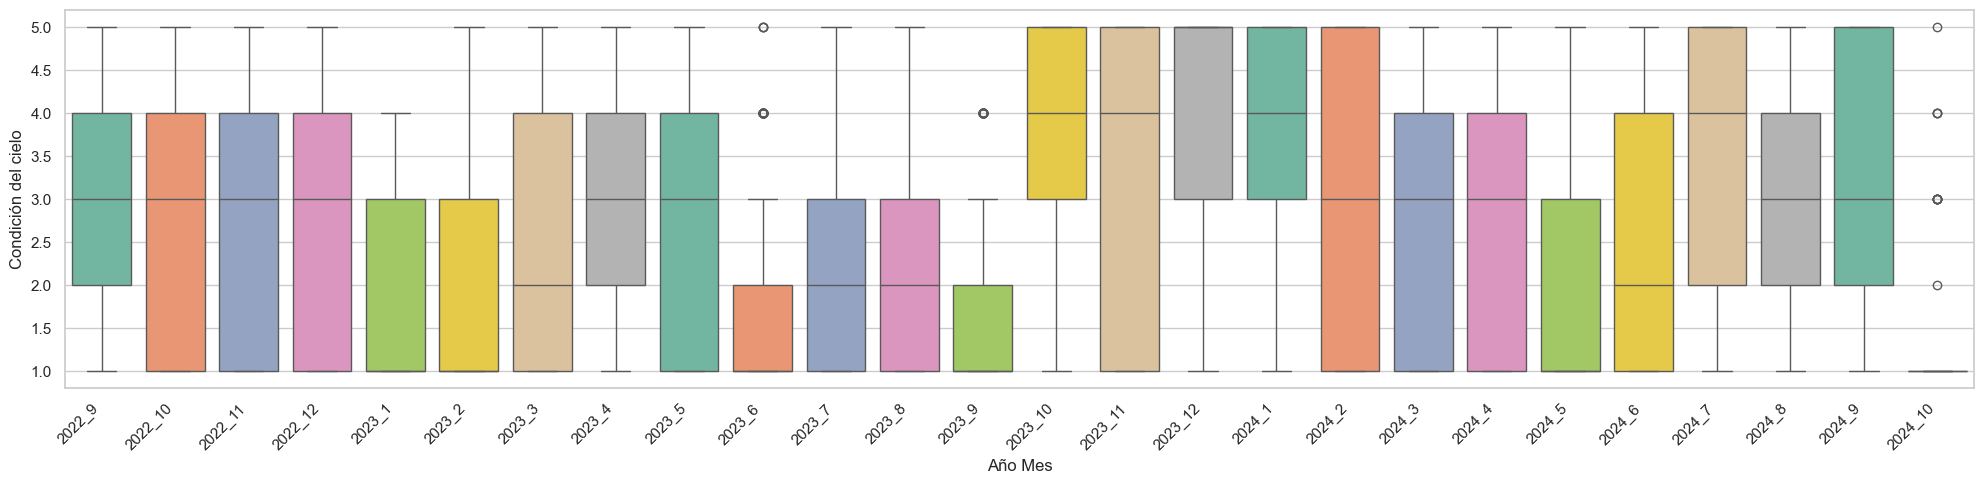

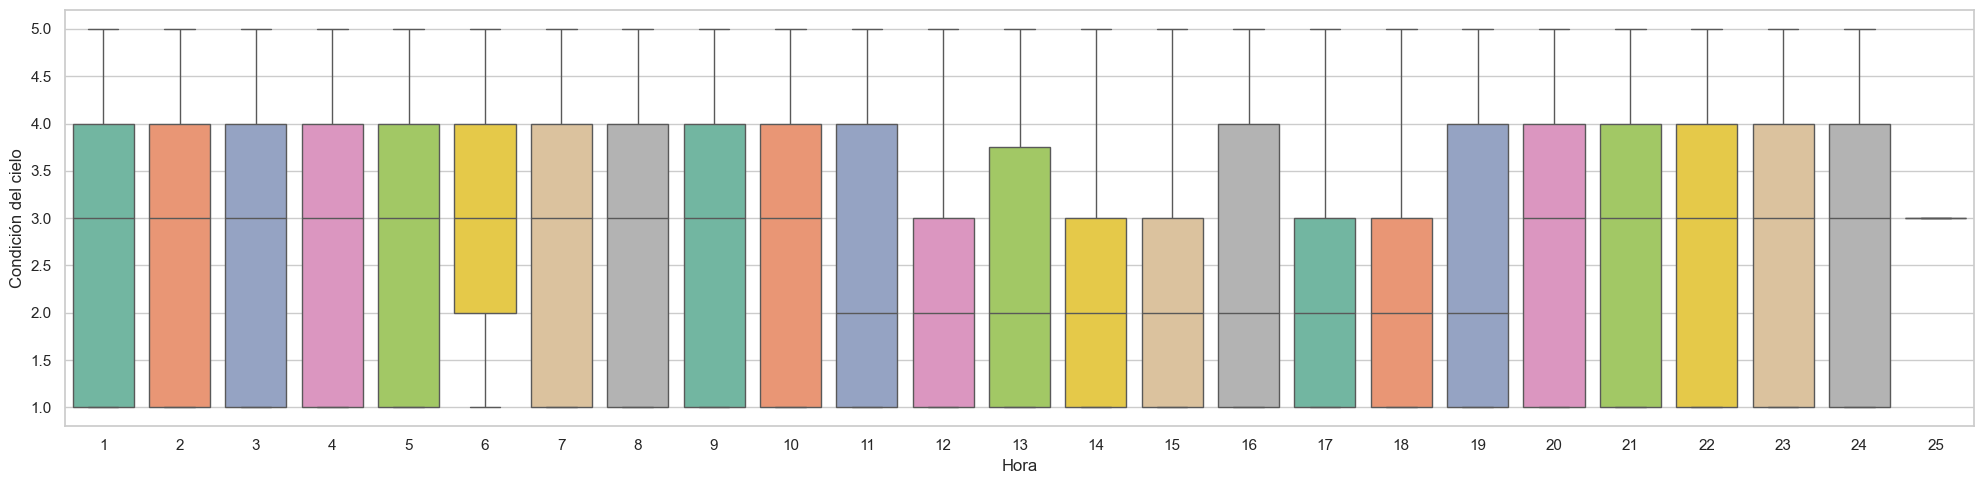

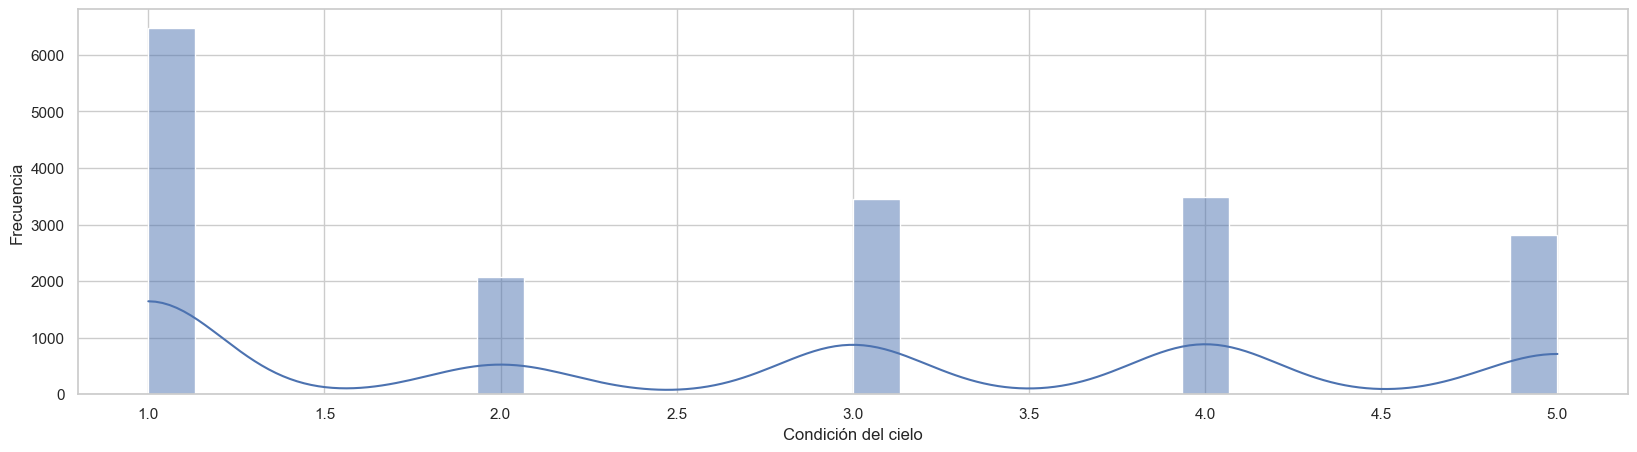

In [ ]:
EDA(13246, 13946, 'iCodCondCielo', 'Condición del cielo', True)

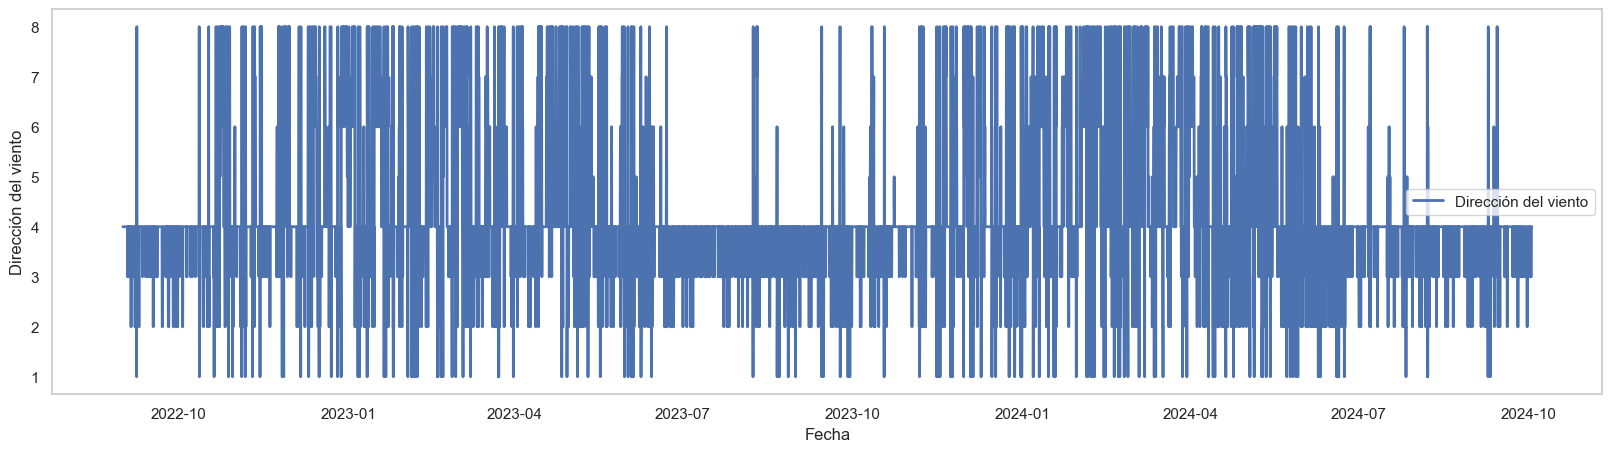

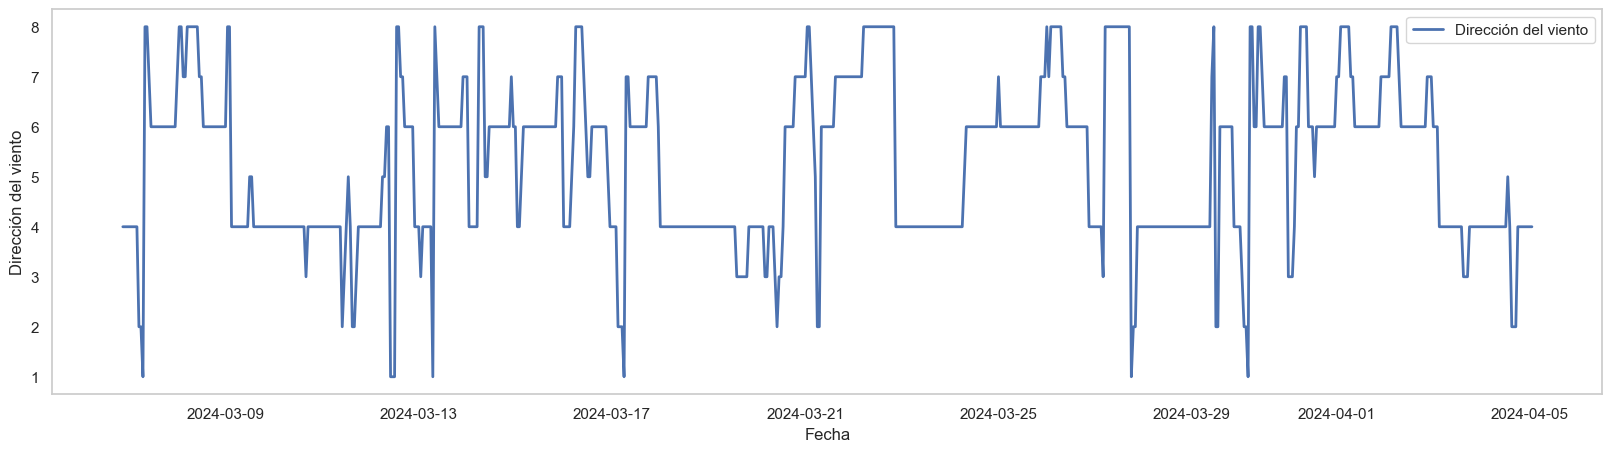

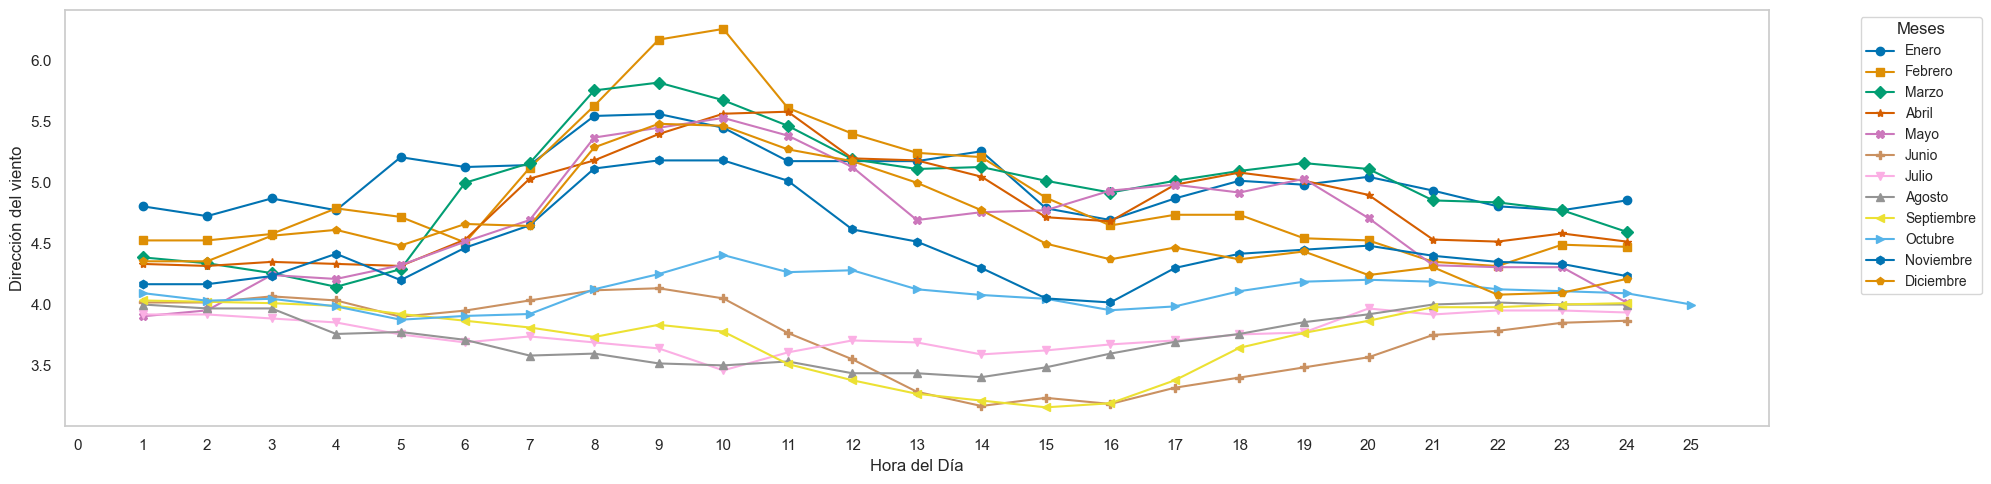

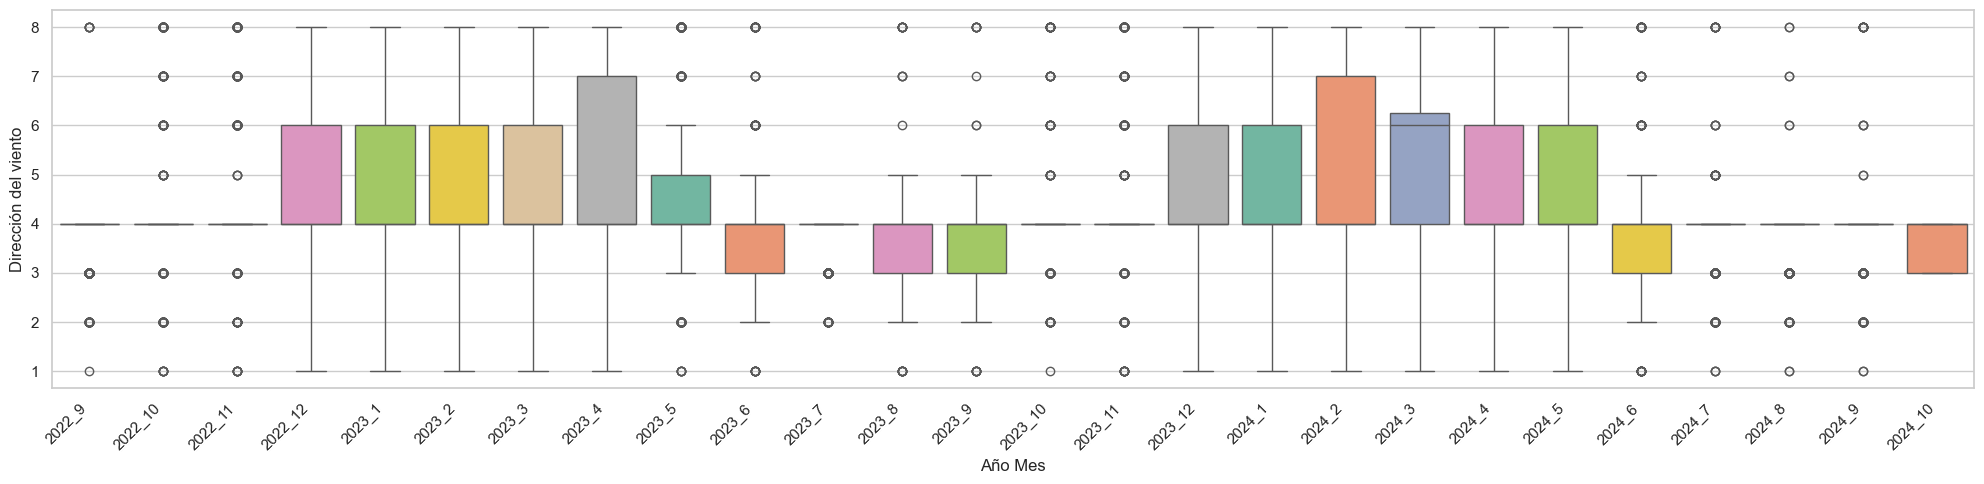

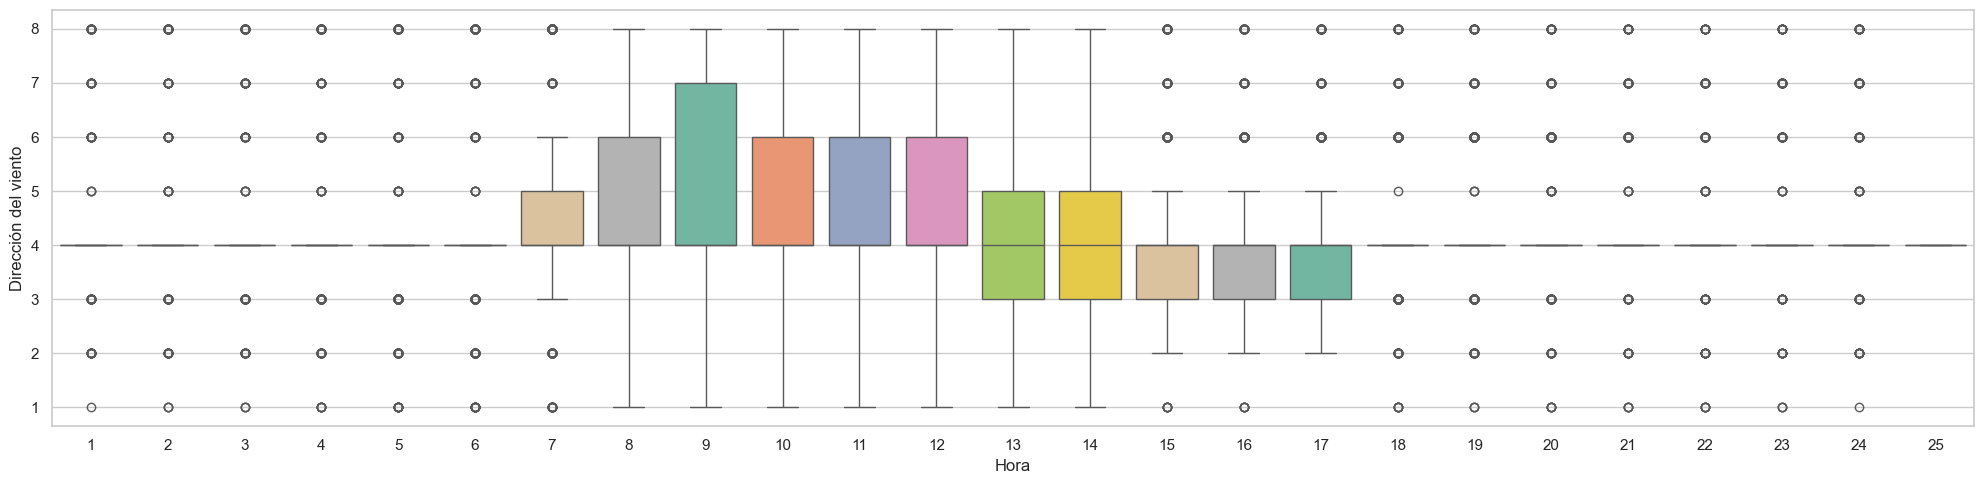

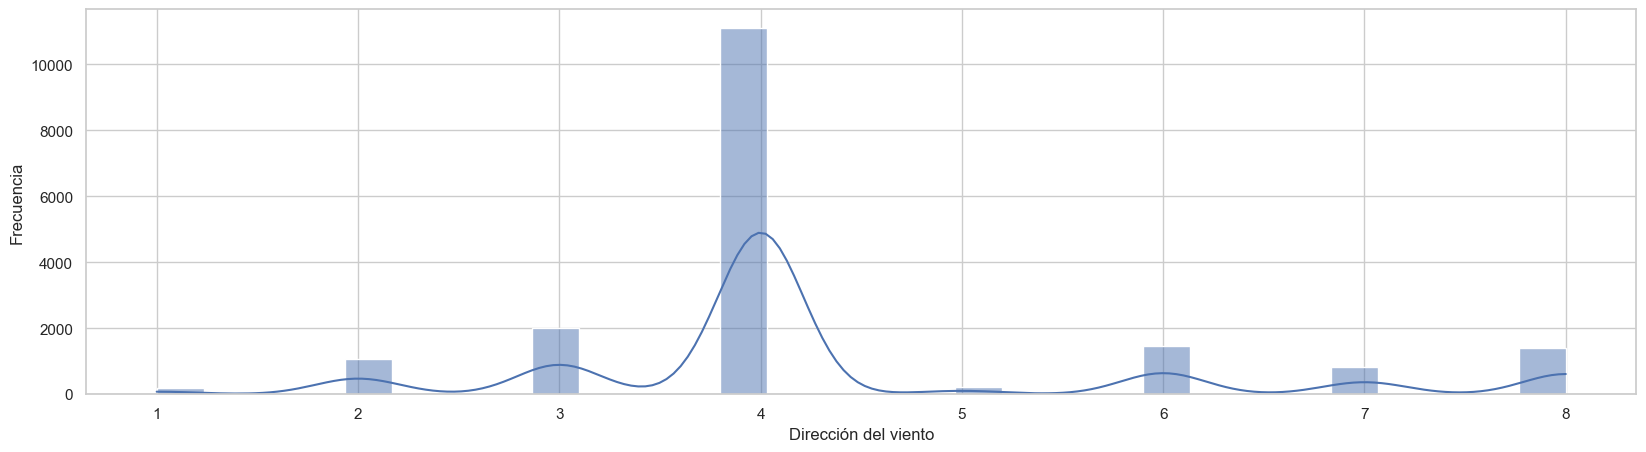

In [ ]:
EDA(13246, 13946, 'iCodDirViento', 'Dirección del viento', True)

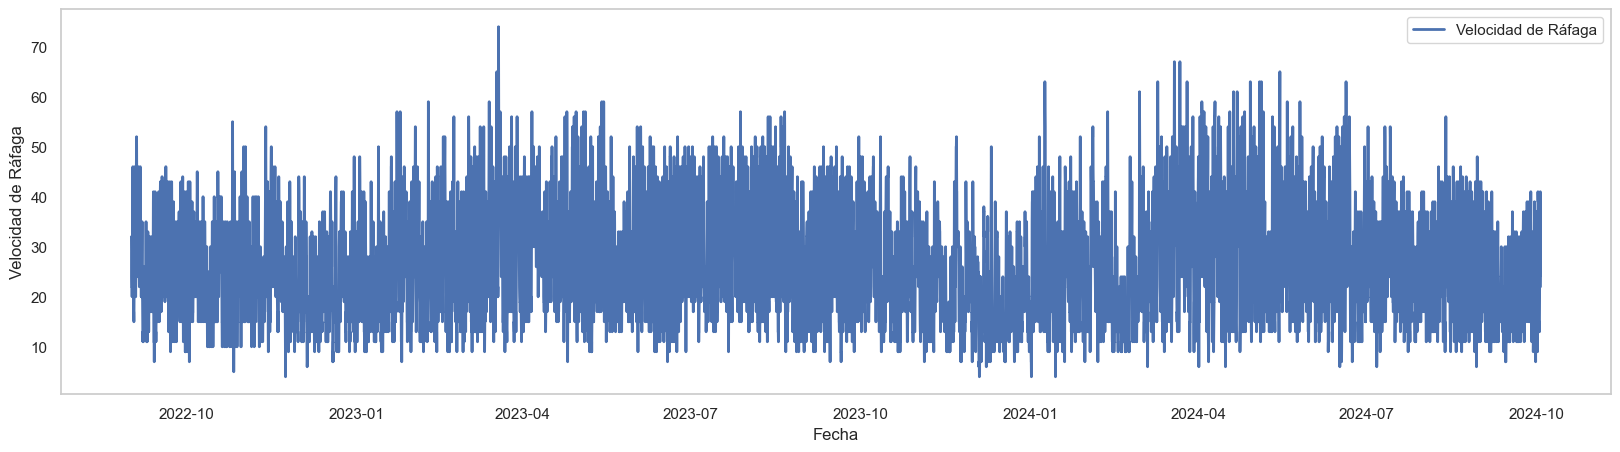

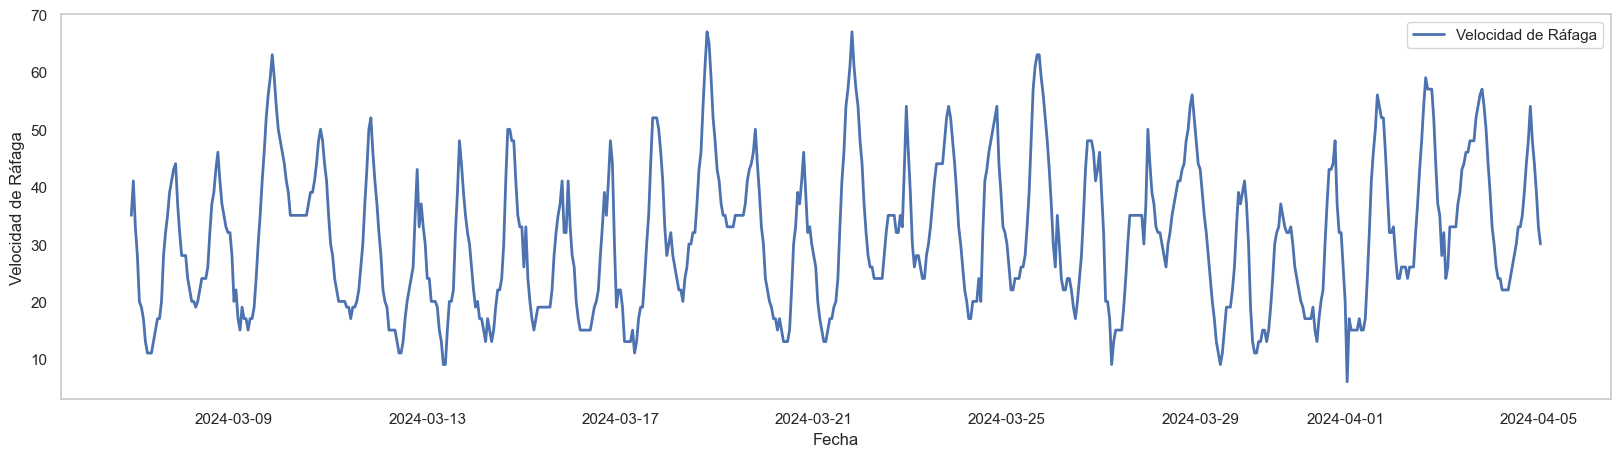

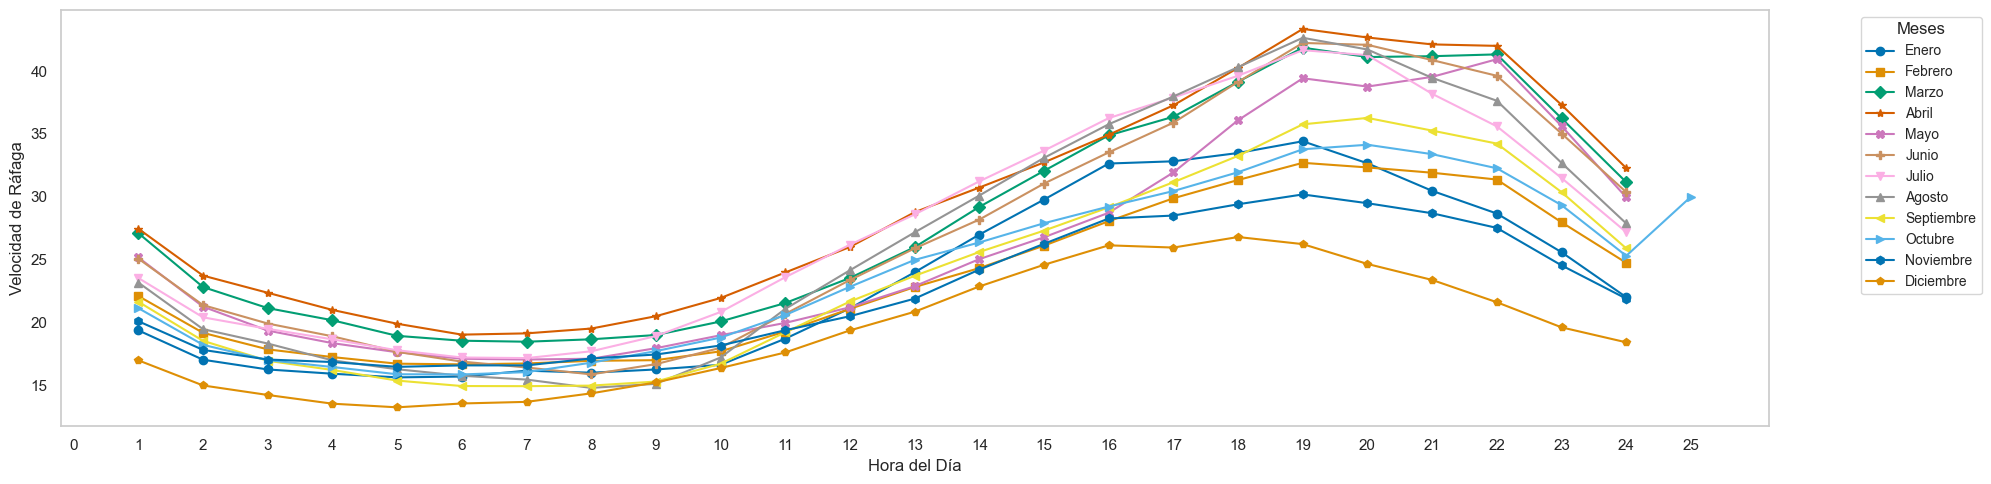

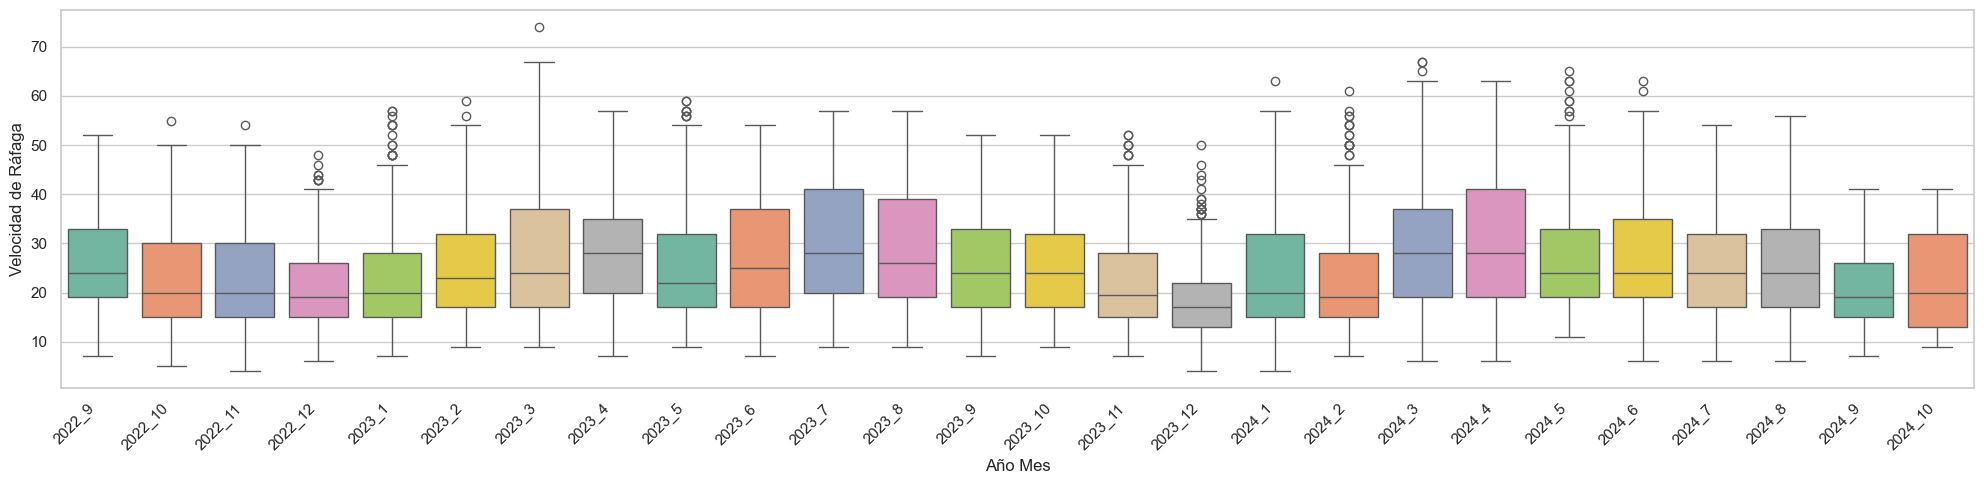

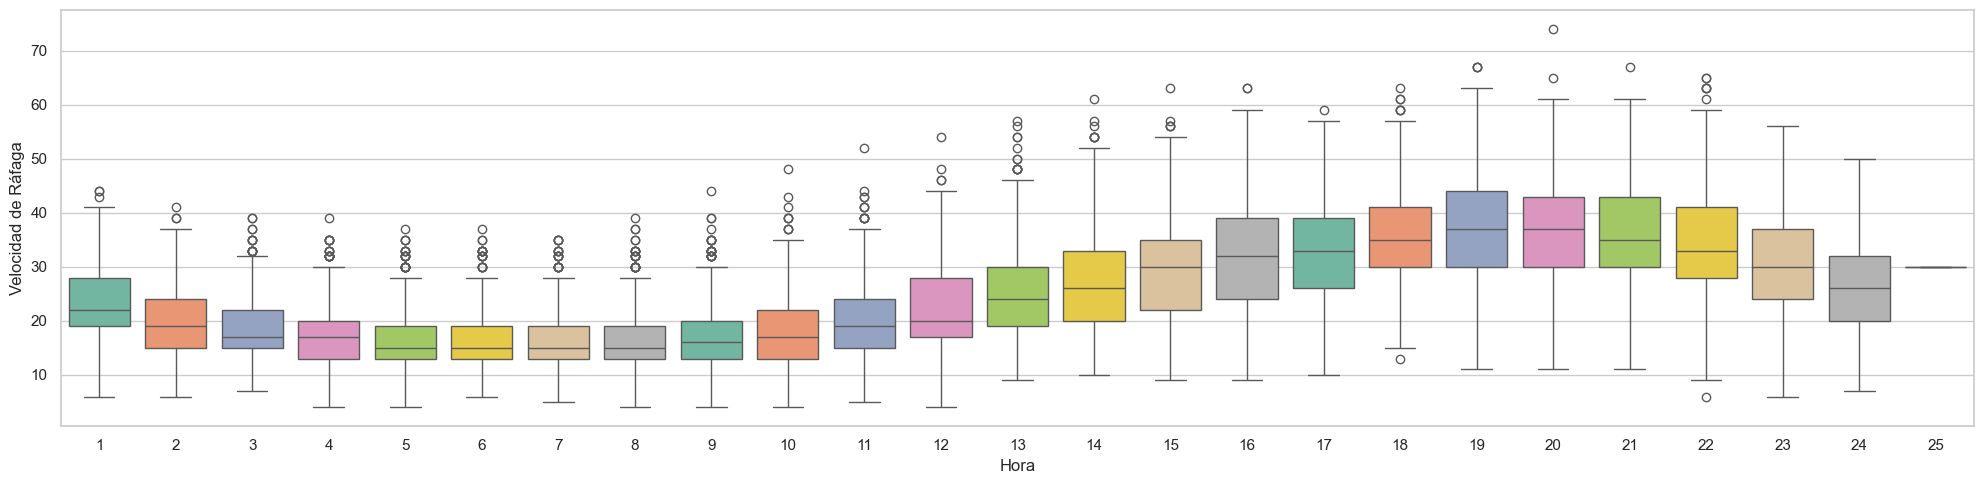

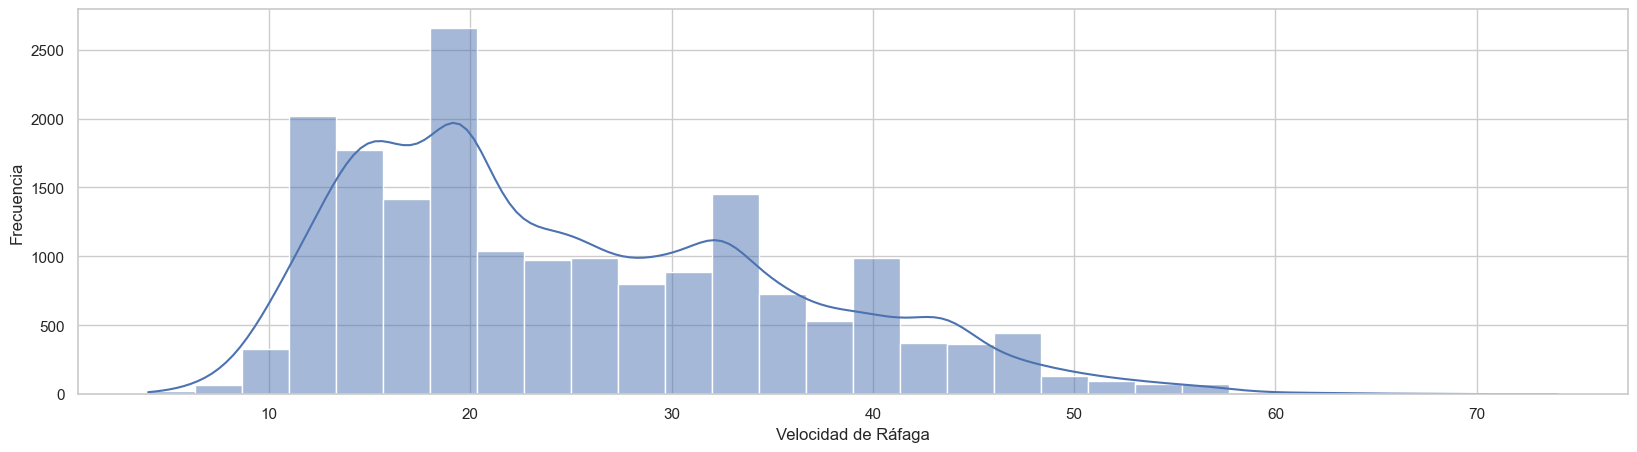

In [ ]:
EDA(13246, 13946, 'fltVelocidadRafaga', 'Velocidad de Ráfaga', True)

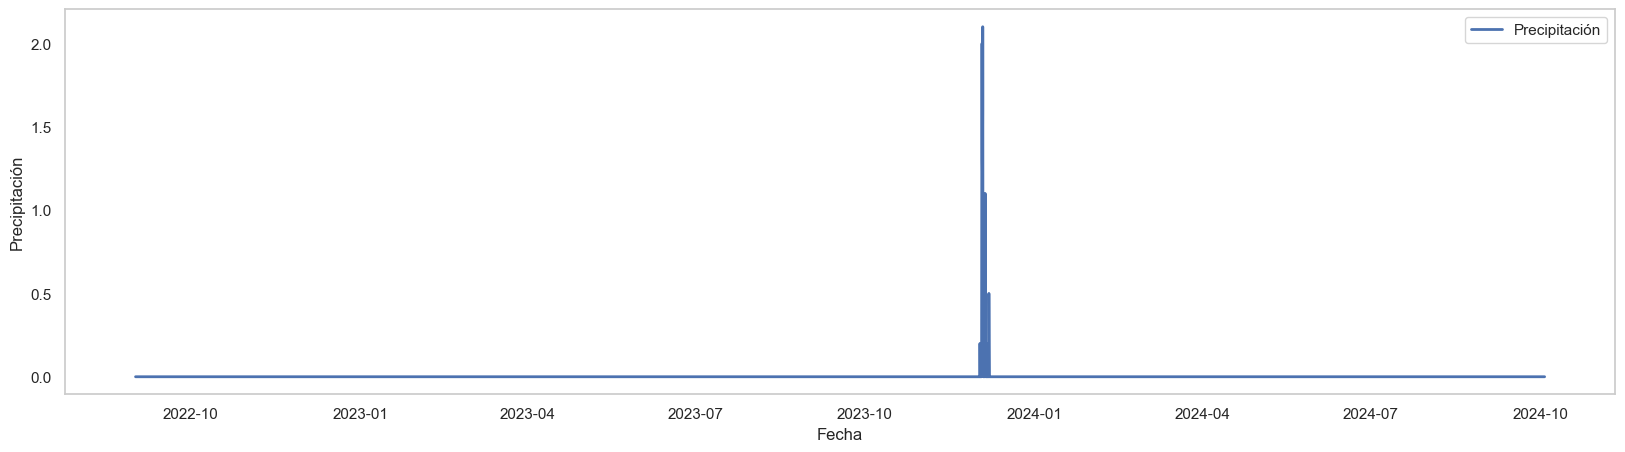

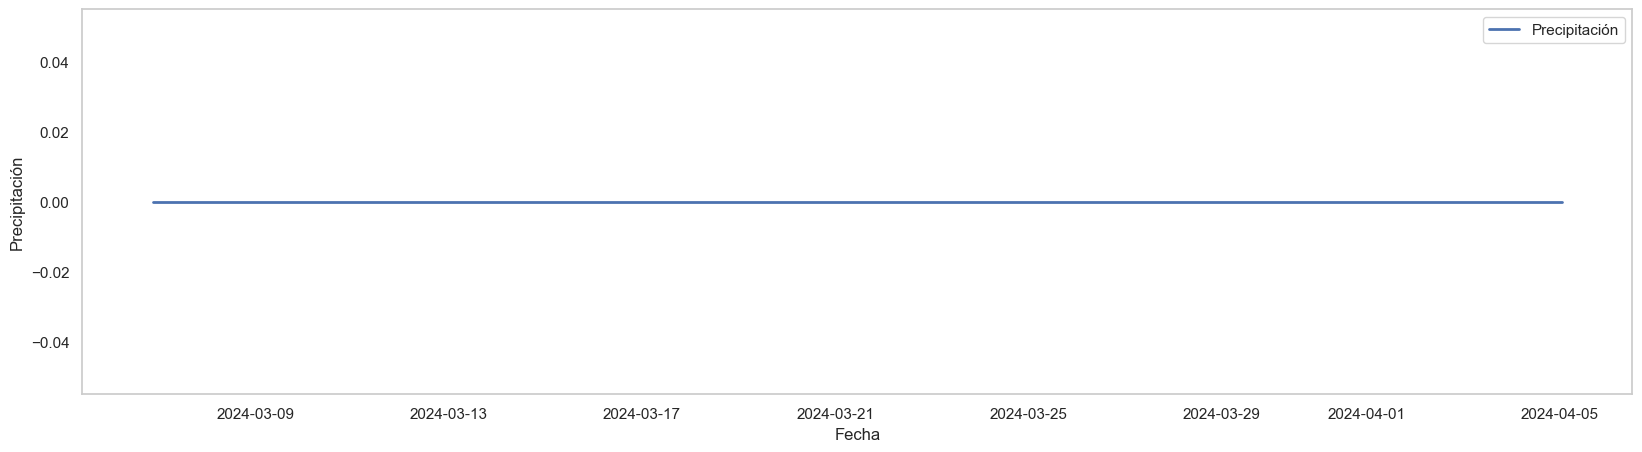

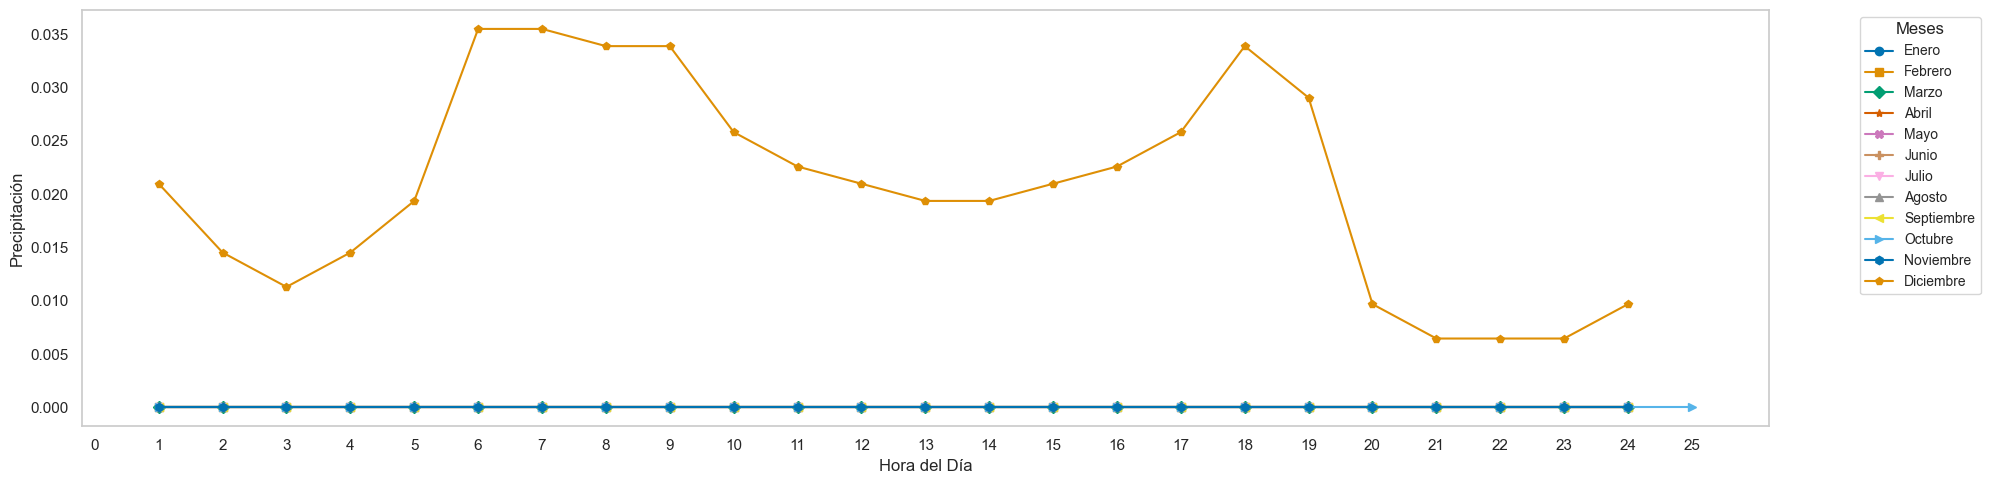

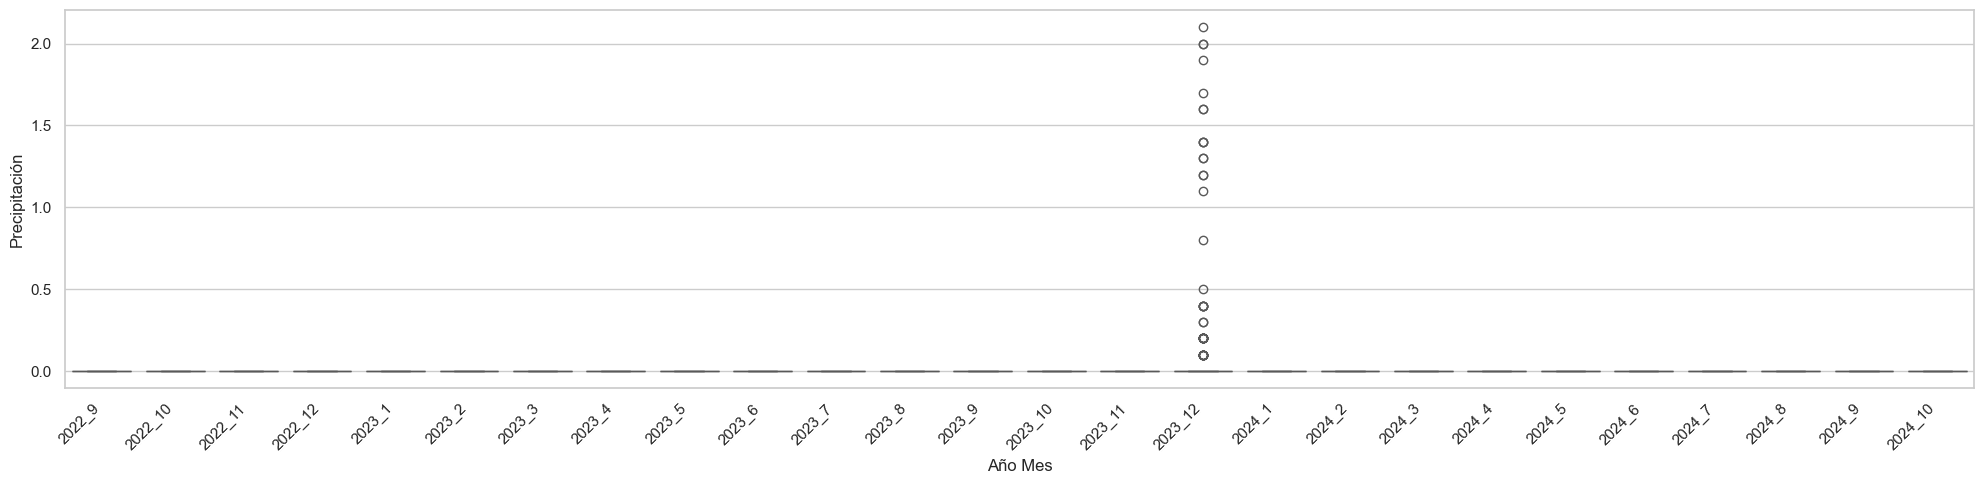

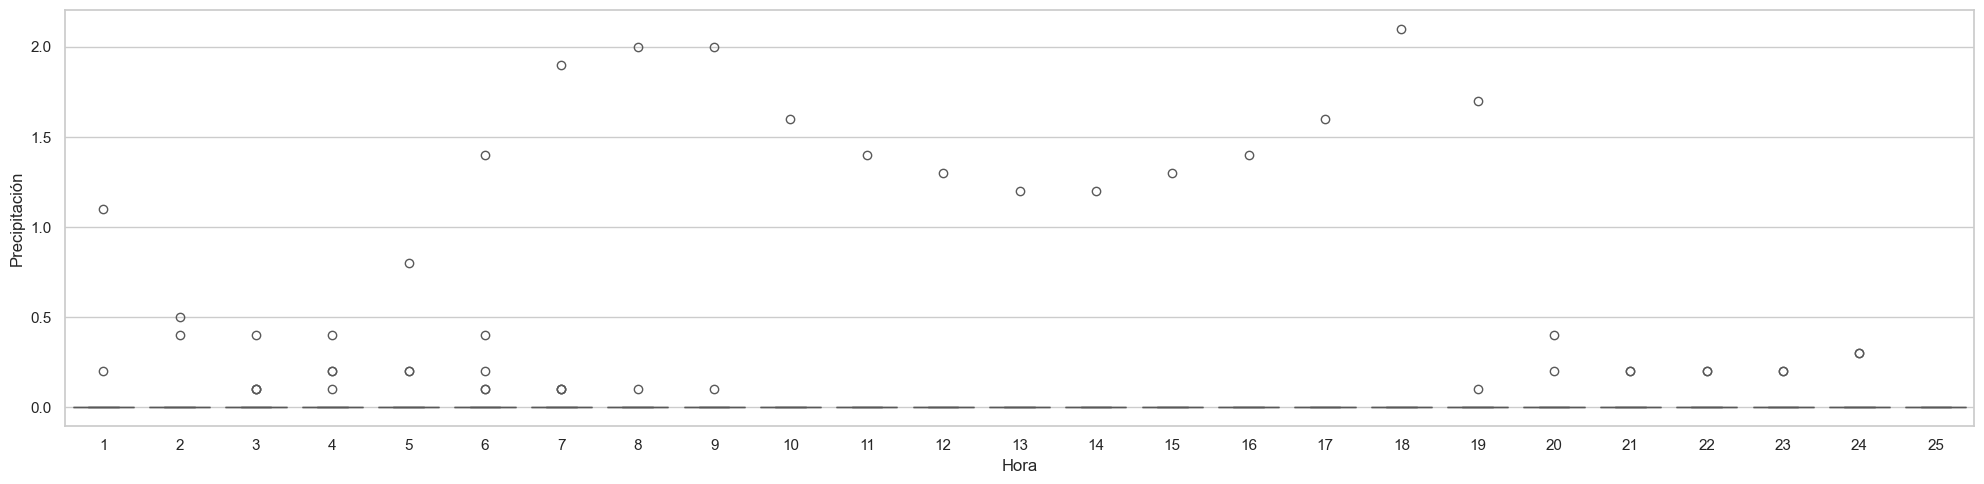

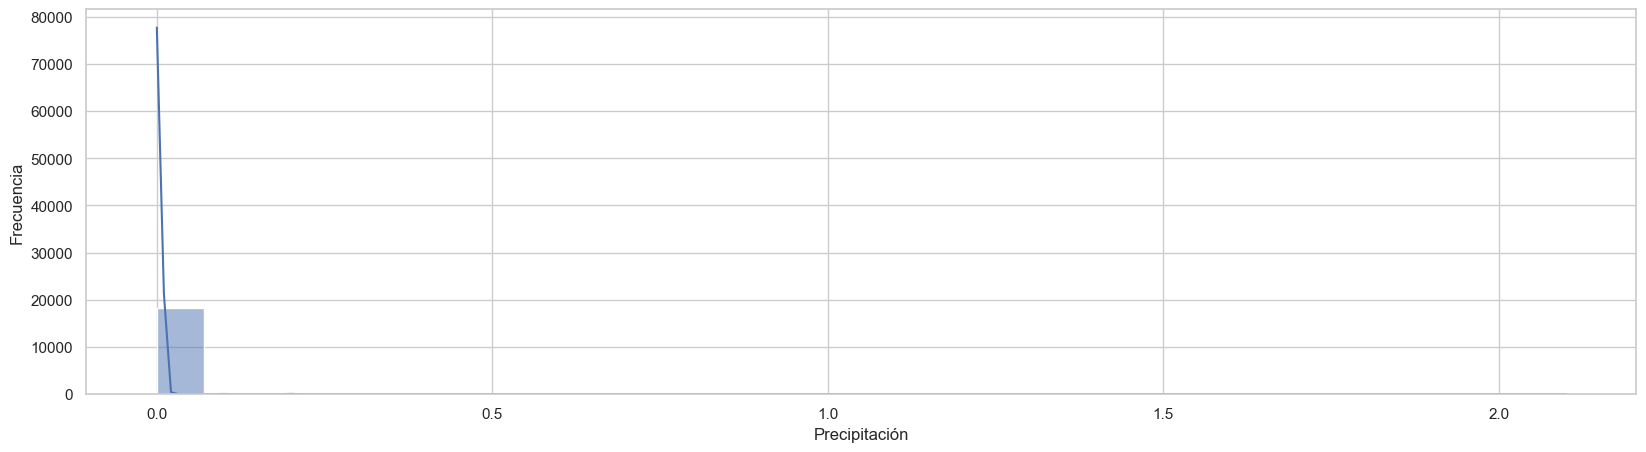

In [ ]:
EDA(13246, 13946, 'fltPrecipitacion', 'Precipitación', True)

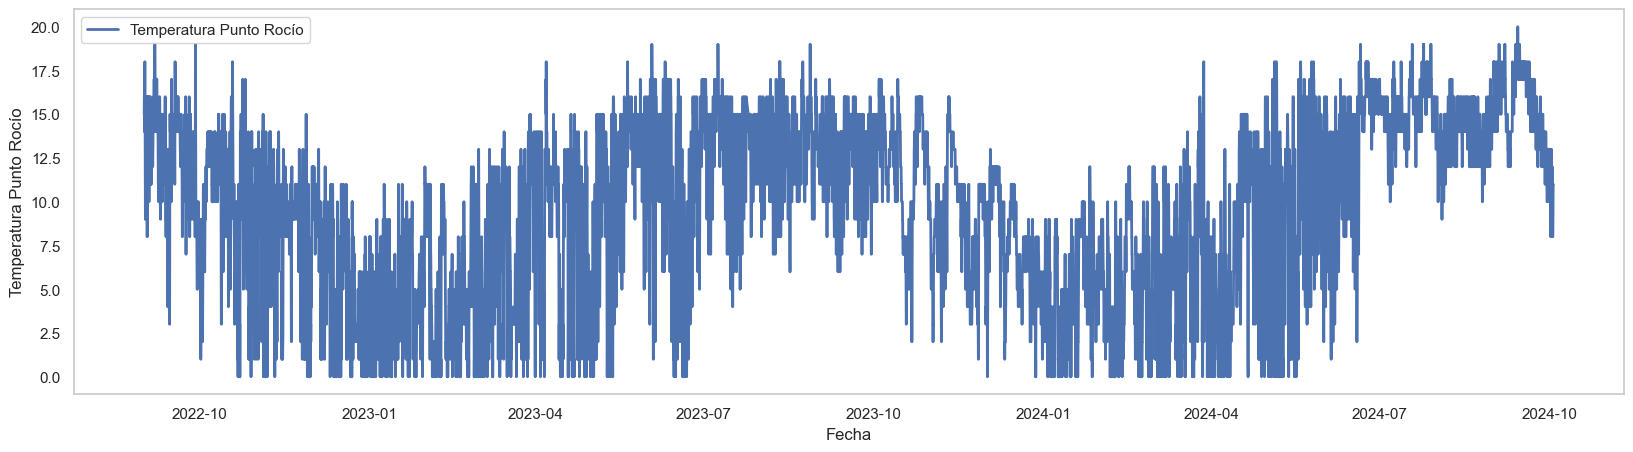

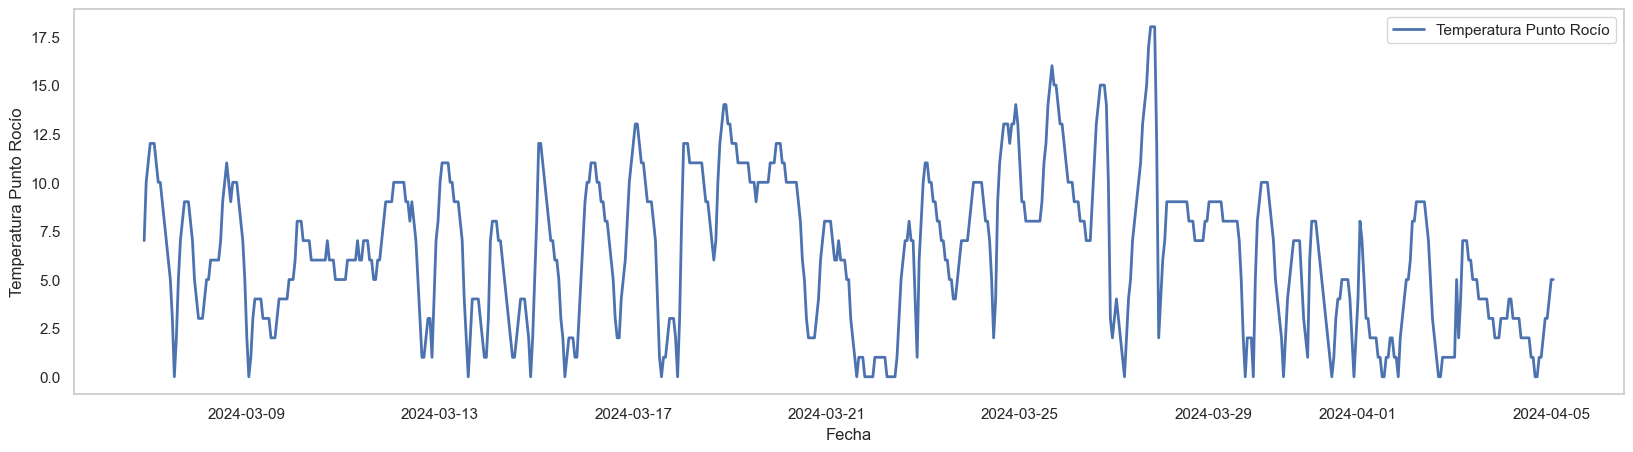

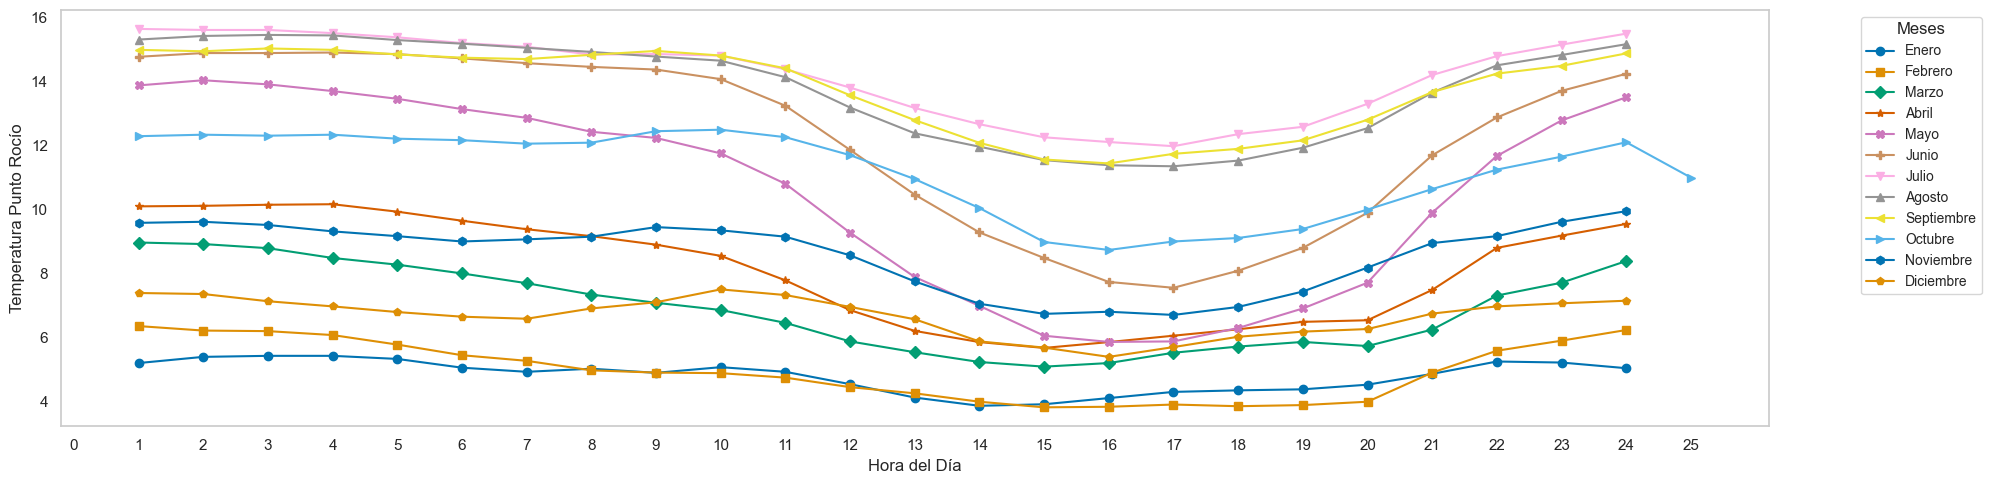

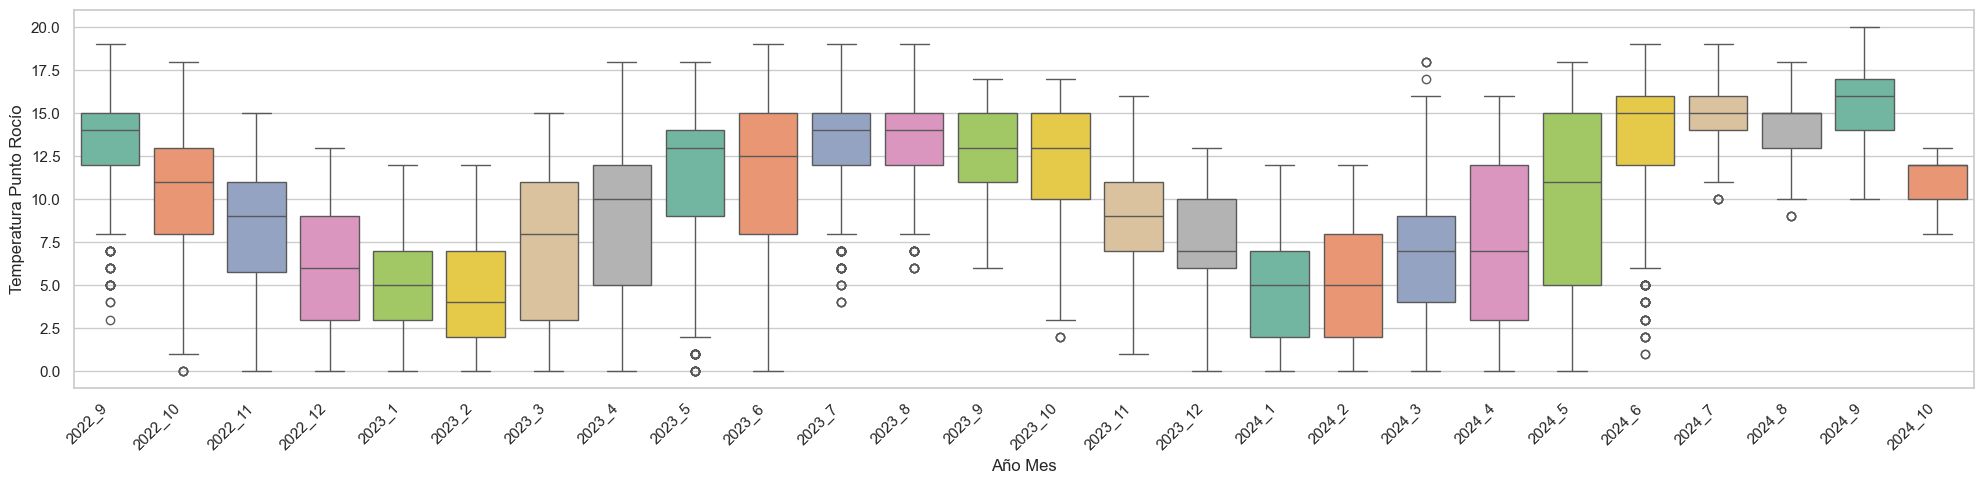

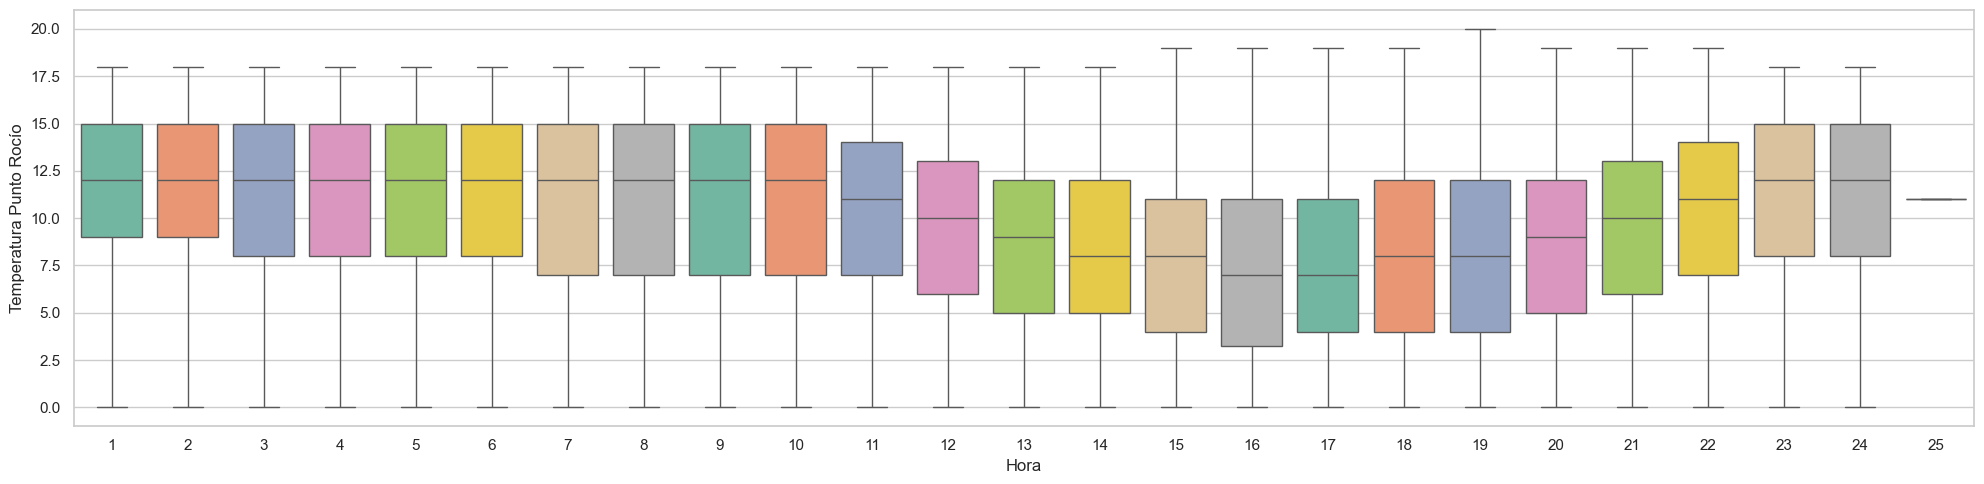

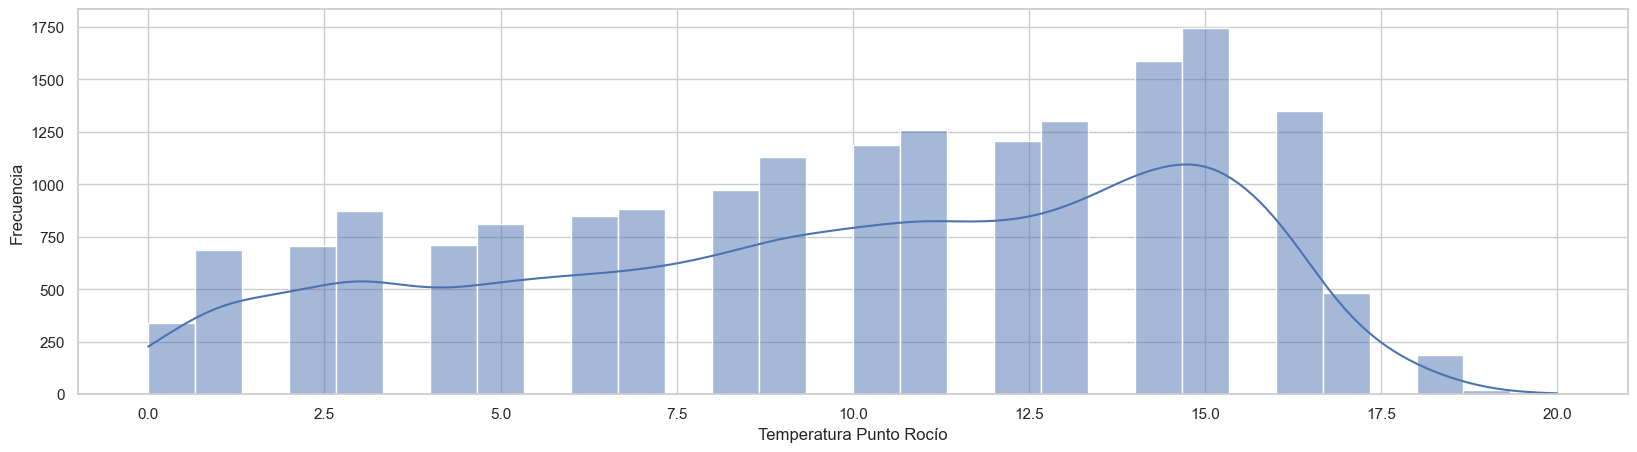

In [ ]:
EDA(13246, 13946, 'fltDPT', 'Temperatura Punto Rocío', True)

In [ ]:
pip install ace_tools

  Using cached ace_tools-0.0-py3-none-any.whl.metadata (300 bytes)
Using cached ace_tools-0.0-py3-none-any.whl (1.1 kB)
Note: you may need to restart the kernel to use updated packages.


In [ ]:
estadisticas = datos.describe().T

estadisticas = estadisticas[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]

# Mostrar resultados en pantalla
estadisticas

,mean,std,min,25%,50%,75%,max
dtHora,2023-09-17 13:18:29.917987840,NaN,2022-09-01 00:00:00,2023-03-10 11:15:00,2023-09-17 23:30:00,2024-03-26 11:45:00,2024-10-03 00:00:00
fltValGeneracion,9392.47041,11398.664257,0.0,0.0,532.0,21829.75,30000.0
iNumDia,15.681137,8.818286,1.0,8.0,16.0,23.0,31.0
iNumAnio,2023.202078,0.69394,2022.0,2023.0,2023.0,2024.0,2024.0
iNumSemana,27.233953,15.038464,1.0,14.0,28.0,40.0,53.0
iNumDiaSemana,4.00246,2.000122,1.0,2.0,4.0,6.0,7.0
iNumMes,6.626353,3.417353,1.0,4.0,7.0,9.0,12.0
iCodDia,6834.03368,220.419345,6452.0,6643.0,6834.0,7025.0,7215.0
iCodHora,164005.230782,5290.192481,154847.0,159419.25,164015.5,168587.75,173160.0
iNumHora,12.501312,6.923137,1.0,7.0,13.0,19.0,25.0


In [ ]:
tabla_latex = estadisticas.to_latex(float_format="%.2f", column_format="lccccccc")
tabla_latex

'\\begin{tabular}{lccccccc}\n\\toprule\n & mean & std & min & 25% & 50% & 75% & max \\\\\n\\midrule\ndtHora & 2023-09-17 13:18:29.917987840 & NaN & 2022-09-01 00:00:00 & 2023-03-10 11:15:00 & 2023-09-17 23:30:00 & 2024-03-26 11:45:00 & 2024-10-03 00:00:00 \\\\\nfltValGeneracion & 9392.47 & 11398.66 & 0.00 & 0.00 & 532.00 & 21829.75 & 30000.00 \\\\\niNumDia & 15.68 & 8.82 & 1.00 & 8.00 & 16.00 & 23.00 & 31.00 \\\\\niNumAnio & 2023.20 & 0.69 & 2022.00 & 2023.00 & 2023.00 & 2024.00 & 2024.00 \\\\\niNumSemana & 27.23 & 15.04 & 1.00 & 14.00 & 28.00 & 40.00 & 53.00 \\\\\niNumDiaSemana & 4.00 & 2.00 & 1.00 & 2.00 & 4.00 & 6.00 & 7.00 \\\\\niNumMes & 6.63 & 3.42 & 1.00 & 4.00 & 7.00 & 9.00 & 12.00 \\\\\niCodDia & 6834.03 & 220.42 & 6452.00 & 6643.00 & 6834.00 & 7025.00 & 7215.00 \\\\\niCodHora & 164005.23 & 5290.19 & 154847.00 & 159419.25 & 164015.50 & 168587.75 & 173160.00 \\\\\niNumHora & 12.50 & 6.92 & 1.00 & 7.00 & 13.00 & 19.00 & 25.00 \\\\\nfltTemp & 19.46 & 6.64 & 0.00 & 15.00 & 19.00 &

Precipitación está en su totalidad en ceros, por lo que no nos sirve la variable, la eliminamos de los 3 archivos.

In [ ]:
datos = datos.drop(columns="fltPrecipitacion")

AttributeError: 'numpy.ndarray' object has no attribute 'set_ylabel'

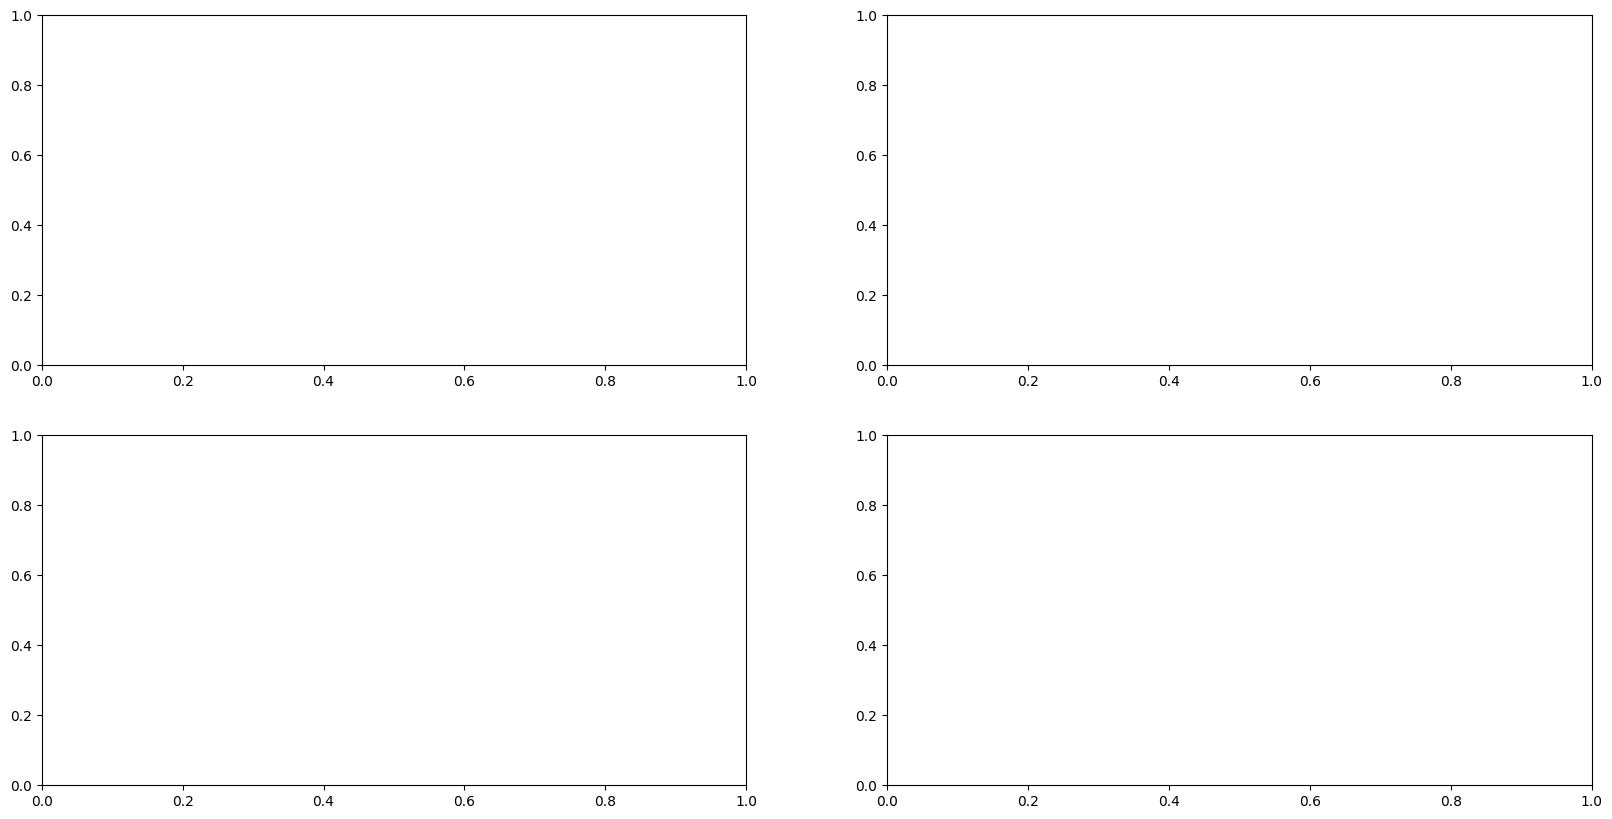

In [ ]:
df = pd.DataFrame(datos)
# Filtrar un mes específico (Ejemplo: marzo 2024)
df_mes = df[(df['dtHora'] >= '2024-08-01') & (df['dtHora'] < '2024-09-01')]

# Crear la figura y los ejes
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 10))

# --- PRIMER GRÁFICO (Datos completos) ---
ax1 = axes[0]
ax1.set_ylabel('Generación (kWh)', color='tab:blue')
ax1.plot(df['dtHora'], df['fltValGeneracion'], color='tab:blue', label='Generación (kWh)')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Segundo eje para temperatura
ax2 = ax1.twinx()
ax2.set_ylabel('Temperatura (°C)', color='tab:red')
ax2.plot(df['dtHora'], df['fltTemp'], color='tab:red', linestyle='dashed', label='Temperatura (°C)')
ax2.tick_params(axis='y', labelcolor='tab:red')

ax1.set_title('Generación de Energía y Temperatura - Datos Completos')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# --- SEGUNDO GRÁFICO (Solo un mes) ---
ax3 = axes[1]
ax3.set_ylabel('Generación (kWh)', color='tab:blue')
ax3.plot(df_mes['dtHora'], df_mes['fltValGeneracion'], color='tab:blue', label='Generación (kWh)')
ax3.tick_params(axis='y', labelcolor='tab:blue')

# Segundo eje para temperatura
ax4 = ax3.twinx()
ax4.set_ylabel('Temperatura (°C)', color='tab:red')
ax4.plot(df_mes['dtHora'], df_mes['fltTemp'], color='tab:red', linestyle='dashed', label='Temperatura (°C)')
ax4.tick_params(axis='y', labelcolor='tab:red')

ax3.set_title('Generación de Energía y Temperatura - Agosto 2024')
ax3.legend(loc='upper left')
ax4.legend(loc='upper right')

# --- PRIMER GRÁFICO (Datos completos) ---
ax5 = axes[3]
ax5.set_ylabel('Generación (kWh)', color='tab:blue')
ax5.plot(df['dtHora'], df['fltValGeneracion'], color='tab:blue', label='Generación (kWh)')
ax5.tick_params(axis='y', labelcolor='tab:blue')

# Segundo eje para temperatura
ax6 = ax5.twinx()
ax6.set_ylabel('Temperatura (°C)', color='tab:red')
ax6.plot(df['dtHora'], df['fltTemp'], color='tab:red', linestyle='dashed', label='Temperatura (°C)')
ax6.tick_params(axis='y', labelcolor='tab:red')

ax6.set_title('Generación de Energía y Temperatura - Datos Completos')
ax6.legend(loc='upper left')
ax2.legend(loc='upper right')

# --- SEGUNDO GRÁFICO (Solo un mes) ---
ax3 = axes[1]
ax3.set_ylabel('Generación (kWh)', color='tab:blue')
ax3.plot(df_mes['dtHora'], df_mes['fltValGeneracion'], color='tab:blue', label='Generación (kWh)')
ax3.tick_params(axis='y', labelcolor='tab:blue')

# Segundo eje para temperatura
ax4 = ax3.twinx()
ax4.set_ylabel('Temperatura (°C)', color='tab:red')
ax4.plot(df_mes['dtHora'], df_mes['fltTemp'], color='tab:red', linestyle='dashed', label='Temperatura (°C)')
ax4.tick_params(axis='y', labelcolor='tab:red')

ax3.set_title('Generación de Energía y Temperatura - Agosto 2024')
ax3.legend(loc='upper left')
ax4.legend(loc='upper right')

# Rotar etiquetas del eje X solo en el último gráfico
plt.xticks(rotation=45)

# Ajustar espacio entre gráficos
plt.tight_layout()

# Mostrar gráfico
plt.show()

In [15]:
datos.columns

Index(['dtHora', 'fltValGeneracion', 'iNumDia', 'iNumAnio', 'iNumSemana',
       'iNumDiaSemana', 'iNumMes', 'iCodDia', 'iCodHora', 'iNumHora',
       'fltTemp', 'fltProbabilidadLluvia', 'fltHumedadRelativa',
       'fltVelocidadViento', 'fltCoberturaNubes', 'fltIndiceUV',
       'iCodCondCielo', 'iCodDirViento', 'fltVelocidadRafaga',
       'fltPrecipitacion', 'fltDPT'],
      dtype='object')

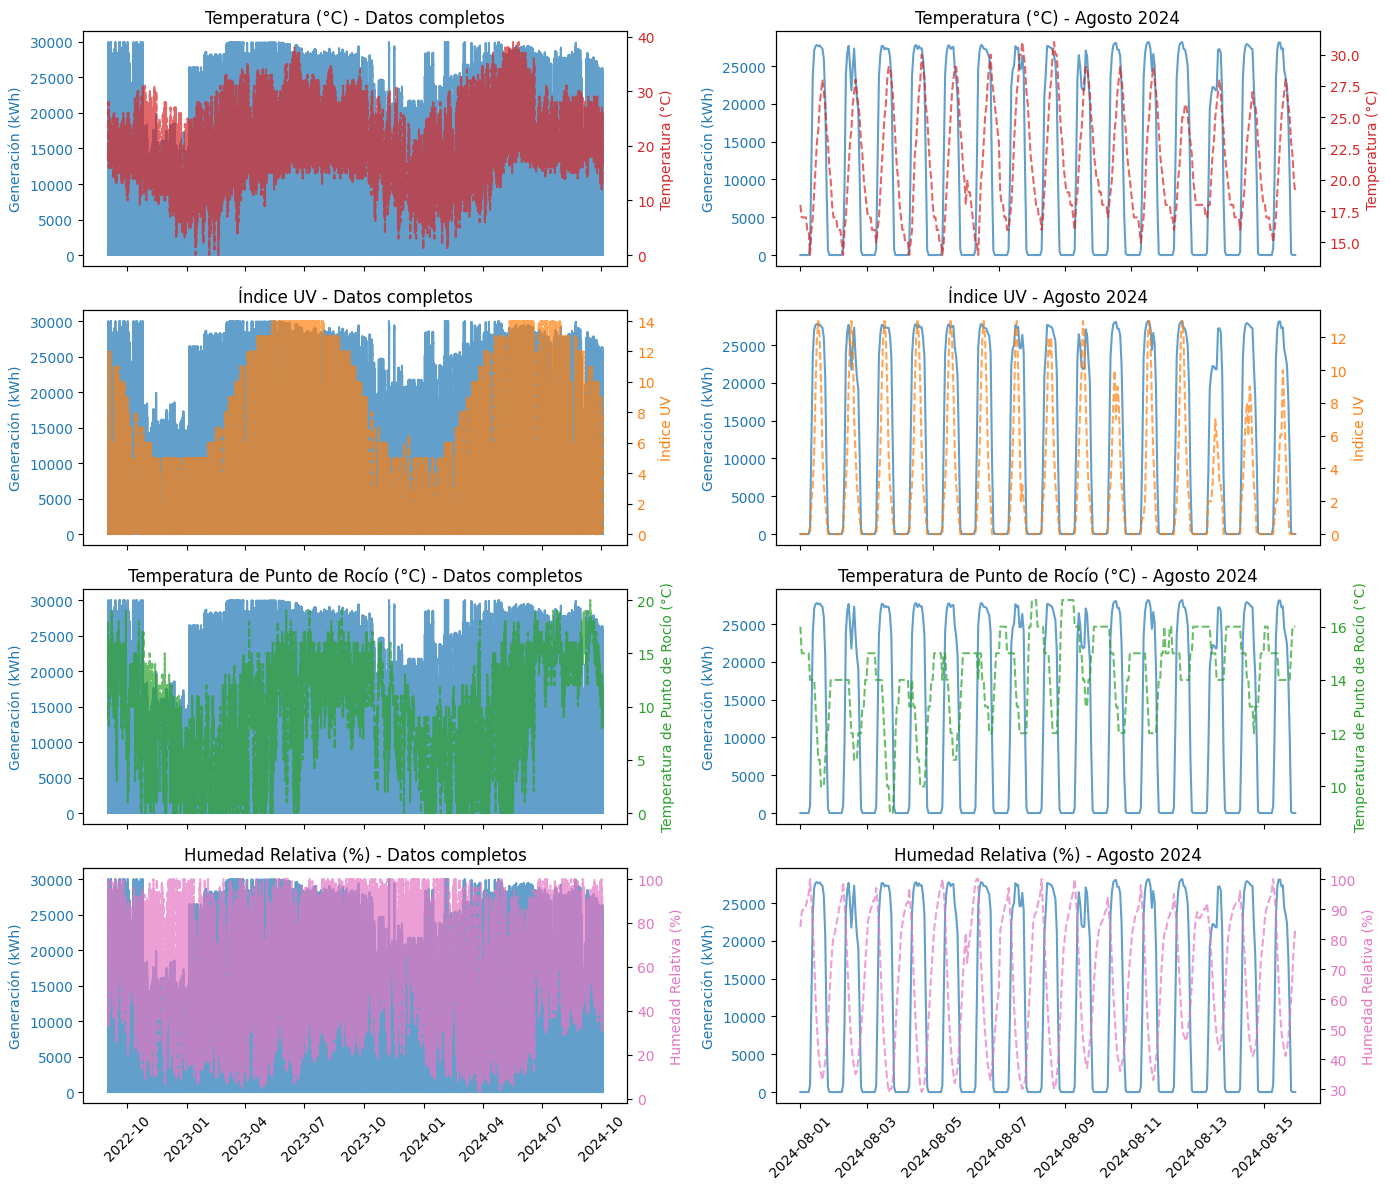

In [ ]:
df = pd.DataFrame(datos)
# Filtrar un mes específico (Ejemplo: marzo 2024)
df_mes = df[(df['dtHora'] >= '2024-08-01') & (df['dtHora'] < '2024-08-16')]

# Definir variables a graficar en el eje derecho
variables = ['fltTemp', 'fltIndiceUV', 'fltDPT', 'fltHumedadRelativa']
titulos = ['Temperatura (°C)', 'Índice UV', 'Temperatura de Punto de Rocío (°C)', 'Humedad Relativa (%)']
colores = ['tab:red', 'tab:orange', 'tab:green', 'tab:pink']

# Crear la figura con 4 filas y 2 columnas (cada fila tiene 2 gráficos)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 12), sharex=False)

# Recorrer las variables y asignarlas a los subgráficos
for i, var in enumerate(variables):
    # --- Columna izquierda: Datos completos ---
    ax1 = axes[i, 0]  # Eje principal
    ax1.set_title(f'{titulos[i]} - Datos completos')
    ax1.set_xlabel('Fecha', fontsize=12)
    ax1.set_ylabel('Generación (kWh)', color='tab:blue', fontsize=12)
    ax1.plot(df['dtHora'], df['fltValGeneracion'], color='tab:blue', alpha=0.7, linewidth=1.5, label='Generación (kWh)')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    # Crear segundo eje Y para la variable correspondiente
    ax2 = ax1.twinx()
    ax2.set_ylabel(titulos[i], color=colores[i], fontsize=12)
    ax2.plot(df['dtHora'], df[var], color=colores[i], linestyle='dashed', alpha=0.7, linewidth=1.5, label=titulos[i])
    ax2.tick_params(axis='y', labelcolor=colores[i])

    # --- Columna derecha: Solo datos de un mes ---
    ax3 = axes[i, 1]  # Eje principal
    ax3.set_title(f'{titulos[i]} - Agosto 2024')
    ax1.set_xlabel('Fecha', fontsize=12)
    ax3.set_ylabel('Generación (kWh)', color='tab:blue', fontsize=12)
    ax3.plot(df_mes['dtHora'], df_mes['fltValGeneracion'], color='tab:blue', alpha=0.7, linewidth=1.5, label='Generación (kWh)')
    ax3.tick_params(axis='y', labelcolor='tab:blue')

    # Crear segundo eje Y para la variable correspondiente
    ax4 = ax3.twinx()
    ax4.set_ylabel(titulos[i], color=colores[i], fontsize=12)
    ax4.plot(df_mes['dtHora'], df_mes[var], color=colores[i], linestyle='dashed', alpha=0.7, linewidth=1.5, label=titulos[i])
    ax4.tick_params(axis='y', labelcolor=colores[i])

    # Rotar etiquetas del eje X solo en la última fila
    if i == 3:
        ax1.tick_params(axis='x', rotation=45)
        ax3.tick_params(axis='x', rotation=45)
    else:
        ax1.set_xticklabels([])
        ax3.set_xticklabels([])

# Ajustar diseño para evitar superposiciones
plt.tight_layout()

# Mostrar gráfico
plt.show()

In [127]:
datos.to_excel("01.Generación sin nulos.xlsx", index=False, header=True)

In [128]:
datos = pd.read_excel('00.Generación sin nulos CT-NET.xlsx')
datos = datos.drop(columns="fltPrecipitacion")
datos.to_excel("01.Generación sin nulos CT-NET.xlsx", index=False, header=True)

In [129]:
datos = pd.read_excel('00.Generación sin nulos Photovoltaic.xlsx')
datos = datos.drop(columns="fltPrecipitacion")
datos.to_excel("01.Generación sin nulos Photovoltaic.xlsx", index=False, header=True)